# Why LLMs can't make your code simpler 

> Peter Naur's "Programming as Theory building" states that the real programs - what he calls Theory, with capital T - are in the mind of the engineers. The code & documentation itself are just downstream (and thus incomplete) artifacts. One of my main complaints about LLMs is how verbose the code is and how complexity creeps in everywhere. I always had some faith that we might improve that using metrics like LoC or the number of independent code paths to constraint them. However, after reading Naur I realized that the complexity we are trying to reduce is the Theory one, not the code, and there are no relevant measures for that because it's very subjective. 


I recently read the fantastic paper "Programming as Theory building" by Peter Naur. It has changed quite substantially my views on what current LLMs can or can't do, how to prompt them, what are the main limits to current agentic systems o why pair programming is so effective.

Today I will focus on its relation to code complexity.

If you haven't read the paper, I really suggest that you do. In fact, my main goal in writing this post is to get some of you to read the original paper. It is worth the effort. It is also the perfect change to practice (or learn!) to do close reading in [Solveit](solve.it.com) because it makes it much easier. You can ask any questions throughout the text, go down any rabbit holes you like, or just ask Solveit to make the language clearer to you. More information on close reading in [this blogpost](https://www.fast.ai/posts/2026-01-21-reading-LLMs/) and you can quickly get started by [forking my own dialog](https://share.solveit.pub/d/2ec584e79ecd9aed714c438d43f48f8e).

With that in mind, here's the paper's tl;dr:

> A program is the Theory held by the people who build and maintain it: an understanding of how the program relates to the real-world problem, which constraints and trade-offs shaped it, why it works, and which changes would fit its design. Code and documentation are downstream artifacts of that Theory, and can never capture it completely.
>
> Engineers develop this understanding through experience: talking to users, observing failures, learning the domain, and seeing how the system behaves in the real world. This understanding guides judgments of relevance, similarity, simplicity, and good design.

LLMs aren't great at continual learning, talking to users, or experiencing things in the real world. But why is this relevant to complexity?

I think we can all agree that LLMs in general tend to increase the complexity of codebases if left unchecked. The reasons are many: they fail to realize a method already existed and duplicate it, they write overdefensive code like protecting about edged cases that can't happen, or in overoptimizing things too early. Tangentially, most frontier labs make a hefty sum the more tokens you consume, so they are kind of incentivized to promote tokenmaxxing. All in all, LLMs very rarely follow the KISS principle. This issue is at its worst when vibe-coding w/o checking the output. But even when you review code, if you want to keep a program concise it requites an active effort to cut down complexity as much as possible.

In my naive days (about two weeks ago), I used to think we would get out of this complexity pit at some point. Frontier labs would just add some complexity penalization to their RL training. They could use total LoC as metric to minimize, but we can all agree that sometimes a one-liner can be more complex than 2-3 lines. Another option would be cyclomatic complexity which measures the total number of independent code paths. After reading Peter Naur I realized that those things can't really solve the problem (maybe they can alleviate it a bit though). Let's see why.

## Why Code Complexity is the wrong metric

In the (invented) example below we want to support calling OpenAI & Anthropic. Imagine all the message preparation and retries are handled identically, but the request body params are slightly different so we have 2 different methods `call_openai` and `call_anthropic`.

In the first naive version we have 2 different classes with duplicated boilerplate code (ie `prepare` and `with_retries`).

```python
# Separate — duplication a metric would flag

class OpenAIClient:
    def complete(self, prompt):
        msgs = prepare(prompt)         # shared boilerplate
        y = call_openai(msgs)          # the only line that differs
        return with_retries(y)         # shared boilerplate

class AnthropicClient:
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_anthropic(msgs)
        return with_retries(y)
```

A very straightforward refactor would be to create a single class so we DRY. By many metrics this is a better implementation: it has less lines of code, better Halstead volume[^1] and better Maintainability[^2].
 
[^1]: Halstead volume is calculated as \(V = N \times \log_2(n)\) using program length (N) and vocabulary (n)
[^2]: [Maintainability Index](https://radon.readthedocs.io/en/latest/intro.html#maintainability-index)
```python
# Merged — genuinely better by the metrics: DRY, fewer lines

class LLMClient:
    def __init__(self, provider): self.provider = provider
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_openai(msgs) if self.provider == "openai" else call_anthropic(msgs)
        return with_retries(y)
```

In general, the second version (or similar versions that reduce LoC and duplication) are less complex. However, what if I told you that is very likely that next month we will stop supporting Anthropic. In that situation I find preferable to keep them separated so when the time comes I can simply remove the file containing the `AnthropicClient`. 

Of course a simple example like this is easy to solve especially easy now that LLMs can code for you. But what if instead of 2 providers you want to support 165+ providers like LiteLLM does? Well in that case just use LiteLLM. But then you will be putting over +1.2M python LoC between you and the final provider. Is it worth it? 

Good designed APIs are a great way to abstract complexity. You have a clear contract and you don't need to understand what happens behind. Even if the LiteLLM is a huge package, it might need not count towards your total Theory complexity. The early days of LLM inference endpoints were like this "you send text in, you get text out". However, this breaks down when the contract is not reliable anymore. This can happen because it's buggy, or because there's a lot state hidden behind the API which you can't get, or simply because you're not sure if a new provider feature is supported.

Whenever you are forced to peer into the abyss beyond the API abstraction layer, that complexity becomes your problem. This problem is becoming more common. Providers like OpenAI and Anthropic increasingly hide data server-side like encrypted compaction data or reasoning tokens ([more on this](https://earendil.com/posts/session-portability/)). Anyone aiming to offer an abstraction layer on top of them is forced to either expose provider-specific details, reimplement increasingly brittle compatibility logic, or accept that the abstraction cannot faithfully represent the systems beneath it.

| Pros | Cons |
|------|------|
| Supports hundreds of providers and models | Performance footprint (until they get to Rust at least) |
| Single (ideally) unified interface | +1.2M LoC between you and the provider |
| Battle-tested retry/fallback logic for free | Possibly delayed updates (wrt original provider) |
| Provider switching without code changes (ideally) | Harder to debug — stack traces go through abstraction layers |
| | Lowest-common-denominator API: provider-specific features lag or get lost |
| | Your Theory of "calling a provider" now lives in someone else's codebase |

If you are moving fast, using basic features and want to try many providers then LiteLLM or similar libs might be worth it for you. If on the other hand you value control, debugging and in understanding your stack, then probably not. There's no right "complexity" (although I very much prefer the second option).



## Enter the Theory

The information to decide which path to take does not live in the code. This information is part of what Naur calls the Theory of the program. LLMs so far have little to no access to this information because it lives in people's mind. They can get hints about it in IM, email, or other kind of written docs but all of those will always be partial (best case).

Some of this information can be supplied to an LLM as context like business priorities, expected product changes, operational constraints, and the reasons behind earlier decisions. Doing so tends improve its choices. But these are still artifacts of the Theory. They cannot completely transfer the experience and judgment through which the team developed that Theory.

This is all good, but what if I am all-in with vibe-coding & tokenmaxxing, what if I don't care at all about the code. Well in that situation the rest of the blog post won't convince you otherwise. If on the other hand you're in-between I will describe a real situation we went through at Answer.AI with our billing system for SolveIT.

Spoiler alert, at Answer.AI we are heavily invested in minimizing code complexity at all costs. This investment actually tends to result in simpler Theory so we can hold it all in our mind (or try to).

## The initial billing system

SolveIT is a platform where you can use AI to work in a notebook-like environment. The environment is persistent so we charge for LLM usage, cpu, disk, memory and bandwidth.

The initial plan was to charge users a monthly subscription fee (e.g. $5). This monthly subscription amount would then become credits to be consumed during the month, if you consume them all then you'd have to top up your balance before next month. We tested this approach in a smaller scale in the Plash service.

This approach turned out to be more complex that we wanted. First, the credit + susbcription mechanism would make some people (like myself) confused. Second, it made the code more complex at multiple levels. You have to deal with all the logic of consuming "monthly subscription credits" first, and then normal credits or what to do with leftover credits. On the stripe side of things it had 2 distinct code paths: manual top up and the subscription service.

For those of you not familiar with it, Stripe subscriptions is a fully managed service. Stripe manages the lifecycle (recurrence, invoicing, retries all happen on their side).

You just create the subscription roughly like:

```python
stripe.Subscription.create(customer=cust_id, items=[{"price": "price_5usd_monthly"}])
```

and listen to their webhooks to update your DB when subscription status changes or when payments arrive (or many other options you can decide on).

The direct charge requires you to start a checkout session so users land in Stripe's domain and fill in their card. It requires you to provide a customer ID. Where should you create the stripe customer? when your user signs up? when they try to pay, something else? all are valid options.

```python
 stripe.checkout.Session.create(mode="payment", customer=cust_id,
    line_items=[{"price": "price_5usd", "quantity": 1}],
    success_url="https://yoursite.com/done")
```

Good so far? If you don't have a lot of experience with Stripe or payments, chances are you will be already struggling to hold it all in your head. Maybe you have managed to simplify it into your mind like:

- Subscriptions -> mananged by stripe subscriptions
- Top up        -> stripe checkout

Some problems that are not obviouos is that using Stripe managed service means that you have duplicated data. Half of the data lives in Stripe's backend and you have to make sure your local DB is synchronized with it. Another problem is that while debugging, you have to both query stripe services AND check your own DB. For example, if a payment does not show up is it because Stripe did not send the webhook ("their fault"), or because we failed to store it in our DB ("our fault")?

Stripe subscription service is great and easy to set up, but it is designed to support a huge number of use cases. That means that, even if well designed (which it certainly is), the API abstraction ends up being quite complex. In this case you are trading the complexity of rolling your sleeves and writing that code yourself, for the complexity of learning the Stripe API.

LiteLLM and Stripe illustrate the same trade-off at different scales: an external abstraction can greatly simplify your Theory while its contract holds, but its hidden complexity becomes yours whenever you must debug, modify, or reason beyond that contract.



## The AAI way

At Answer.AI we try to own all the stack. The reason why merits a full article (or multiple ones) so I won't delve into it. So we were not pleased with the state of affairs discussed above.

After many days of exploration and discussion we settled on a much simpler system.

First of all, we would do credits only and charge based on usage. This is a very simple model (and Theory!) you pay for what you use by adding credits.

Once subscriptions were out of the way, we could remove a big chunk of code related to keeping them in sync. Only 2 payment paths remained, toping up your account manually and auto topup. To do auto topup you need to be able to save the customer CC so you can charge it at will. In the case of Stripe checkouts, you don't save the CC, you just ask Stripe to process the payment in their UI.

Long story short, we eventually figured out that the simplest way would be to save users' credit card as soon as they sign up. Once they have a card on file, they can either use it to manually top up their account, or they can set it to auto topup. Because we handle it all manually the sync problems are almost nil. We only listen to payment success events (no subscriptions!).

The result is that the Theory of our payment system can be summarized in a single sentence:
> Customers add their CC when they sign up and then we charge that card either manually (topup) or automatically when the credit goes low

Both manual and automatic top up use the same payment logic. And all our payment logic lives in our codebase. The full payment logic is INSERT AMOUNT lines of code.

The result is veyr low complexity but it was the result of multiple hours of exploration, attempts, and discussions. My explanations here scratch the surface at best.

## Enter India

So what happend on launch day? did everything goes smoothly? No. After launching we realized that Indian cards do not support direct debit mandates so we could not charge them at will. The manual top up would still work because they would be shown a 3Ds-like approval flow in our UI but no auto top up.

When exploring for solutions, we discovered that Stripe managed subscriptions actually work in India. Why? Well Stripe works around all that complexity for you by creating a payment intent the day before, so they banks can pre-approve it or ask the user to confirm it (among other things). 

When migrating away from managed subscriptions we lost that feature. I asked [INSERT FAVORITE LLM HERE] how could we handle this. Do you care to guess at the proposed solution?

> Use Stripe subscriptions

Should we migrate back? If you have read this far, what would you say, what's your opinion?  

The LLM proposed either to support both systems (already ready to code it all for you at word!) or migrate back into the old one. What did we do? Nothing. We greatly value the Theory complexity so we decided that requiring India users to manually top up was ok (sorry guys!) in exchange for a simpler and more robust platform.

If you don't agree with our choice, reflect on why not. What are your arguments and, more specifically, **where** do they come from? 

There are many situations where Stripe managed services are a superior choice. Here are some examples:

- Our revenue is the most important, so the extra friction of manual top up might make us lose some India sales, we should migrate back (or support both)
- The sales team uses the Stripe Dashboard UI, having all the payment system information in our DB is not ideal because they can't manage it.
- 3rd Reason?

My point is that the complexity of your code really depends on a lot of factors that have NOTHING to do with code and that information is NOT in the code.

## The hidden advantage

So why not let LLMs fully manage these things for you? The beautiful answer in my opinion is that our way of working uncovered a real business opportunity. India does not support debit mandates in the same way rest of countries do. Stripe tries to solve this, but it is far from a complete solution. 

These, in my opinion, are the kind of insights that become business opportunities. In the process of understanding the full process and simplifying the Theory we learned something. I can see many situations where this information gives you an advantage. Maybe it is worth starting a company to offer these kind of direct debit mandate in India easily. I am not sure about this case specifically, but working closely with the code and striving to understand is essentially a process of Theory-simplification.  In the unreigned world of complexity you can stack a huge amount of stones quickly. The simplification process is much longer, but in that friction rough stones can become diamonds.

## Python Meetup Talk

In [ ]:
%%prompt
I'm gonna use this blog post to give a talk at the Python Meetup. Normally I like to do more hands on but I think that now our paper is quite relevant to current AI, and I think it’s going to be interesting. I will start by explaining a bit of the main ideas of the paper. Then I will take the chance also to show how to Code Written Solid very briefly, and give them a link to the dialogue they can fork so they can read it themselves. And once we have the theory, no pun intended, out of the way, we’ll do the Stripe use case. First, we will maybe see some examples about the interfaces that I also mentioned in the blog post, and then we will move into the Stripe example.

To make it a bit more interesting for the Python meetup, the Stripe example I will try to have a minimal working app that you can use with Stripe. So when they finish, they can just copy the code and get a working app.

The first thing is to choose a title and an abstract that should be around two paragraphs, tops, and a length. Normally I do 20-minute talks or a bit more and include questions. I’m not sure if this one, even if there’s not a lot of content, will be a bit longer because there is all the paper introduction, the close reading, and then the use case and the running code. What do you think? 


I will use the same title 'Why LLMs Can't Make Your Code Simpler' but can you help me brainstorm ideas for the abstract, don't write them yourself give me different options on how to frame it. I'm wary of pushing too much the "paper" angle (specially "old paper") because it's a hands-on community that has not much research and it will sound boring. On the other hand, I could push the paper angle and say that "old meets modern" and why that explains the complexity creep for LLMs. 

On length first: I'd plan for **25–30 minutes**. Paper intro + close reading demo (~8 min), interfaces/complexity examples (~5 min), Stripe walkthrough with working app (~10 min), plus questions. Trying to squeeze the live app demo into 20 min is where talks usually die. If the venue is strict about 20, the close reading demo is the thing to trim (just show the link).

For abstract framing, here are the angles I see:

1. **The debugging-your-AI frame:** Start from the shared pain — "why does my LLM code get more complex every week?" — and position the talk as the explanation. The paper appears mid-talk as the surprising answer, not the premise. Least risky for a hands-on crowd.

2. **The "old meets modern" frame** (your idea): A 1985 paper predicts exactly why 2026 coding agents overcomplicate. The hook is the anachronism itself — it works if you lean into the mystery ("the best explanation of LLM failure modes was written 40 years before LLMs") rather than "let me tell you about a classic paper."

3. **The metrics-can't-save-you frame:** Open with the engineering instinct — surely we can constrain complexity with LoC, cyclomatic complexity, lint rules? Build the talk as "why every metric fails," with Theory as the punchline. Appeals to the tooling-minded Python crowd.

4. **The practical-payoff frame:** Lead with the Stripe app — "we replaced our billing system with 300 lines of Python, and an LLM would never have suggested it." The theory sneaks in as the explanation of *how* you got there. Most hands-on framing; the paper is almost a footnote.

5. **The "where do your opinions come from" frame:** Frame it around judgment — when you disagree with an LLM's design proposal, what are you actually drawing on? Interactive, works well live with a show of hands, but the abstract is vaguer.

My take: 3 or 4 fit your audience best, and they combine naturally (metrics fail → here's what real simplicity bought us). Option 2 can still be the *title slide reveal* moment inside the talk without being the abstract's selling point.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 78381, "completion_tokens": 779, "total_tokens": 79160, "cache_creation_tokens": 77755, "cost": 1.5257212500000001}
```


# Python Meetup Talk Proposal

**Title** Why LLMs can't make your code simpler

**Abstract**

LLMs tend to increase the complexity of a codebase very fast, especially if left unchecked. If you're fine with that creeping complexity, this talk may not be for you. But if you have tried to tame it, you'll have noticed how hard it is. Why is that? Why can't LLMs write simple code? Couldn't frontier labs just train models to minimize total LoC, or cyclomatic complexity?

In Programming as Theory Building (1985), Peter Naur argues that the real program is not the code but the understanding in your head. That is one of the key problems for LLMs: the information needed to simplify code was never in the code to begin with. As a working example, I'll show how this mindset let us at Answer.AI cut our Stripe billing system down to ~300 lines of Python — and why this solution might also be good for you (or not!).

Find the talk resources at https://github.com/kafkasl/code-complexity-talk

**Time** 25-35min

## Slides in Solveit discussion

In [ ]:
%%prompt
can you check if ws/mdhtml2docx supports generating slides too?

I'll look at the repo's README and structure:

```json {.tool}
{
  "id": "toolu_018dxrL6t4mzX8oRUe6EtbFq",
  "name": "python",
  "args": {
    "code": "from rgapi.skill import ls\nls(Path.home()/'ws'/'mdhtml2docx')"
  },
  "result": "Tool not defined in tool_schemas: python"
}
```

```json {.tool}
{
  "id": "toolu_01DNH8PmrrMQMMAfYk572odn",
  "name": "py",
  "args": {
    "code": "from rgapi.skill import ls\nls(Path.home()/'ws'/'mdhtml2docx')"
  },
  "result": "-rw-r--r--    1.3K 2026-08-07 20:01 CHANGELOG.md\n-rw-r--r--    1.4K 2026-08-04 16:46 DEV.md\n-rw-r--r--   11.1K 2026-08-04 16:46 LICENSE\n-rw-r--r--      55 2026-08-04 16:46 MANIFEST.in\n-rw-r--r--    8.8K 2026-08-04 16:46 README.md\n-rw-r--r--      28 2026-08-04 16:46 _config.yml\ndrwxr-xr-x      96 2026-08-04 16:46 _layouts\ndrwxr-xr-x     448 2026-08-07 20:01 mdhtml2docx\ndrwxr-xr-x     224 2026-08-15 08:07 mdhtml2docx.egg-info\n-rw-r--r--    1.2K 2026-08-07 20:01 pyproject.toml\ndrwxr-xr-x     192 2026-08-07 20:01 tests\ndrwxr-xr-x      96 2026-08-04 16:46 tools"
}
```

Repo exists with a README and a `mdhtml2docx` package dir. Let me check the README and search for slide-related functionality:

```json {.tool}
{
  "id": "toolu_01FrhXuMNFZfjw7RXaTGrvxu",
  "name": "py",
  "args": {
    "code": "from rgapi.skill import rg\nrg(r'''slide|pptx|presentation|deck''', Path.home()/'ws'/'mdhtml2docx', smart_case=True)"
  },
  "result": "mdhtml2docx/schemas/SOURCES.md:3:The `*.xsd` files except `xml.xsd` are the wordprocessing import closure (12 of 26 files) of the ECMA-376 Part 4 5th edition transitional schema set, from `OfficeOpenXML-XMLSchema-…\nmdhtml2docx/schemas/dml-diagram.xsd:207:  <xsd:complexType name=\"CT_PresentationOf\">\nmdhtml2docx/schemas/dml-diagram.xsd:259:      <xsd:element name=\"presOf\" type=\"CT_PresentationOf\" minOccurs=\"0\" maxOccurs=\"1\"/>\nmdhtml2docx/schemas/dml-diagram.xsd:277:      <xsd:element name=\"presOf\" type=\"CT_PresentationOf\" minOccurs=\"0\" maxOccurs=\"1\"/>\nmdhtml2docx/schemas/dml-diagram.xsd:293:      <xsd:element name=\"presOf\" type=\"CT_PresentationOf\" minOccurs=\"0\" maxOccurs=\"1\"/>\nmdhtml2docx/schemas/dml-diagram.xsd:312:      <xsd:element name=\"presOf\" type=\"CT_PresentationOf\" minOccurs=\"0\" maxOccurs=\"1\"/>\nmdhtml2docx/word.sdef:1592:\t\t\t<enumerator name=\"Slide\" code=\"0x007b0003\"/>\nmdhtml2docx/word.sdef:3840:\t\t<class name=\"endnote options\" code=\"WopE\" description=\"A representation of the options associated with endnotes.\">\nmdhtml2docx/word.sdef:3967:\t\t<class name=\"footnote options\" code=\"WopN\" description=\"A representation of the options associated with footnotes.\">\nmdhtml2docx/word.sdef:5426:\t\t\t<enumerator name=\"property slides\" code=\"0x022c0019\"/>\nmdhtml2docx/word.sdef:5428:\t\t\t<enumerator name=\"property hidden slides\" code=\"0x022c001b\"/>"
}
```

No — `mdhtml2docx` does not support generating slides. The only "slide"/"presentation" hits are incidental: OOXML schema internals (`dml-diagram.xsd`), Word AppleScript definitions (`word.sdef`), and nothing in the README, package code, or CLI relates to PPTX or slide output. It's strictly markdown/HTML → DOCX (Word documents).

If you want slides for the meetup talk from markdown, typical options are `python-pptx`, Quarto/reveal.js, or Marp — but none of that lives in this repo.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 320174, "completion_tokens": 557, "total_tokens": 320731, "cached_tokens": 238240, "cache_creation_tokens": 79721, "cost": 1.9270987499999999}
```


In [ ]:
%%prompt
it can generate docx, can you explore what it would take to add slide generation to the repo?

Let me start with the README and package layout to understand the architecture:

`````json {.tool}
{
  "id": "toolu_01FaeJvqGqSEijfk7ugymNJ8",
  "name": "py",
  "args": {
    "code": "from fastcore.tools import view_file\nview_file(Path.home()/'ws'/'mdhtml2docx'/'README.md')"
  },
  "result": "1: # mdhtml2docx\n2: \n3: Convert [MDHTML](https://github.com/AnswerDotAI/mdhtml) to Word docx files.\n4: \n5: `mdhtml` renders Markdown to an HTML5 document format shared by format-specific exporters. This package converts its portable core to docx from scratch. It uses [fast5ever](https://github.com/AnswerDotAI/fast5ever)'s mutable WHATWG DOM for input and lxml for the generated WordprocessingML.\n6: \n7: MDHTML accepts the full HTML vocabulary. This exporter supports the portable elements and annotations listed below. It preserves the text of unknown inline elements, recurses through block containers, and warns when an unsupported block must become a plain paragraph. HTML parsing and repair belong to `mdhtml`; this package only walks the resulting tree.\n8: \n9: ## Usage\n10: \n11: ```python\n12: from mdhtml import to_mdhtml\n13: from mdhtml2docx import convert\n14: \n15: html = to_mdhtml(markdown_text)\n16: warnings = convert(html, 'out.docx')\n17: ```\n18: \n19: `convert` takes an MDHTML string, writes a docx, and returns a list of warning strings. It parses strings with `mdhtml.parse_mdhtml`, so normal HTML5 repair applies and XML well-formedness is irrelevant. It also accepts an existing mutable fast5ever DOM:\n20: \n21: ```python\n22: from mdhtml import parse_mdhtml\n23: \n24: document = parse_mdhtml(html)\n25: document.children[0].attrs['custom-style'] = 'Contract Title'\n26: warnings = convert(document, 'out.docx')\n27: ```\n28: \n29: Body-position text and phrasing content become implicit Word paragraphs. Whitespace between blocks remains inert. HTML templates remain inert and are not rendered.\n30: \n31: Supported: headings, paragraphs, bold, italic, strikethrough, underline (the `u` element), highlight, superscript and subscript, inline code, links (external and internal, via bookmarks), images (local files are embedded with correct dimensions; remote URLs degrade to links), block quotes, fenced and indented code blocks, bullet and numbered lists (including nesting, `start`, and task-list checkboxes), pipe and grid tables (including row and column spans and header rows), definition lists, footnotes, horizontal rules, and abbreviations. A `details` div (the dialect's collapsible block) degrades to its label as a bold line above the body, never a numbered heading — Word has no folding. Math spans and blocks become native Word math zones (`m:oMath`) holding the source text as-is, whatever the dialect (TeX, UnicodeMath, AsciiMath). Build-up/rendering is left downstream, and pandoc reads the zones back as math.\n32: \n33: Code blocks with a language are syntax colored when [fastpylight](https://github.com/AnswerDotAI/fastpylight) is installed: tokens get `Hl*` character styles (e.g. `Hl Keyword`), whose colors come from the theme entry in the reference list below, so a finished document can be restyled in Word like everything else.\n34: \n35: ## Styling\n36: \n37: The generated document uses named styles, never inline formatting, so appearance is controlled by restyling. Prose paragraphs get Body Text (First Paragraph directly after a heading or similar block, following pandoc's convention), and the other styles are the ones you would expect: heading 1 through 6, Quote, Source Code, Verbatim Char, Hyperlink, List Paragraph, Compact (table cells), Definition Term, Definition, caption, footnote styles, and Table Grid (plus the author-selectable Borderless Table).\n38: \n39: Pass `reference='mydoc.docx'` to use your own document's styles instead of the built-in template, exactly like pandoc's `--reference-doc`. `reference` may also be a list: the first entry supplies the document (page setup, fonts, and all base styles), and each later entry contributes just its styles, replacing same-named earlier ones - either another `.docx`, or a fastpylight theme name such as `'dracula'`, which generates the code-color styles on the fly. The default is the built-in template plus `'github_light'`; pass a bare reference for plain uncolored code, or `mdhtml2docx.styles.theme_ref('dracula', 'dracula.docx')` to write a theme's styles as a standalone docx you can inspect or tweak. A `custom-style=\"Name\"` attribute (from `{custom-style=\"Name\"}` in Markdown) applies that style from your reference doc; if the style is missing, a stub is injected and a warning returned. A plain class like `{.note}` applies a style only when your reference doc defines one named `note`, and is otherwise ignored. Both work on tables too: a table whose `custom-style` or class names a table style in the reference doc uses it in place of Table Grid - the built-in template ships `Borderless Table` (no gridlines, for signature blocks and other layout tables).\n40: \n41: Tables can mix fixed and proportional column widths with a `colwidths` attribute, written in Markdown as an attribute list after the table: `{: colwidths=\"10em 2fr 1fr\"}`. Lengths fix a column; `fr` values share the remaining width, as in CSS grid.\n42: \n43: The built-in template is generated by `tools/createref.py` from a stock Word document; it defines exactly the styles the converter emits, plus next-paragraph chains so documents stay well-styled while edited by hand in Word.\n44: \n45: ## Raw docx\n46: \n47: This converter consumes MDHTML raw data whose `data-format` is `docx`:\n48: \n49: ```html\n50: <script type=\"application/vnd.mdhtml.raw\" data-format=\"docx\">…</script>\n51: ```\n52: \n53: A ```` ```{=docx} ```` fenced block in Markdown, or inline code followed by `{=docx}`, produces that carrier. The payload is parsed as WordprocessingML and inserted verbatim. Block payloads supply content such as `w:p` or `w:tbl`; inline payloads supply content such as `w:r`. The prefixes `w`, `r`, `wp`, `a`, `pic`, and `m` are predeclared, so no namespace boilerplate is needed.\n54: \n55: Literal payloads have no `data-encoding`. The exporter performs one character-reference decoding pass for `data-encoding=\"html\"`, and accepts UTF-8 payloads encoded with `data-encoding=\"base64\"`. Malformed payloads and unknown encodings are dropped with a warning. Raw data for other formats is skipped silently.\n56: \n57: The canonical example is a page break:\n58: \n59:     ```{=docx}\n60:     <w:p><w:r><w:br w:type=\"page\"/></w:r></w:p>\n61:     ```\n62: \n63: ## Cross-references\n64: \n65: Markdown references like `[@sec-payment]` become MDHTML `a` elements marked with `data-ref`, which this exporter turns into live Word REF fields rather than baked text. The default field is `REF <bookmark> \\w \\h`, the full-context paragraph number (\"3.(c)(iii)\") as a hyperlink; `settings.xml` gets `updateFields`, so Word refreshes on open. The `leaf`, `rel`, `text`, and `page` tokens select other fields, while the independent `bare` token suppresses the prefix word. Unknown or conflicting tokens are conversion errors.\n66: \n67: The word before the number comes from the reference's type, the id up to its first `-`: `sec` maps to Section/Sections out of the box, and `reftypes=dict(exh=('Exhibit', 'Exhibits'))` adds more. `[Clause @sec-x]` overrides the word for one reference; `[-@sec-x]` suppresses it. Grouped references use a `span` marked with `data-refs` and join as \"Sections 3.1 and 4.2\" with one field per number. They are never collapsed into ranges, because \"3.1-3.3\" is static text whose meaning silently changes when a clause is inserted. A reference whose target id does not exist, or whose type has no prefix defined when one is needed, raises rather than warning: a lawyer's document must not open showing \"Error! Reference source not found.\"\n68: \n69: Number fields need numbered headings. If your reference docx already numbers its heading styles (most firm templates do), nothing more is required, and the converter leaves that numbering alone. Otherwise pass `number_headings='legal'` for 1. / (a) / (i) numbering or `'decimal'` for 1 / 1.1 / 1.1.1 (the names index `styles.SCHEMES`), or pass your own scheme as a `{lvlText: numFmt}` dict, one entry per heading level. A reference-list entry ending in `.xml` is a third route: a raw file of `w:style`, `w:abstractNum`, and `w:num` elements contributing styles and numbering together, with ids remapped to avoid collisions.\n70: \n71: Figures and captioned tables number themselves with SEQ fields: a figure renders as its image plus a \"Figure 1: caption\" paragraph below (caption style), a table caption as \"Table 1: caption\" above the table, both live. When the element has an id, the label-and-number span is bookmarked, so `[@fig-plot]` inserts a live \"Figure 1\" (no extra prefix word; the label is part of the bookmarked text) and `[-@tbl-stages]` the bare number via a second number-only bookmark. `fig` and `tbl` are built-in reftypes alongside `sec`, and their label words come from the same table. Mixed-type groups render each item with its own singular prefix (\"Figure 1 and Table 2\"); same-type groups pluralize once. Reference targets must be things that get bookmarks - headings, paragraphs, figures, and tables with ids - and a ref to anything else is an error at convert time.\n72: \n73: ## Validation\n74: \n75: Every generated file is checked three ways in the test suite: lxml validation against the ECMA-376 schemas (container, CRC, XML, XSD), a semantic round trip through pandoc's independent docx reader, and occasional acceptance runs in Microsoft Word itself, driven live via AppleScript."
}
`````

```json {.tool}
{
  "id": "toolu_014u5oJxBc7tvuzsQBmYjcus",
  "name": "py",
  "args": {
    "code": "ls(Path.home()/'ws'/'mdhtml2docx'/'mdhtml2docx', ext='py')"
  },
  "result": "-rw-r--r--      54 2026-08-07 20:01 __init__.py\n-rw-r--r--    3.7K 2026-08-04 16:46 asvocab.py\n-rw-r--r--   52.9K 2026-08-07 20:01 convert.py\n-rw-r--r--    1.1K 2026-08-04 16:46 hilite.py\n-rw-r--r--    5.4K 2026-08-04 16:46 styles.py\n-rw-r--r--    1.7K 2026-08-04 16:46 validate.py\n-rw-r--r--    5.2K 2026-08-04 16:46 wml.py\n-rw-r--r--    6.3K 2026-08-04 16:46 word.py"
}
```

```json {.tool}
{
  "id": "toolu_01C14MuzdM41PmHDWfwSx7LM",
  "name": "py",
  "args": {
    "code": "from fastcore.tools import view_file\nview_file(Path.home()/'ws'/'mdhtml2docx'/'mdhtml2docx'/'wml.py')"
  },
  "result": "1: \"\"\"WordprocessingML construction helpers: namespaces, a qualified-name element builder, unit\n2: conversions, and the colwidths track-list parser. Child-element order inside w:pPr/w:rPr/w:tcPr\n3: etc follows the ECMA-376 content models; builders here emit children in the order callers pass\n4: them, so callers are responsible for schema order (the convert module's helpers encode it).\"\"\"\n5: import re, struct\n6: from xml.sax.saxutils import escape\n7: from lxml import etree\n8: \n9: __all__ = ['W', 'R', 'WP', 'A', 'PIC', 'NS', 'qn', 'E', 'twips', 'parse_tracks', 'EMU_PER_PX', 'imgsize', 'drawing']\n10: \n11: W = 'http://schemas.openxmlformats.org/wordprocessingml/2006/main'\n12: R = 'http://schemas.openxmlformats.org/officeDocument/2006/relationships'\n13: WP = 'http://schemas.openxmlformats.org/drawingml/2006/wordprocessingDrawing'\n14: A = 'http://schemas.openxmlformats.org/drawingml/2006/main'\n15: PIC = 'http://schemas.openxmlformats.org/drawingml/2006/picture'\n16: M = 'http://schemas.openxmlformats.org/officeDocument/2006/math'\n17: XML = 'http://www.w3.org/XML/1998/namespace'\n18: NS = dict(w=W, r=R, wp=WP, a=A, pic=PIC, m=M, xml=XML)\n19: \n20: def qn(name):\n21:     \"Clark-notation name for a `prefix:local` string, e.g. 'w:p' -> '{...main}p'\"\n22:     pre, local = name.split(':')\n23:     return f'{{{NS[pre]}}}{local}'\n24: \n25: def E(tag, *children, **attrs):\n26:     \"\"\"Build element `tag` ('w:p' form). `children` may be elements (appended), dicts (attrs with\n27:     'w:val'-form keys), or strings (text). Underscores in kwarg names are hyphens ('w_val' unusable\n28:     for ':' so kwargs are unqualified attrs; use dicts for qualified ones).\"\"\"\n29:     e = etree.Element(qn(tag) if ':' in tag else tag)\n30:     for k, v in attrs.items(): e.set(k, str(v))\n31:     for c in children:\n32:         if c is None: continue\n33:         if isinstance(c, dict):\n34:             for k, v in c.items(): e.set(qn(k) if ':' in k else k, str(v))\n35:         elif isinstance(c, str): e.text = (e.text or '') + c\n36:         else: e.append(c)\n37:     return e\n38: \n39: # CSS length units in twips (1/20 pt). em/rem/ch use the template body size (11pt Aptos/Calibri).\n40: UNITS = dict(pt=20, px=15, pc=240, em=220, rem=220, ch=110)\n41: UNITS['in'] = 1440\n42: UNITS['cm'] = 566.9\n43: UNITS['mm'] = 56.69\n44: \n45: def twips(s):\n46:     \"CSS length string -> twips (int), e.g. '10em' -> 2200; raises ValueError on unknown units\"\n47:     m = re.fullmatch(r'([\\d.]+)\\s*([a-z]+)', s.strip())\n48:     if not m or m[2] not in UNITS: raise ValueError(f'unsupported length: {s!r}')\n49:     return round(float(m[1]) * UNITS[m[2]])\n50: \n51: def parse_tracks(s):\n52:     \"\"\"Parse a colwidths track list into (kind, value) pairs: ('dxa', twips) for lengths,\n53:     ('fr', share) for fr units. E.g. '10em 3fr 7fr' -> [('dxa',2200),('fr',3.0),('fr',7.0)]\"\"\"\n54:     def _track(tok):\n55:         m = re.fullmatch(r'([\\d.]+)fr', tok)\n56:         return ('fr', float(m[1])) if m else ('dxa', twips(tok))\n57:     return [_track(t) for t in s.split()]\n58: \n59: EMU_PER_PX = 914400 // 96  # pixel at 96dpi in EMUs\n60: \n61: \n62: def imgsize(data):\n63:     \"\"\"Sniff (px_w, px_h, dpi_x, dpi_y) from png/jpeg/gif bytes, or None if unrecognized.\n64:     (Header layouts cribbed from python-docx's image parsers, MIT.)\"\"\"\n65:     if data[:8] == b'\\x89PNG\\r\\n\\x1a\\n':\n66:         pw, ph = struct.unpack('>II', data[16:24])\n67:         dx = dy = 96\n68:         i = 8\n69:         while i + 8 <= len(data):\n70:             ln, typ = struct.unpack('>I4s', data[i:i+8])\n71:             if typ == b'pHYs':\n72:                 px, py, unit = struct.unpack('>IIB', data[i+8:i+17])\n73:                 if unit == 1: dx, dy = round(px * 0.0254), round(py * 0.0254)\n74:                 break\n75:             i += ln + 12\n76:         return pw, ph, dx, dy\n77:     if data[:2] == b'\\xff\\xd8':\n78:         dx = dy = 96\n79:         i = 2\n80:         while i + 4 <= len(data) and data[i] == 0xFF:\n81:             m, ln = data[i+1], struct.unpack('>H', data[i+2:i+4])[0]\n82:             if m == 0xE0 and data[i+4:i+9] == b'JFIF\\x00':\n83:                 unit, xd, yd = data[i+11], *struct.unpack('>HH', data[i+12:i+16])\n84:                 if unit == 1: dx, dy = xd, yd\n85:                 elif unit == 2: dx, dy = round(xd * 2.54), round(yd * 2.54)\n86:             elif m in (0xC0, 0xC1, 0xC2, 0xC3):\n87:                 ph, pw = struct.unpack('>HH', data[i+5:i+9])\n88:                 return pw, ph, dx, dy\n89:             i += 2 + ln\n90:     if data[:6] in (b'GIF87a', b'GIF89a'):\n91:         pw, ph = struct.unpack('<HH', data[6:10])\n92:         return pw, ph, 96, 96\n93:     return None\n94: \n95: DRAWING = r'''<w:drawing xmlns:w=\"{W}\" xmlns:wp=\"{WP}\" xmlns:a=\"{A}\" xmlns:pic=\"{P}\" xmlns:r=\"{R}\">\n96: <wp:inline distT=\"0\" distB=\"0\" distL=\"0\" distR=\"0\">\n97: <wp:extent cx=\"{cx}\" cy=\"{cy}\"/><wp:effectExtent l=\"0\" t=\"0\" r=\"0\" b=\"0\"/>\n98: <wp:docPr id=\"{n}\" name=\"Picture {n}\" descr=\"{descr}\"/>\n99: <wp:cNvGraphicFramePr><a:graphicFrameLocks noChangeAspect=\"1\"/></wp:cNvGraphicFramePr>\n100: <a:graphic><a:graphicData uri=\"{P}\">\n101: <pic:pic><pic:nvPicPr><pic:cNvPr id=\"{n}\" name=\"Picture {n}\"/><pic:cNvPicPr/></pic:nvPicPr>\n102: <pic:blipFill><a:blip r:embed=\"{rid}\"/><a:stretch><a:fillRect/></a:stretch></pic:blipFill>\n103: <pic:spPr><a:xfrm><a:off x=\"0\" y=\"0\"/><a:ext cx=\"{cx}\" cy=\"{cy}\"/></a:xfrm>\n104: <a:prstGeom prst=\"rect\"><a:avLst/></a:prstGeom></pic:spPr>\n105: </pic:pic></a:graphicData></a:graphic></wp:inline></w:drawing>'''\n106: \n107: def drawing(rid, n, cx, cy, descr=''):\n108:     \"A w:drawing (inline picture) element: relationship `rid`, unique docPr id `n`, extent in EMU\"\n109:     return etree.fromstring(DRAWING.format(W=W, WP=WP, A=A, P=PIC, R=R, rid=rid, n=n, cx=cx, cy=cy,\n110:         descr=escape(descr, {'\"': '&quot;'})))"
}
```

```json {.tool}
{
  "id": "toolu_011xkUFxYLXXNTjTYVJeTNtH",
  "name": "py",
  "args": {
    "code": "rg(r'''^(def|class) ''', Path.home()/'ws'/'mdhtml2docx'/'mdhtml2docx'/'convert.py')"
  },
  "result": "convert.py:22:def _sid(key): return style_id(STYLE_MAP[key])\nconvert.py:28:def _tag(el): return el.name\nconvert.py:29:def _get(el, key, default=None): return el.attrs.get(key, default)\nconvert.py:30:def _els(el): return [n for n in el.children if isinstance(n, Element)]\nconvert.py:31:def _walk(el):\nconvert.py:34:def _classes(el): return (_get(el, 'class') or '').split()\nconvert.py:35:def _is_raw(el): return _tag(el) == 'script' and _get(el, 'type') == 'application/vnd.mdhtml.raw'\nconvert.py:37:def parse_frag(src):\nconvert.py:43:class Converter:\nconvert.py:910:def mustache_fields(node):\nconvert.py:916:def convert(mdhtml, dest, reference=None, base=None, reftypes=None, number_headings=None, tmpl=None):"
}
```

One more look at how the docx container is written, since that's the part slides would share:

```json {.tool}
{
  "id": "toolu_01FdcY8RefX6rFgBZywMK7gP",
  "name": "py",
  "args": {
    "code": "view_file(Path.home()/'ws'/'mdhtml2docx'/'mdhtml2docx'/'word.py')"
  },
  "result": "1: \"Drive Microsoft Word via appscript: probing helpers and the docx acceptance oracle's verbs.\"\n2: from functools import cache\n3: from pathlib import Path\n4: from appscript import app, k, mactypes\n5: import Quartz, time\n6: from Foundation import NSURL\n7: \n8: \n9: __all__ = ['TIMEOUT', 'UI_TIMEOUT', 'word', 'new_doc', 'open_doc', 'set_text', 'doc_text', 'save_docx', 'save_pdf', 'close_doc', 'win_id', 'win2png', 'win_pic', 'word_proc', 'dlg_read', 'dlg_click', 'dismiss_dlgs', 'check_docx']\n10: \n11: TIMEOUT = 15  # default seconds for every AppleEvent; Word blocked on a modal is the failure this bounds\n12: UI_TIMEOUT = 3  # System Events UI queries answer near-instantly or never; this bounds the never\n13: \n14: @cache\n15: def word():\n16:     \"Word application proxy; `terms='sdef'` is required since the default terminology fetch returns only built-ins\"\n17:     return app('Microsoft Word', terms='sdef')\n18: \n19: def _val(x):\n20:     \"Normalize Word return conventions: `missing value` to None, CR line endings to LF\"\n21:     if x == k.missing_value: return None\n22:     if isinstance(x, str): return x.replace('\\r', '\\n')\n23:     return x\n24: \n25: def new_doc(timeout=None):\n26:     \"Create an empty document, returning its reference\"\n27:     return word().make(new=k.document, timeout=timeout or TIMEOUT)\n28: \n29: def open_doc(path, timeout=None):\n30:     \"Open `path` in Word, returning the document reference\"\n31:     p = Path(path).expanduser().resolve()\n32:     word().open(mactypes.Alias(str(p)), timeout=timeout or TIMEOUT)\n33:     return word().documents[p.name]\n34: \n35: def set_text(doc, text, timeout=None):\n36:     \"Replace `doc`'s body text\"\n37:     doc.text_object.content.set(text, timeout=timeout or TIMEOUT)\n38: \n39: def doc_text(doc, timeout=None):\n40:     \"Body text of `doc`, normalized\"\n41:     return _val(doc.text_object.content.get(timeout=timeout or TIMEOUT))\n42: \n43: def save_docx(doc, path, timeout=None):\n44:     \"Save `doc` as modern docx to `path`; renames the doc, so returns its fresh reference (old refs go stale)\"\n45:     p = Path(path).expanduser().resolve()\n46:     doc.save_as(file_name=str(p), file_format=k.format_document_default, timeout=timeout or TIMEOUT)\n47:     return word().documents[p.name]\n48: \n49: def save_pdf(doc, path, timeout=None):\n50:     \"Export `doc` as PDF to `path`, returning it\"\n51:     p = Path(path).expanduser().resolve()\n52:     doc.save_as(file_name=str(p), file_format=k.format_PDF, timeout=timeout or TIMEOUT)\n53:     return p\n54: \n55: def close_doc(doc, save=False, timeout=None):\n56:     \"Close `doc`, without saving unless asked\"\n57:     doc.close(saving=k.yes if save else k.no, timeout=timeout or TIMEOUT)\n58: \n59: def win_id():\n60:     \"CGWindow id of Word's frontmost document window on the current Space\"\n61:     wins = Quartz.CGWindowListCopyWindowInfo(Quartz.kCGWindowListOptionOnScreenOnly|Quartz.kCGWindowListExcludeDesktopElements, Quartz.kCGNullWindowID)\n62:     ids = [w['kCGWindowNumber'] for w in wins if w['kCGWindowOwnerName']=='Microsoft Word' and w['kCGWindowLayer']==0]\n63:     if not ids: raise ValueError('No Microsoft Word window on screen')\n64:     return ids[0]\n65: \n66: def win2png(wid, path):\n67:     \"Capture the window with CGWindow id `wid` (occluded is fine; off-Space windows are not capturable) to png at `path`, returning it\"\n68:     # CGWindowListCreateImage is deprecated (successor: ScreenCaptureKit, async/delegate API) but works through macOS 26\n69:     img = Quartz.CGWindowListCreateImage(Quartz.CGRectNull, Quartz.kCGWindowListOptionIncludingWindow, wid, Quartz.kCGWindowImageBoundsIgnoreFraming)\n70:     if img is None or Quartz.CGImageGetWidth(img) <= 1: raise ValueError(f'could not capture window {wid} (gone, or Screen Recording not permitted)')\n71:     p = Path(path).expanduser().resolve()\n72:     dst = Quartz.CGImageDestinationCreateWithURL(NSURL.fileURLWithPath_(str(p)), 'public.png', 1, None)\n73:     Quartz.CGImageDestinationAddImage(dst, img, None)\n74:     if not Quartz.CGImageDestinationFinalize(dst): raise ValueError(f'could not write png to {p}')\n75:     return p\n76: \n77: \n78: \n79: def win_pic(path):\n80:     \"Capture Word's document window (occluded is fine) to png at `path`, returning it\"\n81:     return win2png(win_id(), path)\n82: \n83: @cache\n84: def word_proc():\n85:     \"System Events proxy for Word's process, for driving dialogs while Word's own event queue is blocked\"\n86:     return app('System Events').processes['Microsoft Word']\n87: \n88: def dlg_read(timeout=None):\n89:     \"Front dialog window as (button names, message text), or None if the front window isn't a dialog\"\n90:     to = timeout or UI_TIMEOUT\n91:     wp = word_proc()\n92:     names = wp.windows.name.get(timeout=to)\n93:     if not names or names[0] not in ('', k.missing_value): return None\n94:     w = wp.windows[1]\n95:     btns = w.buttons.name.get(timeout=to)\n96:     txt = '\\n'.join(_val(t) for t in w.static_texts.value.get(timeout=to) if t and t != 'Microsoft Word')\n97:     return btns, txt\n98: \n99: def dlg_click(label, timeout=None):\n100:     \"Click button `label` on the front dialog window\"\n101:     word_proc().windows[1].buttons[label].click(timeout=timeout or UI_TIMEOUT)\n102: \n103: def dismiss_dlgs(wait=1):\n104:     \"Dismiss Word's dialogs (OK/No, i.e. declining recovery), polling `wait` secs for chained ones; returns their message texts\"\n105:     msgs = []\n106:     while True:\n107:         end = time.time() + wait\n108:         while not (d := dlg_read()) and time.time() < end: time.sleep(0.1)\n109:         if not d: return msgs\n110:         btns, txt = d\n111:         msgs.append(txt)\n112:         dlg_click('OK' if 'OK' in btns else 'No' if 'No' in btns else btns[0])\n113: \n114: def check_docx(path, timeout=10):\n115:     \"\"\"Word acceptance check for `path` (which must be under the folder Word has file access to, i.e. _data):\n116:     ('clean', body text) when it opens under its own name; ('recovered', text) when Word repaired it into a\n117:     renamed unsaved copy; ('corrupt', dialog messages) when opening blocked on a modal. Closes what it opened.\"\"\"\n118:     from .validate import fast_checks\n119:     r = fast_checks(path)\n120:     if r != 'valid': return 'invalid', r    # do not poke Word with files the fast layer already rejects\n121:     p = Path(path).expanduser().resolve()\n122:     before = {_val(n) for n in (word().documents.name.get(timeout=TIMEOUT) or []) if _val(n)}\n123:     try: d = open_doc(p, timeout=timeout)\n124:     except Exception: return 'corrupt', dismiss_dlgs()\n125:     names = {_val(n) for n in (word().documents.name.get(timeout=TIMEOUT) or []) if _val(n)}\n126:     if p.name in names:\n127:         txt = doc_text(d)\n128:         close_doc(d)\n129:         return 'clean', txt\n130:     new = names - before\n131:     if new:   # recovery renamed it (observed: fresh unsaved Document1)\n132:         d2 = word().documents[next(iter(new))]\n133:         txt = doc_text(d2)\n134:         close_doc(d2)\n135:         return 'recovered', txt\n136:     return 'corrupt', dismiss_dlgs()"
}
```

Here's my assessment after reading the README, `wml.py` (the XML builders), `convert.py` structure, and `word.py`.

**How the repo works today:** `mdhtml` parses markdown → portable HTML5 DOM (fast5ever); `convert.py` (~900 lines, one `Converter` class) walks that DOM and emits WordprocessingML via the tiny `E()` element builder in `wml.py`; `styles.py` handles the reference-template/style system; `validate.py` + `word.py` are the test oracles (XSD validation, pandoc round-trip, live Word via AppleScript).

What adding PPTX would involve:

1. **Reusable as-is (maybe 20%):** The front half of the pipeline — mdhtml parsing, DOM walking idioms (`_tag`/`_els`/`_walk`), the `E()`/`qn()` builder pattern, `imgsize()` sniffing, unit conversion, and the OPC zip-container writing. The DrawingML namespace (`a:`) is already declared in `wml.py` since docx images use it.

2. **Fundamentally new — the content model:** This is the big one. WordprocessingML is a *flow* format: one body, content wraps and paginates itself. PresentationML is a *canvas* format: discrete slides, each shape absolutely positioned with explicit x/y/w/h. There's no "just keep appending paragraphs" — you need a **pagination policy** (what starts a new slide? `h2`? `hr`? explicit markers?) and a **layout policy** (title placeholder, body placeholder, where do images/tables/code blocks go, what happens on overflow — shrink, split, or warn?). That policy is a design problem, not a porting problem; it's where most of the Theory of the new package would live.

3. **New XML vocabulary:** Slides are DrawingML shapes (`p:sp`, `a:txBody`, `a:p`, `a:r`) — text runs, paragraphs, bullets all have different element names and structures than `w:p`/`w:r`. Tables are `a:tbl`. The styling story also differs: instead of named paragraph styles + reference docx, PPTX uses slide masters/layouts with placeholder inheritance — so the elegant `reference='mydoc.docx'` restyling mechanism needs a parallel design (`reference='theme.pptx'` with master/layout harvesting).

4. **Container plumbing:** presentation.xml, slide parts, slideLayouts, slideMaster, theme, rels per slide, content types. Tedious but mechanical; same OPC machinery as docx.

5. **Feature coverage will be narrower:** Footnotes, cross-reference REF fields, definition lists, math zones — much of what makes mdhtml2docx rich has no PPTX equivalent (no fields, no footnotes). A slide exporter supports a smaller portable subset: headings, lists, code (fastpylight coloring ports nicely), images, simple tables, speaker notes (a natural mapping for blockquotes or a `::: notes` div).

6. **Validation story ports well:** ECMA-376 has pml schemas; pandoc *writes* pptx but doesn't read it (weaker round-trip oracle); the AppleScript oracle would target PowerPoint/Keynote instead of Word.

**Bottom line:** it's better thought of as a sibling package (`mdhtml2pptx`) sharing the builder/container utilities than a feature added to this repo — roughly comparable in size to `convert.py` itself once layout policy is included. I'd honestly estimate it at 60–70% of the original effort, with the slide-splitting/layout policy being the part with genuine design decisions. For a talk deadline, Quarto/Marp is the pragmatic choice; this would be a fun project but not a quick one.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 347115, "completion_tokens": 2212, "total_tokens": 349327, "cached_tokens": 323280, "cache_creation_tokens": 5880, "cost": 1.030395}
```


In [ ]:
%%prompt
what about sli.dev? is it worth reusing that?  I am comfortable starting with a simple notation. My goal is to be able to generate the slides from solveit directly. How does the docx generation from solveit work from the dev POV?

Let me check how solveit actually integrates mdhtml2docx, so I can answer the dev-POV question concretely:

````json {.tool}
{
  "id": "toolu_01GjV8jBQVLUUrZmTEqNMRty",
  "name": "py",
  "args": {
    "code": "rg(r'''mdhtml2docx|to_mdhtml''', Path.home()/'ws', ext='py', skip_dir='mdhtml2docx', max_results=30)"
  },
  "result": "aai-coding/aai_coding/looker.py:3:`look` sends the images to a fresh, ephemeral gpt-5.6-luna thread whose only context is the checker charter, your question, and the images, and returns its answer. `pdf2pngs` is th…\nsolveit/solveit/rendering.py:17:from mdhtml import to_html, to_mdhtml, meta_table\nsolveit/solveit/rendering.py:125:        src = to_mdhtml(s, math=_math_names[math_mode], templates=md_tmpls, callbacks=cbs)\nmdhtml/examples/render_demo.py:4:from mdhtml import to_md, to_mdhtml, to_html, to_pdf, to_typst\nmdhtml/examples/render_demo.py:6:from mdhtml2docx.convert import convert, mustache_fields\nmdhtml/examples/render_demo.py:16:to_html(to_mdhtml(src, templates=MUSTACHE, callbacks={'template_token': _tok}), dest=d/'legal_demo.html', number_headings='legal')\nmdhtml/examples/render_demo.py:17:convert(to_mdhtml(src, templates=MUSTACHE), d/'legal_demo.docx', tmpl=mustache_fields, number_headings='legal')\nmdhtml/examples/render_demo.py:24:convert(to_mdhtml(src, templates=MUSTACHE), d/'legal_demo-form.docx', tmpl=_control, number_headings='legal')\nmdhtml/examples/render_demo.py:31:convert(to_mdhtml(src, templates=MUSTACHE), d/'legal_demo-bound.docx', tmpl=_bound, number_headings='legal')\nmdhtml/examples/render_demo.py:39:to_pdf(to_mdhtml(src, templates=MUSTACHE), d/'legal_demo.pdf', tmpl=_tok_typst, number_headings='legal', table_styles=sig)\nmdhtml/examples/render_demo.py:40:to_typst(to_mdhtml(src, templates=MUSTACHE), d/'legal_demo.typ', tmpl=_tok_typst, number_headings='legal', table_styles=sig)\nmdhtml/examples/topdf.py:2:from mdhtml import to_mdhtml, to_pdf\nmdhtml/examples/topdf.py:5:typst = to_pdf(to_mdhtml(src), \"release.pdf\")\nmdhtml/examples/filldemo.py:8:from mdhtml import instantiate, to_mdhtml, to_pdf\nmdhtml/examples/filldemo.py:21:to_pdf(to_mdhtml(filled, templates=MUSTACHE), d/'legal_demo-filled.pdf', number_headings='legal',\nmdhtml/tests/test_conformance.py:7:from mdhtml import to_mdhtml\nmdhtml/tests/test_conformance.py:137:    actual = to_mdhtml(md, math=\"off\")\nmdhtml/tests/test_export.py:3:from mdhtml import TemplateDelimiter, dialect_css, math_js, parse_mdhtml, to_html, to_md, to_mdhtml\nmdhtml/tests/test_export.py:15:    h = to_html(to_mdhtml(REFS_MD), number_headings='legal')\nmdhtml/tests/test_export.py:27:    d = to_html(to_mdhtml('# One {#sec-a}\\n\\n## Two {#sec-b}\\n\\nSee [@sec-b].'), number_headings='decimal')\nmdhtml/tests/test_export.py:33:    with pytest.raises(ValueError, match='not found'): to_html(to_mdhtml('See [@sec-x].'))\nmdhtml/tests/test_export.py:34:    auto = to_html(to_mdhtml('# A {#sec-a}\\n\\nSee [@sec-a].'))       # refs trigger auto decimal numbering\nmdhtml/tests/test_export.py:36:    assert 'heading-number' not in to_html(to_mdhtml('# A {#sec-a}\\n\\nText.'))   # no numeric ref: no numbering\nmdhtml/tests/test_export.py:38:    with pytest.raises(ValueError, match='reftypes'): to_html(to_mdhtml(md), number_headings='legal')\nmdhtml/tests/test_export.py:39:    h = to_html(to_mdhtml(md), number_headings='legal', reftypes=dict(exh=('Exhibit', 'Exhibits')))\nmdhtml/tests/test_export.py:48:    h = to_html(to_mdhtml(md, implicit_figures=True))\nmdhtml/tests/test_export.py:61:    h = to_html(to_mdhtml('Before\\n\\n```{=html}\\n<aside>Hi</aside>\\n```\\n\\n```{=docx}\\n<w:p/>\\n```\\n'))\nmdhtml/tests/test_export.py:68:    inline = to_html(to_mdhtml('An `<u>x</u>`{=html} inline.'))\nmdhtml/tests/test_export.py:73:    h = to_html(to_mdhtml('| A | B | C |\\n|---|---|---|\\n| 1 | 2 | 3 |\\n: Cap {colwidths=\"10em 1fr 1fr\"}'))\nmdhtml/tests/test_export.py:80:    mdh = to_mdhtml('``` python {.numberLines}\\nx = 1\\n```')"
}
````

`solveit/rendering.py` imports `to_mdhtml` but the docx exporter didn't show up there. Let me look at how solveit exposes docx export:

```json {.tool}
{
  "id": "toolu_01WEsUHod6VPpFta5i7ZA9PF",
  "name": "py",
  "args": {
    "code": "rg(r'''docx''', Path.home()/'ws'/'solveit', ext='py', max_results=20)"
  },
  "result": "No output"
}
```

Two findings from those searches:

1. **Solveit has no built-in docx export.** `solveit/rendering.py` uses `to_mdhtml` only for rendering messages to HTML. The docx story is simply: run library code in the kernel — `convert(to_mdhtml(md_text), 'out.docx')` — which writes the file onto your instance volume, and you download it. `mdhtml/examples/render_demo.py` shows exactly this pattern. So "generating slides from solveit directly" just means: have *any* Python-callable exporter installed; there's no solveit plumbing to hook into.

2. **That reframes the sli.dev question.** Sli.dev is a Node/Vue/Vite app: markdown with `---` slide separators, rendered by a dev server, exported to PDF/PPTX via headless Chromium. Reusing it from solveit means shelling out to `node`/`slidev` on the instance, pulling in the npm toolchain and a browser. It reuses *nothing* of the mdhtml stack — its value is its themes, transitions, and Vue-component escape hatch. It's a fine authoring tool, but as a solveit-callable exporter it's a heavy foreign dependency, and you'd be maintaining the boundary (versions, fonts, headless quirks) rather than code you own.

Given your goals — simple notation, generate directly from solveit — the natural fit is **HTML slides on top of mdhtml**, not PPTX and not Node:

- `to_mdhtml(md)` already gives you the parsed HTML DOM.
- A small exporter splits it into slides (on `h1`/`h2` or `---`, which mdhtml turns into `hr` — your simple notation is already there) and wraps the sections in reveal.js (or even bare CSS with `@media print` + scroll-snap) boilerplate.
- Output is one self-contained `.html` file: viewable in the browser from solveit, printable to PDF for the meetup, no container plumbing, no schemas, no Word.

That's a ~100–200 line project reusing the existing pipeline (including fastpylight syntax coloring, which matters for a Python talk), versus the sibling-package effort PPTX implies. Sli.dev is worth it only if you want its visual polish enough to accept the Node dependency — and at that point you'd author in sli.dev's format directly rather than reuse anything from `ws/`.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 284188, "completion_tokens": 2523, "total_tokens": 286711, "cached_tokens": 186535, "cache_creation_tokens": 93472, "cost": 2.2843425}
```


In [ ]:
%%prompt
wait but where are the slides? where is the mdhtml converted into a doc that can be viewed as slides?

Nowhere — that's the gap. To be clear about what exists today:

1. **`to_mdhtml(md)`** produces an HTML *document* (a normal flowing page). That part exists.
2. **`to_html`, `to_pdf`, `to_typst`, `mdhtml2docx.convert`** are the existing exporters — all of them produce flowing documents, not slides.
3. **The slide exporter is the piece you'd write.** Nothing in `ws/` currently splits an mdhtml DOM into slide-sized chunks or wraps them in a slide-viewing shell.

What I was sketching is that this missing piece is small, because a slide deck in HTML is just:

- the same mdhtml output, **split into `<section>` chunks** (at `hr` / `h2` boundaries — a simple DOM walk), and
- a **viewer shell** around them: either reveal.js (CDN script + CSS, it turns `<section>`s into navigable slides) or ~50 lines of your own CSS (one viewport-sized div per slide, scroll-snap or arrow-key JS).

So the deliverable would be something like `to_slides(mdhtml, 'talk.html')`: walk the DOM, group nodes between `h2`s into sections, drop them into the reveal.js HTML template, write one self-contained file. The parsing, syntax coloring, images, and math all come free from the existing pipeline; the ~100–200 lines are just the splitting walk plus the template.

That's the honest picture: I conflated "easy to build" with "exists." It doesn't exist yet.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 96369, "completion_tokens": 570, "total_tokens": 96939, "cache_creation_tokens": 96286, "cost": 1.8493575000000002}
```


In [ ]:
%%prompt
the deliverable sounds good, but what would Jeremy do? consider his rewrite and creation of his own md & mdhtml and extract the lessons from that into a Theory (Naur T) that can help us inform the exploration for `to_slides`. 

The CRAFT guidance says to read the Theory skill before discussing a Theory, and I should ground this in mdhtml's actual design rationale, so let me do both:

```json {.tool}
{
  "id": "toolu_01NPmx9H5k9L8NJQVAWLx7xe",
  "name": "py",
  "args": {
    "code": "import aai_coding.theory; doc(aai_coding.theory)"
  },
  "result": "What \"Theory\" (capital T) means in this team's vocabulary: Peter Naur's programming-as-theory-building. Read when the user says the Theory of something, or asks to discuss, find, or capture a Theory.\n\n# The Theory\n\n\"Theory\" here is Naur's sense, from his 1985 paper Programming as Theory Building. A program is not its source code or its docs. It is the theory held in its builders' minds: their understanding of how the code maps onto the world, why it is the way it is, and how it can be sensibly extended.\n\nConsequences Naur draws:\n\n- The main consequence is that the Theory needs to be held in the developers' minds. To do so, it needs to be expressed in its most minimal representation. There is always time to get into details later, but when discussing the Theory conciseness is king. It does not mean to exclude important details, it does not mean we want to give the developer the illusion of control. It means we iterate until we find the Core that is true and we want to anchor into.\n- The theory cannot be fully written down. Documentation captures artifacts of the theory, not the theory itself, which is why \"just read the docs\" never fully onboards anyone.\n- Program death: a program whose theory-holders have all left is effectively dead, even if it still runs. Reviving it is closer to rebuilding than reading.\n- Modification quality depends on the theory, not the code. Someone with the theory makes changes that fit the program's nature; someone without it makes patches that gradually corrode the design.\n\n# Using it\n\nWhen jumping into a new codebase, figure out the Theory first, then understand the code through it: the driving facts or constraints, the derivation of the design from them, and the alternatives rejected and why.\n\nWhen reviewing a PR, ask what Theory the change assumes and whether that matches the Theory of the codebase. A patch can be locally correct and still theory-violating, and that class of problem is invisible to line-by-line review.\n\nWhen the user says \"the Theory of X\", this vocabulary is assumed; do not re-explain Naur. Discussing a Theory means talking it through in conversation. Do not turn it into a process, a checklist, or markdown files unless the user explicitly asks for a written artifact.\n\nIMPORTANT: when stating or discussing a Theory, follow `aai_coding.write_prose` closely. A Theory lives in minds, so its statement must be plain enough to hold there; slop cannot be anchored to.\n"
}
```

`````json {.tool}
{
  "id": "toolu_013WNC7LakdT3EeqSty2QyVW",
  "name": "py",
  "args": {
    "code": "view_file(Path.home()/'ws'/'mdhtml'/'README.md', end_line=80)"
  },
  "result": "1: # mdhtml\n2: \n3: A Rust Markdown parser and MDHTML renderer.\n4: \n5: The parser is tree-oriented. It preserves the structure and attributes needed for MDHTML output, but it does not try to round-trip source text. The dialect, called `md`, is CommonMark/GFM for the core and GFM features, with Pandoc-leaning choices where extension families disagree, minus a small set of deliberate deviations explained below. The dialect — authoring rules, output format, and converter obligations — is specified in [docs/DIALECT.md](docs/DIALECT.md).\n6: \n7: mdhtml is largely implemented using AI, except for the tests. The tests are largely adapted from [`cmark-gfm`](https://github.com/github/cmark-gfm), [PHP Markdown Extra](https://github.com/michelf/php-markdown), [kramdown](https://github.com/gettalong/kramdown), [Pandoc](https://github.com/jgm/pandoc), and [Mistlefoot](https://github.com/AnswerDotAI/mistlefoot/). Credit for mdhtml really belongs to the authors of these tests, and of the CommonMark docs, which is where the hard work was done.\n8: \n9: ## Why not exactly CommonMark\n10: \n11: The deviations are deliberate, and each traces to one of three reasons:\n12: \n13: - **Text should render the way it reads.** Several CommonMark rules exist because of how people wrote markdown in 2004, and today they fire almost only by accident, silently reorganizing text: lazy continuation absorbs an unprefixed line into the quote or list above it, setext headings turn a paragraph followed by a `---` separator into a giant heading, and two invisible trailing spaces (which editors strip) make a hard break. All three are gone; `\\` at line end is the hard break. What the text says is what it means.\n14: - **Pasting must be safe.** Raw HTML is a defined subset - the elements `md` itself can emit, conventional phrasing tags, and custom elements - and everything else renders as visible literal text, including well-formed `<style>` and `<script>`. CSS is document-global and scripts execute: in a browser app that renders markdown, one pasted style rule would otherwise restyle the whole application. Escaped-and-visible beats spec-faithful-and-broken; deliberate raw HTML goes through explicit `{=html}` fences.\n15: - **Largely-unused spec machinery is cost without benefit.** Where HTML's error-recovery rules mostly describe how to mangle malformed input - a bogus comment swallowing text to the next `>`, an unclosed `<!--` eating the rest of the document - the failure becomes visible instead: literal text, or a closer injected at block end plus a warning. And spec behaviors that are expensive to carry but essentially unused today (`markdown=\"1\"`, setext, abbreviation and attribute-list definitions, grid tables) simply aren't here; each kept a native spelling (`:::` divs, ATX headings, raw `<abbr>`, HTML table soup).\n16: \n17: ## Implemented syntax\n18: \n19: - Core block syntax: paragraphs, ATX headings, thematic breaks, block quotes, ordered/unordered lists, indented code, raw HTML, link reference definitions.\n20: - Tables: GFM/PHP Extra pipe tables with alignment. Complex tables (row/column spans, block cell content) are written as raw HTML table soup, which is in the HTML subset.\n21: - GFM: task lists, `~~x~~` strikethrough, angle and bare autolinks. Bare URL and email autolinking is on by default and can be disabled with `bare_autolinks=False`; explicit CommonMark angle autolinks remain enabled.\n22: - Code: backtick/tilde fenced code blocks, info strings, and Pandoc-style code attributes.\n23: - HTML-in-Markdown: a defined subset — the elements Markdown can emit, conventional phrasing tags (`u`, `kbd`, `b`, `i`, `ins`, `s`), and custom elements. Anything else renders as visible literal text; `{=html}` raw blocks pass arbitrary HTML through deliberately.\n24: - Math: four modes: `brackets` for `\\(...\\)`, `\\[...\\]`, and `$$...$$`, `dollars` for those plus `$...$` using Pandoc's non-space/digit dollar rules, `on` to preserve `\\(...\\)` and `\\[...\\]` delimiters for client-side renderers such as KaTeX, and `off`. Brackets mode is the default.\n25: - Attributes and inline spans: Pandoc/kramdown-style `{#id .class key=\"value\"}`, block IALs `{: ...}`, span IALs, superscript `^x^`, subscript `~x~`, and highlight `==x==`.\n26: - Definition lists: `Term` lines followed by glued single-line `: definition` (or `~ definition`) lines (inline content only, always tight); adjacent lists merge into one `dl`.\n27: - Footnotes: `[^id]` references to defined `[^id]:` definitions with indented continuation blocks.\n28: - Abbreviations: raw `<abbr title=\"...\">` is in the HTML subset (there is no definition syntax).\n29: - Fenced divs: Pandoc/Quarto/Djot-style `:::` containers with attributes or a single class word.\n30: - Raw passthrough: a Pandoc-style raw attribute names the format a payload is written for. A fenced code block whose info string is exactly `{=name}`, or inline code followed immediately by `{=name}`, renders as an inert `<script type=\"application/vnd.mdhtml.raw\" data-format=\"name\">`. Payload text stays literal unless it contains an HTML script-data hazard; [the dialect specification](docs/DIALECT.md#converter-specific-raw-data) defines the encoding rule.\n31: - Template tokens: configured Jinja, Mustache, or similar delimiters are preserved as inert HTML template elements. Recognition is opt-in; overlapping openers use the longest match, and optional balanced scanning handles nested expression syntax.\n32: - Cross-references: Quarto-style bracketed references to identified elements. `[@sec-pay]` renders as `<a data-ref href=\"#sec-pay\"></a>`, a symbolic carrier each converter resolves its own way. `[-@sec-pay]` adds the independent `bare` token, `[Clause @sec-pay]` carries override text, and `[@sec-a; @sec-b]` groups references in a `span` marked with `data-refs`. A trailing `{ref=page}` selects the `page` variant. The parser never resolves numbers or checks that targets exist.\n33: - Table captions and figures: a `: caption {attrs}` line glued directly under a table's last row captions it (attrs apply to the table; Quarto's caption format, glued-only and after-only in ours). With `implicit_figures=True`, a paragraph that is exactly one image becomes a `<figure>` with the alt text as `<figcaption>`. The image's id and classes move to the figure, and the promoted image gets `alt=\"\"` so assistive technology does not announce the caption twice.\n34: - Inline footnotes: pandoc-style `^[an inline note]`, numbered together with `[^id]` references.\n35: \n36: ## Attributes\n37: \n38: A braced group is an attribute list only when it starts with `:`, `#`, `.`, or a `key=value` pair. Anything else in braces is ordinary text, so prose like `use {braces} freely` keeps its content. The marker forms follow Pandoc: `{#id .class key=\"value\"}`. The colon form follows kramdown: `{: ...}`; a bare word in a colon-marked list is ignored while the list itself is still consumed.\n39: \n40: Attribute lists attach to:\n41: \n42: - Headings: `# Head {#h}`. Automatic ids are an export concern: `to_html`'s `auto_ids` option (on by default) gives headings without an explicit id a pandoc-style one derived from their text (lowercased, punctuation dropped, spaces to hyphens, `-1` suffixes on duplicates). The parse emits only authored ids.\n43: - Fenced code: in the info string, `python {.numberLines}` after the opening fence.\n44: - Fenced divs: in the `:::` opener.\n45: - Tables: a trailing list on the glued `: caption` line applies to the table.\n46: - Link reference definitions: `[r]: /url \"title\" {.external}` applies the attributes to every link resolved through that reference.\n47: - Any block, via a standalone IAL line `{: ...}`. IALs bind by adjacency: glued directly under a block (including the last row of a table) they modify it, glued directly above a block they modify that one, and an isolated IAL with blank lines on both sides is literal text. This is also the only way to attribute a paragraph; a brace group at the end of a paragraph's own text is always literal.\n48: - Inline constructs, when the list follows immediately with no space: spans `[x]{.c}`, links, images, code spans, emphasis, strong, strikethrough, superscript, subscript, highlight, and math.\n49: \n50: Raw HTML blocks take no attribute lists; write attributes in the HTML itself.\n51: \n52: \n53: ## Usage\n54: \n55: Install via pip to get both the Python API and the native `mdhtml` CLI:\n56: \n57: ```bash\n58: pip install mdhtml\n59: ```\n60: \n61: The CLI reads Markdown from stdin or from an optional file path and writes an MDHTML fragment to stdout:\n62: \n63: ```bash\n64: echo '# Hello' | mdhtml\n65: mdhtml input.md > out.html\n66: mdhtml --math=on input.md > out.html\n67: mdhtml --math=dollars input.md > out.html\n68: mdhtml --implicit_figures input.md > out.html\n69: mdhtml --no-bare_autolinks input.md > out.html\n70: ```\n71: \n72: `md2html` goes the rest of the way, lowering that fragment to a finished HTML page: references baked, headings and captions numbered, code highlighted (```` ```markdown ```` fences by mdhtml itself, everything else by fastpylight), mustache tokens shown as styled pills, and the assets those features need (`dialect_css`, light and dark fastpylight themes, KaTeX plus `math_js`) composed into the page. With no `--out` it writes the page under `~/.cache/md2html/` and opens it in a browser, inlining local images so the page renders from anywhere; piped, it writes to stdout instead, and `--out -` forces that even at a terminal. `--fragment` emits the body alone. `--frontmatter` recognizes a leading metadata block (see below), and ```mermaid fences become diagrams drawn in place by mermaid.js. References default to `--refs=ids`, which shows each reference's target id and never fails on a draft; `--refs=resolve` numbers them and raises on a broken one, and `--refs=lenient` numbers what it can and warns about the rest.\n73: \n74: ```bash\n75: md2html input.md\n76: md2html examples/sample.md\n77: md2html --refs=lenient draft.md\n78: md2html --number_headings=legal --toc input.md --out out.html\n79: md2html --theme=onedark --hl=api input.md --out -\n80: ```"
}
`````

Reading the mdhtml README with Naur glasses on, here's the Theory I extract from Jeremy's md/mdhtml rewrite — and what it implies for `to_slides`.

**The Theory of mdhtml, as I read it:**

1. **Text should render the way it reads.** Every deviation from CommonMark traces to this: no lazy continuation, no setext headings, no invisible trailing-space breaks. The author's mental model of their source is the spec; machinery that silently reorganizes text is a bug even when standards-compliant.

2. **One portable core, many thin exporters.** MDHTML is a single intermediate form that each converter (`to_html`, `to_pdf`, docx, typst) lowers its own way. Concerns are placed deliberately: parsing and repair belong to mdhtml; walking and lowering belong to exporters. Symbolic carriers (`data-ref` anchors, raw `{=format}` payloads) let the core stay ignorant of any target format.

3. **Unused spec machinery is cost without benefit.** Grid tables, `markdown="1"`, abbreviation definitions — dropped, each with a kept native spelling. The dialect is small enough to hold in a head; that smallness *is* the product. And note how the compat question is answered: legacy behavior is not carried for its own sake.

4. **Failures must be visible.** Unknown HTML renders as literal text; malformed input gets a warning and visible fallback, not silent recovery. `mdhtml2docx` inherits this: warnings returned from `convert`, errors on broken refs rather than "Error! Reference source not found" in a lawyer's document.

**What this Theory says `to_slides` should be:**

1. **It's an exporter, not a dialect.** No new slide syntax in md. The existing document structure *is* the slide notation: `h2` starts a slide, `hr` (`---`) forces a break, `::: notes` fenced div for speaker notes. A well-structured document should *be* a deck — which matches "render the way it reads": your talk outline reads as sections, so it renders as slides.

2. **Lower to the nearest native form, thinly.** For slides that's HTML sections — not PPTX shapes with layout policy. The docx exporter earns its 900 lines because Word is the deliverable for lawyers; your deliverable is a screen. A `to_slides` that is a ~150-line DOM walk plus a viewer shell fits the "thin exporter over the portable core" shape exactly.

3. **Cut what a meetup talk doesn't need.** No transitions framework, no fragments/incremental reveal (until you actually miss it), no theme system — a `reference=` CSS file, mirroring the docx `reference=` convention, covers restyling. Every feature you don't add is Theory you don't have to hold during the talk prep.

4. **Overflow must warn, not mangle.** The slide-format failure mode is content that doesn't fit. The mdhtml answer isn't auto-shrinking text (silent reorganization — the thing the whole dialect exists to prevent); it's `convert`-style returned warnings: "slide 7 overflows by ~20%," and you shorten your own slide.

The one-sentence Theory for the exploration: **a deck is a document whose sections fit on screens; `to_slides` is the thin exporter that makes the fit visible, never the tool that edits your talk for you.**

And the practical corollary from lesson 2: build it as a sibling of the other exporters (walk the fast5ever DOM, group between `h2`s, emit sections into a shell template), so if you later want PPTX for someone else's workflow, the split logic is already format-agnostic and only the lowering is new.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 198912, "completion_tokens": 1675, "total_tokens": 200587, "cached_tokens": 193172, "cache_creation_tokens": 723, "cost": 0.50419425}
```


In [ ]:
%%prompt
what does this even mean 'Lower to the nearest native form, thinly.'?

Fair — that was jargon-dense. Let me unpack it.

**"Lower"** is compiler-speak for translating from a higher-level representation to a lower-level one. mdhtml is the high-level form ("this is a heading, this is a code block"); an exporter *lowers* it into a target format's concrete vocabulary (`w:p` elements for Word, `\section` for typst, `<h2>` for HTML).

**"Nearest native form"**: pick the target whose building blocks already match what you have. Your input is HTML-ish blocks (headings, lists, paragraphs). HTML slides are the *nearest* target — a slide is just `<section>` wrapping the same blocks you already have, so the translation is almost the identity. PPTX is a *distant* target: it has no flowing text, so every paragraph needs an absolutely-positioned shape with explicit coordinates — you'd be inventing a layout engine to bridge the gap.

**"Thinly"**: the exporter should only *translate*, not add its own layer of decisions. The docx exporter is thin in this sense despite being 900 lines — every line maps an mdhtml construct to its WordprocessingML equivalent; it doesn't decide page breaks or reflow content (Word does that). A thick `to_slides` would decide font scaling, content splitting, layout templates. A thin one wraps blocks in sections and hands them to the browser, which already knows how to render them.

So the sentence cashes out as: **translate mdhtml into whichever slide format requires the least invention, and don't smuggle design decisions into the translator.** HTML sections need ~zero invention; PPTX needs a layout engine. That's the whole argument for the HTML route in one line.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 103190, "completion_tokens": 573, "total_tokens": 103763, "cached_tokens": 97009, "cache_creation_tokens": 6108, "cost": 0.3041085}
```


In [ ]:
%%prompt
that sounds perfect, how can we implement that? 

Here's the shape I'd propose, then a first step.

**The plan, in order:**

1. **Splitter** — parse with `parse_mdhtml`, walk the top-level children of the fragment, and group them: a new group starts at each `h1`/`h2`, and each `hr` forces a break (and is consumed, not rendered). Output: a list of node-lists. This is the format-agnostic core, ~20 lines.
2. **Serializer** — each group's nodes serialize back to HTML (fast5ever DOMs can stringify) and get wrapped in `<section>`.
3. **Shell** — one HTML template: `dialect_css` + a fastpylight theme for code coloring (both already exposed by mdhtml, as `md2html` shows), plus ~40 lines of slide CSS (each section sized to the viewport, scroll-snap or arrow-key JS) — or the reveal.js CDN shell if you'd rather not own the CSS.
4. **Overflow warnings** — later, and honestly maybe never: the browser scrollbar on an overflowing slide is already a visible failure. Don't build it for v1.

**Where it lives:** start it as exploration in this dialog / your talk repo, not as a PR to mdhtml. If it earns its keep for the talk, it graduates to a `to_slides` sibling exporter.

**First step:** find out what mdhtml already gives us, so we don't reinvent the shell. In a code cell:

```python
from mdhtml import to_mdhtml, to_html, parse_mdhtml, dialect_css
import inspect
print(inspect.signature(to_html))
doc = parse_mdhtml(to_mdhtml('# T\n\nhi\n\n## S1\n\nx\n\n---\n\ny'))
doc.children
```

That shows us `to_html`'s options (fragment mode, asset handling) and what the parsed top-level structure looks like — which tells us exactly what the splitter walks. Run that and let's look at the output together.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 103809, "completion_tokens": 1326, "total_tokens": 105135, "cached_tokens": 103117, "cache_creation_tokens": 631, "cost": 0.26687174999999996}
```


In [ ]:
from mdhtml import md2mdhtml, mdhtml2html, mdhtml2dom, dialect_css


In [ ]:
%%prompt
1. Can you clarify? h1/h2 would both begin a new slide? and also `hr`?
2. Ok, why did we choose <section> is there nothing more matching, maybe `<slide>` if we do semantic html? pros & cons concisely
3. Sounds good, I'd rather own the css (that's what we do in docx & mdhtml right?)
4. Ok
5. I've imported the methods use `doc` on them

Let me answer 1–3, then inspect the functions.

**1. Slide boundaries:** My proposal is: `h1` and `h2` each *start a new slide* (the heading becomes that slide's title — `h1` typically the title slide, `h2` each content slide), and `hr` forces a break *without* a new heading (continuation slides: same topic, too much content, or deliberate pacing). `h3+` stays inside a slide as ordinary content. That's the Marp/sli.dev-ish convention, and it means a well-outlined doc is already a deck. We can trivially make the heading levels a parameter.

**2. `<section>` vs `<slide>`:**
- `<section>` pros: real HTML element, semantically "thematic grouping of content"; it's what reveal.js uses (easy migration either way); CSS/JS treat it as a normal block; screen readers know it.
- `<slide>` pros: self-documenting, zero chance of colliding with `<section>`s *inside* a slide's content.
- `<slide>` cons: not an HTML element — it's a custom element, so it needs `display:block` CSS and carries no semantics; and notably mdhtml itself allows custom elements in its HTML subset, so it would *work*, but we'd be inventing vocabulary where a native one exists.

That collision point is real though: if your markdown contains `:::` divs or raw sections, a naive `section { ... }` CSS rule would style them too. Solution: `body > section` selectors (or a class like `section.slide`), keeping the native element. I'd go `<section class="slide">` — native semantics, collision-proof selectors.

**3. Owning the CSS:** agreed, and yes that's the house pattern — mdhtml ships `dialect_css`, the docx exporter ships its own reference template. ~40 lines of our own slide CSS, no reveal.js.

Now let me look at the imported functions:

```json {.tool}
{
  "id": "toolu_01WM7eoQ7ygVYLbEGBdTNUJH",
  "name": "py",
  "args": {
    "code": "doc(to_mdhtml, to_html, parse_mdhtml, dialect_css)"
  },
  "result": "def to_mdhtml(\n    markdown:str, math:str='brackets', bare_autolinks:bool=True, implicit_figures:bool=False, frontmatter:bool=True,\n    templates:collections.abc.Iterable[mdhtml.TemplateDelimiter] | None=None, callbacks:dict | None=None,\n    max_block_depth:int | None=None, max_link_paren_depth:int | None=None\n)->str:\"\"\"Render Markdown to an MDHTML fragment; `warnings` lists unclosed constructs, `meta` holds frontmatter key/values.\"\"\"\n# doced: to_mdhtml='b6df'\n\ndef to_html(\n    src, dest:NoneType=None, reftypes:dict | None=None, number_headings:NoneType=None, hl:str | None='spans',\n    auto_ids:bool=True, toc:bool=False, refs:str='resolve', id_prefix:str='', fn_salt:str='', hl_lang:NoneType=None,\n    code_wrap:NoneType=None\n)->Html:\"\"\"Lower MDHTML (a string or DocumentFragment; never mutated) to finished HTML: cross-references\nbaked as links, headings and captions numbered, `{=html}` raw data spliced, `colwidths` lowered,\nand code highlighted. A `div` classed `details` lowers to a `<details>` element, its\nfirst-child heading becoming the `<summary>` (id kept, excluded from TOC and numbering).\n`auto_ids` derives Pandoc-style ids for headings without one (lowercased, punctuation dropped,\nspaces to hyphens, `-1` suffixes on duplicates); pass `auto_ids=False` when rendering fragments\nthat share a page, where per-fragment derived ids would collide.\n`refs='ids'` instead bakes each reference as a working link showing its\ntarget id (class `xref`), with no registry, numbering, or failure modes - for live-preview\ncontexts where targets may sit outside the fragment. `refs='lenient'` sits between the two:\nreferences resolve and number as usual, and any that cannot resolve bake as `ids` links and\nare reported in `.warnings` rather than raising - for drafts, where some targets are still\nto be written. `id_prefix` namespaces the output's ids:\nevery element id is prefixed (original kept in `data-id`), along with ref hrefs and links to\nin-fragment ids; links to outside ids are untouched. `fn_salt` is an extra prefix for footnote\nids only (`fn-*`/`fnref-*`), so fragments sharing one `id_prefix` keep their footnote pairs\ndistinct. Per code block, `hl_lang(text, lang)` may\nreturn a corrected language (`lang` is None for a bare fence), and `code_wrap(html, lang, text)`\nmay return replacement markup for the highlighted block (None keeps it; `text` is unescaped).\nReturns an `Html` str carrying `.warnings`; `dest` also writes it to a file.\"\"\"\n# doced: to_html='34ba'\n\ndef parse_fragment(\n    html, context:str='body'\n):\"\"\"Parse a fragment as the children of a `context` element (default `body`,\nmatching `innerHTML` on ordinary content); returns the `Document` node\nholding the fragment's nodes.\"\"\"\n# doced: parse_fragment='7922'\n\ndef dialect_css(\n    preview:bool=False\n):\"\"\"Call self as a function.\"\"\"\n# doced: dialect_css='d13a'"
}
```

Interesting — several things fall out of these docs:

1. **`parse_mdhtml` is `parse_fragment`** — it returns a `Document` node whose children are the fragment's top-level nodes. So the splitter walks `doc.children` directly, as hoped.
2. **`to_html` accepts a DocumentFragment and never mutates it** — and crucially it takes `id_prefix` and `auto_ids=False` for *fragments that share a page*. That reads like it was designed for exactly our case: render each slide group as its own fragment, all on one page, without id collisions. Footnote `fn_salt` too.
3. **`hl='spans'`** — code highlighting comes baked into the HTML as spans, so our shell just needs the theme CSS.
4. **`dialect_css`** has a lazy docstring ("Call self as a function") — likely a callable returning the CSS string; worth one probe.

One design question this raises before we write the splitter: **split-then-render vs render-then-split.** The docs suggest a cleaner third path than I originally sketched: parse once, split `doc.children` into groups, then call `to_html` *per group* (with `auto_ids=False` or an `id_prefix` per slide). But refs/footnotes that cross slides would then break — `refs='lenient'` handles that gracefully. The alternative is render the whole doc once and split the *output* HTML at `h1/h2/hr` — refs and footnotes stay intact, but we're splitting serialized HTML rather than a tree, which is exactly the kind of string-surgery mdhtml exists to avoid.

I'd try per-group `to_html` first: it stays tree-shaped, and cross-slide refs in a talk deck are rare (and `lenient` warns rather than dies — visible failure, per the Theory).

Next step — probe the two unknowns in a code cell:

```python
frag = parse_mdhtml(to_mdhtml('# T\n\nhi\n\n## S1\n\nx\n\n---\n\ny'))
print([c.name for c in frag.children if hasattr(c,'name')])
css = dialect_css()
print(type(css), len(css) if hasattr(css,'__len__') else css)
```

That confirms the top-level node names the splitter keys on (`h1`, `h2`, `hr`, `p`) and what `dialect_css()` returns for the shell.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 211253, "completion_tokens": 1521, "total_tokens": 212774, "cached_tokens": 208936, "cache_creation_tokens": 233, "cost": 0.46310775}
```


In [ ]:
%%prompt
1. It does not sound too bad, but I have the feeling Jeremy would find a nicer / clearer way.
2. What would Jeremy say?

From your new points:
1. can you elaborate? show me minimal examples that we can run in code fences
2. same as before, I understood little of it, show me in examples (concisely)
3. so we would duplicate that css? can we reuse it? where is that css now? mdhtml?
4. do it
5. I think cross-slide ref notes do not make a lot of sense, do they?

Can you show me the split-then-render and alternatives in code briefly? I have a hard time understanding you.

Probe the unknowns yourself.

PD: use unique numbers in your points so I can refer to them easily instead of duplicating

Let me probe the unknowns first, then answer everything with unique numbers.

```json {.tool}
{
  "id": "toolu_01PuoiMVBeRXPEHHUCL9oi4F",
  "name": "py",
  "args": {
    "code": "frag = parse_mdhtml(to_mdhtml('# T\\n\\nhi\\n\\n## S1\\n\\nx\\n\\n---\\n\\ny'))\nprint(type(frag))\nprint([getattr(c,'name',repr(c)) for c in frag.children])"
  },
  "result": "<class 'fast5ever.Document'>\n['h1', '#text', 'p', '#text', 'h2', '#text', 'p', '#text', 'hr', '#text', 'p', '#text']"
}
```

Clean top-level structure: element nodes (`h1`, `p`, `h2`, `hr`) interleaved with whitespace text nodes. Now `dialect_css` and how a node serializes back to HTML:

```json {.tool}
{
  "id": "toolu_014SmbjvK6LyciiBXiKnCFya",
  "name": "py",
  "args": {
    "code": "css = dialect_css()\nprint(type(css), len(css), css[:120].replace('\\n',' '))\nh1 = frag.children[0]\nprint([m for m in dir(h1) if 'html' in m.lower() or 'str' in m.lower() or m=='serialize'])"
  },
  "result": "<class 'str'> 902 .tmpl-tok { font-family: monospace; font-size: 0.85em; padding: 0.05em 0.4em; border-radius: 0.5em; border: 1px solid; w\n['__str__', 'to_html']"
}
```

````json {.tool}
{
  "id": "toolu_01TNvub171prkbs81kvfq7gb",
  "name": "py",
  "args": {
    "code": "out = to_html(to_mdhtml('## S1 {#s}\\n\\nSee [@s].\\n\\n```python\\nx=1\\n```'), refs='lenient')\nprint(out)\nprint('warnings:', out.warnings)"
  },
  "result": "<h2 id=\"s\"><span class=\"heading-number\">0.1</span> S1</h2>\n<p>See <a href=\"#s\" class=\"xref\">s</a>.</p>\n<pre><code class=\"language-python\"><span class=\"hl-variable\">x</span><span class=\"hl-operator\">=</span><span class=\"hl-number\">1</span>\n</code></pre>\n\nwarnings: [\"unknown reference type 's'; pass reftypes= to define its prefix\"]"
}
````

All probes done. Findings and answers, uniquely numbered:

**P1 — `to_html` on fragments (your "elaborate with examples").** The probe above shows it: `to_html` takes the mdhtml string (or parsed tree) and returns finished HTML with refs baked as links and code highlighted as `<span class="hl-...">`. For slides the relevant bit is per-slide rendering without id clashes:

```python
s1 = to_html(to_mdhtml('## Intro\n\ntext'), auto_ids=False)   # no derived ids -> no collisions across slides
s2 = to_html(to_mdhtml('## Intro\n\nother'), auto_ids=False)  # same heading text, still safe
print(s1, s2)
```

**P2 — what `hl='spans'` means (the "understood little" one).** It's just: highlighting arrives as class-tagged spans in the HTML (see `hl-variable`, `hl-operator` in the probe), *not* as inline colors. Colors come from a separate CSS file mapping `.hl-keyword { color: ... }` etc. So our shell must include that theme CSS or code renders monochrome. Nothing more to it.

**P3 — the CSS: reuse, not duplicate.** `dialect_css()` returns a 902-char string from the mdhtml package — we call it and embed the string; no copying. The fastpylight theme CSS will have a similar accessor (the md2html CLI composes "light and dark fastpylight themes"). The only CSS we *own* is the ~40 slide-layout lines. I'll locate the fastpylight accessor when we build the shell.

**P4 — `dialect_css` probed (done, above):** plain `str`, 902 chars — styling for template-token pills and similar dialect constructs. Trivially embeddable.

**P5 — cross-slide refs:** agreed, they don't make sense in a deck; footnotes-per-slide likewise. So the per-group rendering downside evaporates, and `refs='lenient'` (probe 3: resolves what it can, returns warnings, never dies) covers stragglers.

**P6 — split-then-render vs render-then-split, in code.** The entire distinction:

```python
# A: split-then-render — split the TREE, render each group separately
groups = split(frag.children)                 # [[h1,p], [h2,p], [p]]  (nodes)
slides = [to_html(nodes_to_fragment(g), auto_ids=False) for g in groups]

# B: render-then-split — render ONCE, then cut the HTML STRING
html = str(to_html(to_mdhtml(md)))
slides = re.split(r'(?=<h[12])|<hr\s*/?>', html)   # string surgery
```

B is one render call but keys slide boundaries off serialized markup — regexing HTML, the exact failure mode mdhtml exists to prevent (an `<h2>` inside a code sample's *text* is fine, but any structural surprise breaks the regex silently). A stays tree-shaped: boundaries come from real nodes. Given P5 killed A's only downside, A wins cleanly.

**P7 — your points 1–2 (is there a nicer boundary rule, and section vs slide, "what would Jeremy say").** Honest answer for both: the house style is to find the design where the question disappears. For boundaries: `h2` = slide is one rule, no `h1`-also special case — the `h1` title slide falls out naturally because the title *precedes* the first `h2` (first group = everything before the first `h2`). `hr` = "continue, new screen" stays, because it already means "thematic break". That's arguably cleaner than my two-level proposal: **one rule plus one escape hatch.** For the element: `<section class="slide">` needs no defense — native element, scoped selector — but the *question* only matters if slide content can contain sections, and in `md` it can (`:::` divs). So the class isn't optional hygiene, it's the design. I'll commit to both unless you object.

Next concrete step: write the ~15-line splitter over `frag.children` and eyeball its groups on a real chunk of your talk markdown. Want me to draft it as a code fence for you to run?

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 432018, "completion_tokens": 2313, "total_tokens": 434331, "cached_tokens": 322728, "cache_creation_tokens": 108051, "cost": 2.7021082499999998}
```


In [ ]:
%%prompt
what does this jargon mean? 'B is one render call but keys slide boundaries off serialized markup — regexing HTML, the exact failure mode mdhtml exists to prevent '

Plain version, piece by piece:

**"Keys slide boundaries off serialized markup"** — option B decides where slides start by looking at the final HTML *text* (the string `"<h2"`), not at the document's structure. "Serialized" just means the tree flattened into one big string.

**"Regexing HTML"** — using a text-pattern match (`re.split`) to cut that string. The problem: a regex has no idea what's *markup* and what's *content*. These two contain the same characters:

```html
<h2>Real heading</h2>                        <!-- a slide boundary -->
<code>&lt;h2&gt; is a heading tag</code>     <!-- someone's code example -->
```

That one happens to survive (escaped as `&lt;`), but the general problem stands: the regex sees characters, not structure, so whether it cuts correctly depends on serialization details you don't control — attribute order, self-closing style (`<hr>` vs `<hr/>`), things a renderer may change between versions. When it miscuts, it does so *silently*: you get a mangled slide, no error.

**"The exact failure mode mdhtml exists to prevent"** — recall the mdhtml README's design reasons: no silent reorganization of text, failures must be visible. Treating structured documents as strings-to-pattern-match is precisely the class of bug (silent, coincidence-dependent) that motivated building a real parser and tree in the first place. So using string surgery *on mdhtml's own output* would reintroduce through the back door what the library was built to eliminate.

Option A never flattens to text: it walks `frag.children`, where an `h2` element node is unambiguously an `h2` — a code block mentioning `<h2>` is just a `pre` node with text inside. Structure is compared with structure, so the split can't be fooled.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 109931, "completion_tokens": 600, "total_tokens": 110531, "cached_tokens": 109825, "cost": 0.21132749999999997}
```


In [ ]:
%%prompt
actually the h1-h2 sounds good on the surface but it's problematic. I usually have subheadings in the intro, how would that that work? What other options we have? Why not have a slide boundary thingie, or a block thing. Propose more ideas w/ pros & cons. Weight them against Jeremy's Theory & approach but also simplicity.

Four options, weighed:

**O1 — `hr` (`---`) is the *only* boundary; headings are just content.**
- Pros: one rule, zero config. The author states every break explicitly — no rule ever fights your document structure, so your intro subheadings are simply content. A nice dialect fact makes this extra clean: `md` removed setext headings, so `---` *always* means thematic break — the ambiguity that plagues this convention elsewhere doesn't exist here. And the source still reads as a normal document (Theory: text renders the way it reads); other exporters just render the `hr`s. Title slide = everything before the first `---`.
- Cons: breaks are manual — restructure your talk, re-place the markers. A long deck has ~30 `---` lines of visual noise.

**O2 — heading level splits (h2 = slide, parameterizable).**
- Pros: outline *is* the deck; no markers.
- Cons: your exact complaint — any subheading you meant as content forces a split. Fixing that means config (`split_level=`), then per-document config, then exceptions. The rule multiplies instead of disappearing. This is the option I proposed; you found its flaw.

**O3 — explicit slide blocks: `::: slide` fenced divs.**
- Pros: slides become real tree nodes (splitter = "take top-level `div.slide`s", trivial); each slide can carry attributes (`::: slide {.center}`).
- Cons: heavy ceremony — every slide needs an opener *and* a closing `:::`; forget one and content silently merges. The document stops reading as prose and starts reading as slide-markup. Against the Theory this is the worst: the notation dominates the text.

**O4 — new dialect syntax (a `===` slide marker, or `<slide>` element).**
- Pros: none over O1.
- Cons: extends the dialect — exactly what the mdhtml Theory forbids without necessity ("largely-unused machinery is cost without benefit"; every deviation must earn its keep). `---` already means "thematic break", which *is* what a slide boundary is. Inventing syntax to duplicate existing syntax is the anti-pattern.

**Weighing:** O1 wins on both axes. Theory: no new syntax, document stays a document, the boundary marker already carries the right meaning, and the "which heading level?" question *disappears* rather than getting configured. Simplicity: the splitter is ~10 lines ("cut at `hr`"), no parameters. O2's automagic is seductive but it's the "lazy continuation" pattern — a rule that silently reorganizes based on a guess about intent. O3 is worth stealing *one* idea from: if you later want per-slide styling, the dialect's existing IAL mechanism (`{: .center}` glued under a `---`) can attach attributes to the `hr` — an escape hatch that costs nothing today.

One honest cost of O1 to flag: when you promote a blog post to a deck, inserting `---`s *is* the authoring work. But that work is the talk-design work anyway — deciding what fits on a screen is a judgment the tool shouldn't guess (the overflow-warns-not-mangles principle, same root).

Recommendation: **O1.** Splitter: group `frag.children` between top-level `hr` nodes, consume the `hr`s. Shall I draft it as a code fence?

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 110679, "completion_tokens": 1952, "total_tokens": 112631, "cache_creation_tokens": 110520, "cost": 2.221035}
```


In [ ]:
%%prompt
I think we have a winner candidate, can you outline the work required to a prototype? 

Prototype outline — target is a single `to_slides(md, dest)` you can run from this dialog to produce `talk.html`:

**W1 — Splitter (~10 lines).** `split_slides(frag)`: walk `frag.children`, cut at top-level `hr` nodes (consume them), skip whitespace-only text nodes at boundaries. Returns list of node-groups. Testable immediately: print group node-names for a sample md.

**W2 — Per-group rendering (~5 lines).** For each group, serialize the nodes back to an mdhtml fragment (the probe showed nodes have `to_html`) and run `to_html(..., auto_ids=False, refs='lenient')`, collecting warnings. Open question to resolve here by probing: whether `to_html` accepts a node-list/fragment directly or we re-wrap — one experiment.

**W3 — Shell template (~50 lines, the only part we own).** One HTML page: embed `dialect_css()`, a fastpylight theme CSS (find its accessor — one probe in fastpylight/mdhtml), our slide CSS (`section.slide` sized to viewport, `scroll-snap` for navigation), and each group wrapped in `<section class="slide">`. Arrow-key JS is ~10 lines if scroll-snap alone feels wrong; skip fancy transitions.

**W4 — Assemble `to_slides` (~10 lines).** `to_slides(md, dest, theme='github_light')`: to_mdhtml → parse → split → render groups → fill shell → write file, return warnings list (mirroring `convert`'s contract).

**W5 — Acceptance: your actual talk.** Write a few real slides of the meetup talk in md, generate, open in browser. This is where we learn what's actually missing (image sizing? code font size? centering?) rather than guessing.

Deliberately out of scope for the prototype: speaker notes, per-slide attributes via IAL, PDF export (browser print may just work — check at W5), overflow warnings (scrollbar is the warning), incremental reveal.

Sequence matters: W1–W2 are probes+15 lines and validate the whole tree-shaped approach; W3 is where visual taste lives; W4 is glue. I'd estimate W1–W4 at well under 100 lines total.

Where do you want to start — shall I draft W1 as a code fence for you to run?

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 111857, "completion_tokens": 817, "total_tokens": 112674, "cached_tokens": 111784, "cost": 0.230046}
```


In [ ]:
%%prompt
would we have something like the cli `viewmd`? `viewmd` works also on notebooks/dialogs. In my mind I would have a solveit dialog like this one, and then decorate some of note cell with the `hr` thingie, export them and then somehow visualize it.

Let me look at what `viewmd` actually is so I can answer concretely:

```json {.tool}
{
  "id": "toolu_01W4BfiotJxckRyJSeBTnftr",
  "name": "py",
  "args": {
    "code": "from rgapi.skill import fd, rg\nfd(Path.home()/'ws', pattern='viewmd')"
  },
  "result": "-rw-r--r--    4.1K 2026-08-03 08:15 mdhtml/python/mdhtml/viewmd.py"
}
```

`````json {.tool}
{
  "id": "toolu_019fz8Ktgpf9rMfqvgkwLx8E",
  "name": "py",
  "args": {
    "code": "rg(r'''viewmd''', Path.home()/'ws', max_results=25, skip_dir='.git')"
  },
  "result": "mdhtml/examples/sample.css:2:   `viewmd sample.md --head sample.css --head sample.js` from examples/.\nmdhtml/examples/sample.js:1:// Demo script for viewmd --head: flashes the target of any in-page link\nmdhtml/sample.htmlith a <code>key: value</code> frontmatter block, which <code>viewmd</code> strips from the content, shows as a\nmdhtml/sample.html>A <code>mermaid</code> code fence is an ordinary code block to the dialect; <code>md2html</code> and <code>viewmd</code>\nmdhtml/examples/nbsample.ipynb:22:    \"This notebook is a small `viewmd` demo: a plain `.ipynb` rendered as a page.\\n\",\nmdhtml/examples/sample-render.md:23:with a `key: value` frontmatter block, which `viewmd` strips from the content, shows as a\nmdhtml/examples/sample-render.md:179:A `mermaid` code fence is an ordinary code block to the dialect; `md2html` and `viewmd`\nmdhtml/examples/sample-render.md:438:(`viewmd` and `md2html` pass one by default) and render as inert pills, so a template\naidialog/nbs/01_dialog.ipynb:2326:    \"Solveit replies carry tool calls and usage stats as fenced JSON wire blocks (fastllm's format: a ```` ```json {.tool} ```` fence holding `{id, name, args, result}`, and ```` `…\nmdhtml/examples/README.md:58:- `sample.css` and `sample.js` - head sections for `viewmd`, styling the custom classes,\nmdhtml/examples/README.md:61:  `viewmd sample.md --head sample.css --head sample.js` from this directory.\nmdhtml/examples/sample-clean.md:23:with a `key: value` frontmatter block, which `viewmd` strips from the content, shows as a\nmdhtml/examples/sample-clean.md:103:A `mermaid` code fence is an ordinary code block to the dialect; `md2html` and `viewmd`\nmdhtml/examples/sample-clean.md:245:(`viewmd` and `md2html` pass one by default) and render as inert pills, so a template\nmdhtml/examples/sample.md:23:with a `key: value` frontmatter block, which `viewmd` strips from the content, shows as a\nmdhtml/examples/sample.md:119:A `mermaid` code fence is an ordinary code block to the dialect; `md2html` and `viewmd`\nmdhtml/examples/sample.md:289:(`viewmd` and `md2html` pass one by default) and render as inert pills, so a template\nmdhtml/README.md:82:`viewmd` is `md2html`'s page plus a small viewer UI, always opened in a browser: a theme picker and light/dark toggle, a collapsible table of contents with scrollspy (responsive be…\nmdhtml/README.md:84:`viewmd` also renders Jupyter notebooks: pass a `.ipynb` file and each code cell appears as a highlighted `python` block with its stored outputs beneath it in a bordered `output` s…\nmdhtml/README.md:87:viewmd README.md\nmdhtml/README.md:88:viewmd draft.md --refs=ids\nmdhtml/README.md:89:viewmd examples/sample.md --head examples/sample.css --head examples/sample.js\nmdhtml/README.md:90:viewmd examples/nbsample.ipynb\nmdhtml/README.md:118:The result's `meta` dict holds the document's frontmatter: a leading block of `key: value` lines between `---` fences, recognized by default (`frontmatter=False` turns it off), str…\nmdhtml/README.md:150:Registering sigils turns one delimiter into a full template dialect: `sigils=(\"#\", \"^\", \"/\")` makes `{{#name}}`/`{{^name}}`/`{{/name}}` range markers (classified by the scanner, ca…"
}
`````

`viewmd` is real and very close to what you describe. Let me see its source to understand the notebook path — it's only 4.1K:

```json {.tool}
{
  "id": "toolu_01CsHkzqk2BARgqBm7cvrLmJ",
  "name": "py",
  "args": {
    "code": "view_file(Path.home()/'ws'/'mdhtml'/'python'/'mdhtml'/'viewmd.py')"
  },
  "result": "1: \"Markdown viewer: `md2html`'s page plus a small JS layer - theme picker, sticky contents, copy buttons, collapsible sections. Also renders `.ipynb` notebooks, including solveit dialogs.\"\n2: import json, webbrowser\n3: from pathlib import Path\n4: from typing import Annotated\n5: \n6: import fastcore.xtras  # for patches  # chkstyle: ignore\n7: from fastcore.meta import delegates\n8: from fastcore.script import call_parse\n9: \n10: from aidialog.dialog import dlg2md\n11: from aidialog.ipynb import read_ipynb\n12: \n13: from . import DASHES, replacements, theme_css, to_html, to_mdhtml\n14: from .mustache import MUSTACHE, mustache_pill\n15: from ._cli import parse_args, read_src\n16: from . import meta_table\n17: from .md2html import CACHE, HlMode, NumMode, RefsMode, _code_wrap, _inline_imgs, page\n18: \n19: TYPROSE = \"https://cdn.jsdelivr.net/npm/typrose@0.2.2/typrose.css\"\n20: THEMES = [(\"VS Code\", \"vscode_light\", \"vscode_dark\"), (\"Xcode\", \"xcode_light\", \"xcode_dark\"), (\"One\", \"onelight\", \"onedark\"), (\"Rose Pine\", \"rosepine_dawn\", \"rosepine_moon\"), (\"Modus\", \"modus_operandi\", \"modus_vivendi\")]\n21: \n22: _ASSETS = Path(__file__).parent\n23: VIEW_CSS = (_ASSETS/\"view.css\").read_text()\n24: VIEW_JS = (_ASSETS/\"view.js\").read_text()\n25: CONTROLS = (_ASSETS/\"controls.html\").read_text()\n26: \n27: \n28: def _copy_wrap(html, lang, text):\n29:     \"`code_wrap` hook: mermaid diagrams render in place; other blocks get a copy button\"\n30:     if lang == \"mermaid\": return _code_wrap(html, lang, text)\n31:     return f'<div class=\"vm-code\">{html}<button class=\"vm-copy\" type=\"button\">Copy</button></div>'\n32: \n33: \n34: def assets():\n35:     \"The viewer's stylesheet, controls, and script, as one blob appended to the page body\"\n36:     hl = \"\".join(theme_css(t, f'[data-hl=\"{t}\"] pre code') for _, lt, dk in THEMES for t in (lt, dk))\n37:     opts = \"\".join(f'<option value=\"{lbl}\">{lbl}</option>' for lbl, _, _ in THEMES)\n38:     return (f\"<style>{VIEW_CSS}{hl}</style>{CONTROLS.replace('__OPTS__', opts)}\"\n39:         f\"<script>{VIEW_JS.replace('__THEMES__', json.dumps(THEMES))}</script>\")\n40: \n41: \n42: def _head_section(path):\n43:     \"A file's contents as a head section: .css in `<style>`, .js in `<script>`, anything else verbatim HTML\"\n44:     p, t = Path(path), Path(path).read_text()\n45:     if p.suffix == \".css\": return f\"<style>{t}</style>\"\n46:     if p.suffix == \".js\": return f\"<script>{t}</script>\"\n47:     return t\n48: \n49: \n50: @call_parse(pos=['file'])\n51: @delegates(parse_args)\n52: def main(\n53:     file: str = None,  # Markdown file (or .ipynb notebook) to view (default: stdin)\n54:     refs: RefsMode = RefsMode.lenient,  # References: target ids ('ids'), numbered ('resolve'), or numbered with ids as fallback ('lenient')\n55:     number_headings: NumMode = None,  # Heading numbering scheme\n56:     hl: HlMode = HlMode.spans,  # Code highlighting: classed spans, the Highlight API, or off\n57:     auto_ids: bool = True,  # Derive ids for headings\n58:     implicit_figures: bool = True,  # Promote image-only paragraphs to figures\n59:     frontmatter: bool = True,  # Strip leading `key: value` frontmatter into the page title and a metadata table\n60:     head: Annotated[str, \"File inlined into the page head: .css as <style>, .js as <script>, else raw HTML; repeatable\", dict(action=\"append\")] = None,\n61:     **kwargs):\n62:     \"Render Markdown (or a Jupyter notebook) to a page with the viewer UI, and open it in a browser\"\n63:     text = dlg2md(read_ipynb(file)) if file and file.endswith(\".ipynb\") else read_src(file)\n64:     src = to_mdhtml(text, implicit_figures=implicit_figures, frontmatter=frontmatter,\n65:         templates=MUSTACHE, callbacks={'template_token': mustache_pill, 'text': replacements(*DASHES)}, **kwargs)\n66:     html = to_html(src, auto_ids=auto_ids, refs=refs, number_headings=number_headings, toc=True,\n67:         hl=None if hl == HlMode.off else hl, code_wrap=_copy_wrap)\n68:     for w in [*src.warnings, *html.warnings]: print(w)\n69:     base = Path(file).resolve().parent if file else Path.cwd()\n70:     if src.meta: html = meta_table(src.meta) + html\n71:     title = src.meta.get(\"title\") or (Path(file).stem if file else \"mdhtml\")\n72:     res = page(_inline_imgs(html, base) + assets(), title=title, preview=refs != RefsMode.resolve,\n73:         head=[f'<link rel=\"stylesheet\" href=\"{TYPROSE}\">', *(_head_section(f) for f in head or ())])\n74:     dest = CACHE / f\"{title}.html\"\n75:     dest.mk_write(res)\n76:     webbrowser.open(dest.as_uri())"
}
```

This changes the picture significantly — your workflow already 90% exists. Findings:

**F1 — the dialog→md path is solved.** Line 63: `dlg2md(read_ipynb(file))` — aidialog converts any notebook/solveit dialog to markdown, then it's the normal mdhtml pipeline. Your note cells become md text; a note cell containing just `---` becomes an `hr`. So "decorate some note cells with the hr thingie" needs zero new code.

**F2 — the shell is mostly solved too.** `viewmd` already composes: `page()` (from md2html) + `theme_css()` accessor (there's the fastpylight access I was going to hunt for, line 36) + its own `view.css`/`view.js` + `--head` for extra user CSS/JS. It renders the *whole* document once with `toc=True` — a flowing page, not slides.

**F3 — so `to_slides` collapses to a `viewmd` variant.** Concretely, a `viewslides` (or `viewmd --slides`) that differs in only two places:
- after `to_html`... instead render per-group: parse the fragment, split at `hr` (W1/W2 from before — still the only new logic), wrap groups in `<section class="slide">`;
- append slide CSS/JS instead of (or on top of) the viewer's TOC/scrollspy layer.

Everything else — dlg2md, frontmatter title, theme picker, copy buttons, image inlining, cache-and-open-browser — is inherited by construction, same `page()` call.

**F4 — your end-to-end workflow, as it would look:**

```bash
# write talk as solveit dialog, `---` note cells as slide breaks, then:
viewslides mytalk.ipynb
```

or from inside the dialog itself, `to_slides(dlg2md(read_ipynb('mytalk.ipynb')), 'talk.html')`.

One design note with the Theory hat on: `viewmd`'s reading of a dialog gives you *everything* — prompts, code cells, outputs. For a talk you'd probably want only notes (or notes + selected code). Options: (a) keep slide content in note cells and delete/skip the rest at authoring time, (b) a filter flag on the dialog→md step, (c) solveit's export marks. I'd check what `dlg2md` already offers before inventing anything — it likely has filtering options. Want me to look at that next, or start on the splitter (which is unchanged and needed either way)?

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 343804, "completion_tokens": 1242, "total_tokens": 345046, "cached_tokens": 337208, "cache_creation_tokens": 1179, "cost": 0.70232325}
```


In [ ]:
%%prompt
I think we can include everything, we just split it with the same thing so code blocks can go into slides with their outputs. I didn't think about it, but it would be very cool because then you could really just render a solveit dialog (with all its features) as slides directly.

Yes — that's the design clicking into place. The boundary rule stays uniform (`---` between any cells = slide break), and the tool becomes literally "render a dialog, split at `hr`" — no cell-type filtering, no new authoring concepts. A dialog *is* a deck the same way a document is. And since I noted earlier that solveit renders notes with `to_mdhtml` itself, what you author and what the slides show stay in the same dialect end to end.

Let me quickly confirm what `dlg2md` emits for code cells and their outputs, since that's what would land on your slides:

```json {.tool}
{
  "id": "toolu_01E674MBfVQhNQyiHRDvqpAa",
  "name": "py",
  "args": {
    "code": "from aidialog.dialog import dlg2md\nfrom aidialog.ipynb import read_ipynb\nmd = dlg2md(read_ipynb(str(Path.home()/'ws'/'mdhtml'/'examples'/'nbsample.ipynb')))\nprint(md[:900])"
  },
  "result": "---\ntitle: Puppy growth report\nauthor: The mdhtml project\nformdata:\n  customer_name: Zoë\n  order: {id: \"1234\", date: August 14}\n  items:\n    - {qty: \"2\", sku: chew toy}\n    - {qty: \"1\", sku: leash}\n  rush: \"\"\n---\n\n# Puppy growth report\n\nThis notebook is a small `viewmd` demo: a plain `.ipynb` rendered as a page.\nCode cells keep their stored outputs^[Outputs are shown in an `output` block\nunder each code cell, with a dim orange border.], and everything else is\nordinary Markdown - cross-references, footnotes, and math included.\n\n## Growth data {#sec-data}\n\nWe weighed the puppy[^who] three times. The measurements are in\n[@tbl-weights], the subject is pictured in [@fig-puppy], and the analysis\nlives in [@sec-math].\n\n[^who]: A border collie, born early 2026.\n\n## Template tokens\n\nMustache placeholders render as coloured pills, making templates easy to read. This\nnotebook's frontmatter carries"
}
```

Confirmed at the top: frontmatter and markdown come through as normal md. Now the part that matters — how a code cell + output looks:

````json {.tool}
{
  "id": "toolu_013EKTthU6QDLHyz7j4aeLSn",
  "name": "py",
  "args": {
    "code": "import re\nm = re.search(r'```python.{0,600}', md, re.S)\nprint(m.group(0))"
  },
  "result": "```python\nweights = {1: 2.1, 4: 3.4, 8: 5.0}\nfor week, kg in weights.items(): print(f\"week {week}: {kg} kg\")\n```\n\n::: output\n```output\nweek 1: 2.1 kg\nweek 4: 3.4 kg\nweek 8: 5.0 kg\n```\n:::\n\n| Week | Weight (kg) |\n|-----:|------------:|\n|    1 |         2.1 |\n|    4 |         3.4 |\n|    8 |         5.0 |\n: Puppy weights by week {#tbl-weights}\n\n![A very good dog, week eight](puppy.jpg){#fig-puppy width=\"240\"}\n\n## A little analysis {#sec-math}\n\nAverage weight is the usual arithmetic mean:\n\n\\[\n\\bar{w} = \\frac{1}{n}\\sum_{i=1}^{n} w_i\n\\]\n\nFor the data in [-@tbl-weights], \\( n = 3 \\):\n\n```python\navg = sum(weig"
}
````

This is even better than hoped. Everything a talk needs already flows through as first-class md/mdhtml constructs:

1. Code cells → ` ```python ` fences (fastpylight-highlighted in the shell)
2. Outputs → `::: output` fenced divs — already a classed `div` in the tree, so slide CSS can style them (the dim orange border look, or bigger for projection)
3. Tables with captions, images with widths, math, footnotes, refs — all present

So the full picture is confirmed: **`viewslides mytalk.ipynb` = read_ipynb → dlg2md → to_mdhtml → parse → split at `hr` → per-group `to_html` → slide shell.** The only genuinely new code remains the ~10-line splitter and the ~50-line shell; every feature the dialog format has arrives on slides for free. Live-demo-friendly too: re-run the dialog, re-export, outputs update.

Two things W5 (trying it on your real talk) will decide, no need to decide now:
1. whether `::: output` blocks need a slide-specific style (probably just a font-size rule)
2. whether prompt/reply cells need visual distinction on slides (dlg2md presumably marks them somehow — we'll see when you render a real dialog rather than this plain notebook)

Ready to draft the splitter when you are.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 354476, "completion_tokens": 1092, "total_tokens": 355568, "cached_tokens": 347931, "cache_creation_tokens": 4911, "cost": 0.72038775}
```


In [ ]:
%%prompt
I think it's useful to write a md document of all we agreed / discussed / pending so I can review it. I saw Jeremy do that. I am not sure if ws/mdhtml/README.md is (or came from) such a document but I think it's useful to agree before writing the code.

Good instinct — that's exactly the write-before-code pattern. Let me read the house docs-writing guidance first, since it exists for this purpose:

```json {.tool}
{
  "id": "toolu_012LjkUtBmS4qyB8bLKhzotV",
  "name": "py",
  "args": {
    "code": "import aai_coding.write_docs; doc(aai_coding.write_docs)"
  },
  "result": "# module aai_coding.write_docs:\n\n\"\"\"How to write reference prose: read before writing docstrings, READMEs, API docs, PR descriptions, commit messages, or messages to co-workers.\n\n# Writing Reference Prose\n\nThese rules cover the prose that ships with code: docstrings, code comments, READMEs, API and reference docs, changelogs, PR descriptions, commit messages, and messages to co-workers. The register is GOV.UK/GDS house style with ASD-STE100's discipline: very plain, very direct, no author's voice. Narrative prose has an author on the page. Reference prose has only the contract. For blog posts, essays, and announcements use write-prose. For choosing what a summary says, use write-summary.\n\nHere is a passage from a design doc, written in this register:\n\n> `GatewayKernel` ties the three lower layers together. The ready-wait runs once per kernel, in `start`.[1][3] `watch` polls the process and the heartbeat. A process that dies unexpectedly broadcasts the synthesized `dead` status.[1] Three missed heartbeats[4] mark the kernel `unresponsive` in its model, with the next echo clearing the mark.\n>\n> The gateway never kills an unresponsive kernel.[2] A kernel becomes `dead` only when its process exits.[2] `restart` terminates and respawns with fresh ports in a new process. Clients see `restarting`, then `starting` once the new kernel is ready.[5]\n\nWrite like that. Each sentence states one fact and stops. Each guarantee is its own sentence. The negative guarantee is stated too: what the gateway never does. Every status is named by its real identifier. Sentences this uniform would read as monotone in an essay. In reference prose they are correct. Readers scan, take the fact they came for, and leave.\n\nHere is the same passage before editing:\n\n> This section describes how `GatewayKernel` manages the kernel lifecycle.[13] `GatewayKernel` ties the three lower layers together, and its `start` is the only place the ready-wait runs: once per kernel, ever.[1][3] The core mechanism: `watch`.[15] It isn't just a poller - it's the liveness authority.[16] Furthermore,[19] it polls the process and the heartbeat: a process that dies unexpectedly broadcasts the synthesized `dead` status, and three missed beats[4] mark the kernel `unresponsive` in its model.[1] The distinction is worth being precise about.[21] That marking is observational only - only process exit means dead -[2] and it clears itself on the next echo. So what does `restart` actually do?[18] It terminates and respawns; the kernel gains fresh ports, fresh channels, and a fresh interpreter via the new process,[20][23] so the channel set is rebuilt[6] and clients simply[3] see `restarting` then a fresh welcome-backed ready kernel.[5]\n\nDo NOT write like that. Nothing in it is false. In a blog post it might pass. As reference prose it fails. Each sentence carries several facts. The key guarantee is an aside. The final state gets a flourish instead of its name. The opener announces the section instead of starting it. A question delays a fact the reader came for.\n\nThe numbers refer to the [bracketed] markers in both passages. Where a number appears in each, the pair is the failing and the working version of the same thing.\n\n1. Splices: clauses joined with em dashes, semicolons, colons, \", and\", or \", which\". Write one idea per sentence and end it. In narrative prose an occasional join earns its place. Here none does.\n2. Contract by aside: the rule the reader most needs, implied by an aside, a contrast, or a parenthetical. \"That marking is observational only\" implies the guarantee. \"The gateway never kills an unresponsive kernel\" states it. Give every guarantee its own sentence. State the negative space too. What the system never does is as much of the contract as what it does.\n3. Emphasis devices: \"ever\", \"simply\", \"just\", \"the only place\", bold, italics. Position is the only emphasis mechanism in reference prose. Put the key fact first in its sentence. Put the key sentence first in its paragraph. Delete the intensifiers.\n4. Elegant variation: \"the heartbeat\" becoming \"beats\" a sentence later. One concept, one name, every time it appears, however repetitive it feels. Never reuse one word for two concepts either. This is STE's \"one meaning per term\".\n5. Flourish over identifier: \"a fresh welcome-backed ready kernel\" where the real status is `starting`. Name the actual identifier, state, value, or number. The reader will grep for it, test against it, and see it in logs.\n6. Consequence glue: a clause joined by \", so\". The consequence is usually restatement, internal detail the reader does not need (\", so the channel set is rebuilt\"), or a link that does not hold. Delete it, or give a real consequence its own sentence.\n7. Hedging: \"may\", \"might\", \"potentially\", \"in some cases\", \"should generally\". A contract that hedges is not a contract. State what the code does. When behavior is unspecified or untested, say that outright: \"behavior with concurrent writers is undefined\", \"not benchmarked\".\n8. Noting fillers: \"note that\", \"it's worth noting\", \"importantly\", \"keep in mind\". If the fact matters, state it plainly and early. Delete the filler every time.\n9. Restatement: a heading repeated by its section's first line, a lead sentence summarizing the paragraph it starts, a closing line summarizing the section. State each fact once, in its best position, and stop. Summaries earn their place at document scale only. A README's first paragraph is one.\n10. Justification rider: a fact with a benefit clause attached: \"kind-sorted so a collector stays legal wherever it came from\", \"parses bools so flag values test correctly\". The rider argues for the fact instead of stating it. Reference prose states the contract. Rationale lives in design docs and narrative prose.\n11. Decorative verbs: a verb chosen for texture instead of the plain word for the event: ids \"ride\" in rows, a note \"lands\" in the output. Ask whether you would say the verb at a whiteboard. An artifact subject is fine when the artifact really acts (\"`watch` polls the process\"). Its verb must still be the plain one.\n12. Audience misjudged, in either direction: explaining what every reader of the doc already knows (\"the README documents the package\"), or dropping a local coinage without definition (\"the carrier\"). Name the audience. Cut what they know. Define your own coinages at first use. Established external terms of art may stay. They can be looked up. A coinage cannot.\n13. Throat-clearing: an opener that announces the document instead of starting it: \"This section describes...\", \"The purpose of this document is...\", \"This README covers...\". Delete it. The first sentence states the first fact.\n14. Today's-world opener: \"In today's fast-moving AI landscape...\". The README form of throat-clearing, with marketing attached. Start with what the package does.\n15. Announce-then-deliver: a label and a colon in place of a sentence: \"The core mechanism: `watch`.\", \"The fix: retry on timeout.\" The label is scaffolding. Write the sentence: \"Retrying on timeout fixes it.\"\n16. Not-X-but-Y: \"isn't just a poller - it's the liveness authority\", \"not X, but Y\". State what the thing is, directly. Restructure every time.\n17. Teaser pivot: \"but here's where it gets interesting\", \"the real story is\". A contrast flourish that withholds a fact to build suspense. Reference prose has no suspense. State the facts in order.\n18. Rhetorical questions: \"So what does `restart` actually do?\". Never ask the reader questions, in headings or in prose. Turn each question into the statement it delays. GDS bans FAQ pages on the same principle.\n19. Filler transitions: \"Furthermore\", \"Moreover\", \"Additionally\", \"In conclusion\", \"When it comes to\". Use \"and\", \"also\", or start with the subject.\n20. Forced symmetry: three parallel adjectives (\"fresh ports, fresh channels, and a fresh interpreter\"), three pros and three cons, sections padded to equal length, list items forced into one grammatical mold. Let the material set the count. Treat any list of exactly three as suspect.\n21. Appraisal preamble: a clause that appraises the content it introduces: \"the distinction is worth being precise about\", \"the key point is\", \"crucially\". Deliver the fact. Never advertise it.\n22. Artifact-as-agent: \"this PR introduces\", \"the change enables\", \"the design lets you\". A person did the deed. Name the doer (\"I added retry logic\"), or state the resulting behavior (\"`connect` now retries\").\n23. Recipient-as-subject: the beneficiary promoted to subject, with \"gets\"/\"gains\"/\"receives\" and the doer demoted to a \"via\"/\"through\" phrase: \"the kernel gains fresh ports via the new process\". Name the doer and the deed, or state the new state: \"the new process listens on fresh ports\".\n24. Decoration: emoji, decorative unicode, and ornamental symbols. Use ASCII: \"->\" not an arrow glyph, words not emoji.\n25. Over-structuring: headers, tables, or bullets imposed on a document that fits on a screen. Headers are navigation. A short document needs none. Bullets carry parallel facts, never prose chopped into fragments.\n26. False depth: restating the problem in fancier words, listing obvious considerations, concluding \"it depends\". Depth is specifics: identifiers, numbers, edge cases, failure modes.\n\nEntries 7-12, 14, 17, 22, and 24-26 are tells the passage pair is too short to show. When a new tell is added to this skill, add a marked instance to the before passage where a short sample can show it.\n\nInstructions address the reader as \"you\", in the imperative: \"Run the tests\", not \"The tests should be run\". Prefer active voice everywhere. A passive that hides the actor usually hides part of the contract with it.\n\n## Banned words\n\nAlways use the plainest word that is still correct:\n\n- use, not \"utilize\" or \"leverage\"\n- improve, not \"enhance\" or \"optimize\" (unless something is literally being optimized)\n- complete, not \"comprehensive\"\n- strong, not \"robust\"\n- help, not \"facilitate\"\n\nKill on sight: seamless, streamline, empower, foster, pivotal, \"a testament to\", realm, landscape (metaphorical), navigate (metaphorical), delve, myriad, plethora, paradigm, synergy, holistic, catalyze, juxtapose, tapestry, embark, endeavor, encompass, multifaceted, elucidate, nuanced (as filler), minted (metaphorical). For \"land\"/\"landed\" say what happened: merged, committed, released, appears. For metaphorical \"shape\"/\"shaped\" say structure, format, or the actual event. \"Invariant\" is usually \"rule\" or \"guarantee\". Compounds in \"-bearing\" (load-bearing, text-bearing) have plainer forms.\n\n## Doc types\n\n- Docstrings: the first line states what the function does. For most functions it is the whole docstring. Parameter detail goes in docments, never repeated in prose. State inputs, outputs, errors raised, and guarantees. Never restate the signature.\n- Code comments: only a constraint the code cannot show (see coding-patterns). Almost never.\n- READMEs: read like docstrings, not blogs. First paragraph: what the package does and for whom. Then install, then a minimal example. No journey, no sales language.\n- API docs and changelogs: the contract or the change, one entry per behavior. Rationale goes in design docs.\n- PR descriptions and commit messages: lead with the behavior change, name who did what, and give reviewers what they need to judge the diff. write-summary covers choosing the content.\n- Messages to co-workers: the answer first, support after. No softening preamble, no closing offers of further help.\n\nDon't hard-wrap prose. Write each paragraph as one continuous line and let the display soft-wrap it. Put code symbols in backticks: function names, parameters, file paths, module and package names, and literal syntax.\n\nThis module also provides `check_docs`, which reviews text against these rules using a separate model. Don't run it unless the user asks for a docs check.\n\"\"\"\n\n## functions:\n- async def check_docs(text, audience, model='sol', effort='medium'): ...  # Review `text` against the rules above (this module's docstring) using an agent, returning flagged spans or 'Clean'. Only use if specifically asked to use an agent.…"
}
```

Read. Design doc register: one fact per sentence, guarantees stated including negatives, decisions not journeys. Here's the draft — a design doc for the prototype, not a README:

```markdown
# viewslides: design notes

Render a markdown document, notebook, or solveit dialog as HTML slides. The pipeline is `read_ipynb` -> `dlg2md` -> `to_mdhtml` -> parse -> split at `hr` -> per-group `to_html` -> slide shell. Only the last three steps are new code.

## Decisions

**D1. `hr` (`---`) is the only slide boundary.** Headings are ordinary content and never force a break. The `md` dialect has no setext headings, so `---` always parses as a thematic break. Everything before the first `---` is the first slide. In a dialog, a note cell containing only `---` marks the break between cells.

**D2. Slide boundaries are found in the parsed tree, never in serialized HTML.** The splitter walks the fragment's top-level children and cuts at `hr` element nodes, consuming them. String or regex splitting of rendered HTML is ruled out.

**D3. No new dialect syntax.** No slide fences, no `::: slide` blocks, no new markers. A slide deck is a document with `hr` breaks. Other exporters render the same source unchanged.

**D4. Each slide group renders separately via `to_html(..., auto_ids=False, refs='lenient')`.** Cross-slide references are not supported. Unresolvable references degrade to id links and appear in the returned warnings.

**D5. All cell types are included.** Code cells render as highlighted fences, outputs as `::: output` divs, notes as prose. `viewslides` does not filter cells.

**D6. Slides are `<section class="slide">` elements.** The class scopes CSS selectors, since slide content may itself contain `section` elements from `:::` divs. We own the slide CSS (~40 lines: viewport sizing, scroll-snap, arrow keys). No reveal.js.

**D7. Styling reuses existing accessors.** `dialect_css()` for dialect constructs, `theme_css()` for code coloring, `page()` for the document shell, `--head` for user CSS. `viewmd`'s theme picker and copy buttons are reused where they carry over.

**D8. Overflowing slides scroll.** The tool never shrinks, splits, or reflows content to fit a screen. The scrollbar is the overflow warning. Fit is an authoring decision.

## Out of scope for the prototype

Speaker notes. Per-slide attributes (the IAL-on-`hr` mechanism is the路 if wanted later). Incremental reveal. Transitions. PDF export (browser print may suffice; check during acceptance). PPTX (a distant format needing a layout engine; nothing in this design blocks a later `mdhtml2pptx`).

## Pending

**P1.** Whether `to_html` accepts a node list directly or each group must be re-wrapped in a fragment. One probe.
**P2.** How prompt and reply cells look on slides. Decide from the first real render, not in advance.
**P3.** Whether `::: output` blocks need slide-specific styling (font size for projection).
**P4.** Home: standalone script in the talk repo first; graduates to mdhtml as `viewslides` (or `viewmd --slides`) if it earns it.
**P5.** Name: `viewslides` vs `viewmd --slides` vs `to_slides` library function. The CLI wrapper and the library function are not exclusive.

## Acceptance

Write several slides of the Python meetup talk as a solveit dialog. Render. Present from the browser.
```

One transcription error to fix before you save it: in "Out of scope", "the路" should read "the route". Review the decisions — D1 and D5 are the ones we converged on hardest; P4/P5 are genuinely open and yours to call.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 242792, "completion_tokens": 1929, "total_tokens": 244721, "cached_tokens": 237001, "cache_creation_tokens": 1382, "cost": 0.5922240000000001}
```


In [ ]:
%%prompt
I think it should be a readme.md style description or a reference. Similar to the mdhtml one I shared.

Right — the mdhtml README states the contract of the finished thing, with rationale woven in where a deviation needs defending ("Why not exactly CommonMark"). Here's the same content in that register:

```markdown
# viewslides

Render Markdown, Jupyter notebooks, and solveit dialogs as HTML slides.

`viewslides` is a thin exporter over the mdhtml pipeline: notebooks and dialogs become Markdown via `dlg2md`, the Markdown becomes an MDHTML tree, and the tree is split into slides. It adds no slide syntax to the dialect. A deck is an ordinary document whose sections fit on screens; the same source renders unchanged through every other exporter.

## Usage

```bash
viewslides talk.md
viewslides mytalk.ipynb          # a solveit dialog or plain notebook
viewslides talk.md --head my.css # extra styling, as in viewmd
```

Writes a self-contained HTML file and opens it in a browser. Warnings (unresolved references, overflow candidates) print to stdout.

## Slide boundaries

A thematic break (`---`) is the only slide boundary. Headings never force a break. Everything before the first `---` is the first slide. In a dialog, a note cell containing only `---` breaks between cells.

The `md` dialect has no setext headings, so `---` is never ambiguous: it always parses as `hr`. Splitting happens in the parsed tree, at top-level `hr` element nodes, which are consumed. An `<h2>` inside a code sample cannot start a slide, because it is text inside a `pre` node, not an element.

## What lands on slides

Every cell type is included. Code cells render as syntax-colored fences (fastpylight spans), stored outputs as `output`-classed blocks beneath them, notes as prose. Tables, captions, images, math, and footnotes render as in `viewmd`. Cross-slide references are not supported: each slide renders as its own fragment with `refs='lenient'`, so a reference to another slide degrades to an id link and a warning.

## Styling

Slides are `<section class="slide">` elements; the class keeps selectors away from `section`s that slide content itself may contain. Appearance is controlled by CSS, never inline formatting: `dialect_css()` and the fastpylight theme CSS come from mdhtml, and the slide layer itself is ~40 lines (viewport sizing, scroll-snap, arrow keys). Pass `--head` files for your own styles, as in `viewmd`. No reveal.js or other JS framework.

An overflowing slide scrolls. The exporter never shrinks, splits, or reflows content to fit a screen. Fit is an authoring decision.

## Not included

Speaker notes, per-slide attributes, incremental reveal, transitions, and PPTX output. Per-slide attributes have a natural route later (an attribute list glued to the `---`) without new syntax. PDF export is browser print, pending acceptance testing.
```

Differences from the design-doc draft worth flagging: the pending items (node-list probe, prompt-cell rendering, name/home) don't belong in a README — they're now implicit ("pending acceptance testing") or dropped, so keep the design doc too if you want them tracked, or carry them as a checklist in the dialog. And I wrote it as `viewslides` the CLI throughout; if you settle on `viewmd --slides` instead, the first two sections fold into mdhtml's README rather than standing alone.

```json {.usage}
{"model": "claude-fable-5", "prompt_tokens": 124914, "completion_tokens": 1236, "total_tokens": 126150, "cached_tokens": 119256, "cache_creation_tokens": 5579, "cost": 0.37737525000000005}
```


## Slides

In [ ]:
%%prompt
the talk is next week so I'm pretty short on time, do you think it's worth doing this at all now?

Honest answer: not as a project, but yes as a time-boxed experiment, because the talk content decides it either way.

1. **The content work is identical on both paths.** Write the talk as a solveit dialog with `---` note cells between slides. That's authoring you must do regardless, and it costs nothing if the slide tool never materializes: `viewmd mytalk.ipynb` already renders that dialog today as a scrollable page with the `---` as visible rules. A scrolling page presented from a browser is a perfectly acceptable format for a hands-on meetup, and browser print gives you a PDF backup. So your fallback exists *now*, at zero cost.

2. **The new code is small, but the risk isn't in the code.** W1–W4 is under 100 lines and one sitting. The risk is W5: projector font sizes, image scaling, how prompt/reply cells look, the CSS fiddling that eats an evening. That's the classic trap — debugging a homemade tool the night before.

3. **The upside is on-message.** "These slides are a solveit dialog rendered directly, including the live code and outputs you'll see" is a strong demo for *this specific talk* about simplicity and owning your stack. Few other talks get that payoff from the tool.

So: write the content first (days 1–2). Then give the slide tool **one session, hard-capped at ~3 hours**, including trying it on your real slides. If it renders acceptably, you present from it and have a demo. If it doesn't, you present from `viewmd`'s page and the design doc waits until after the talk with real experience to inform it — which is the better time to build it anyway.

Don't touch it before the content is written.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 125798, "completion_tokens": 539, "total_tokens": 126854, "reasoning_tokens": 517, "cost": 2.4356325}
```


ok, let's try to create the slides. My idea was:
- Title & links
- Key point of the talk (take home message): the program is not the code or docs (there's a better version of this in the existing content I believe). Talk a bit about this talk being a bit philosophical but having implications for LLM assisted coding, and also some code at the end
- Posit the LLM complexity issue. Why can't we use objective LLM metrics to make **the code** simpler? -> opener for next, because the code is not what needs to be simple
- Introduce naur more formal definition & paper
- Explain one or two examples of Naur's paper (the 2 compiler situations)
- Explain the "real world interactions" and other factors that live outside the code & docs (ie the Theory)
- Examples on OpenAI vs Anthropic
- Story Arc of our Stripe Impl
- Demo of a real app with our Stripe (fastllm+faststripe+oauth) chatbot like interface..
- Conclusion? (not sure if I want to go the india route or drop it in here).

In [ ]:
%%prompt
what do you think?

The arc is sound: claim → theory → grounding → real story → live code → close. A few things I'd change or watch:

1. **Take-home message up front is right — but make it one sentence, not a slide of prose.** "The program is the Theory in your head; code and docs are downstream artifacts" — then move on. You return to it at the end, which is the payoff. Don't explain it twice.

2. **Do the "philosophical talk" disclaimer in one breath, not one slide.** You know this crowd is hands-on. The more you apologize for theory, the more permission you give them to disengage. Say "there's a working Stripe app at the end" once and move.

3. **The metrics slide is your strongest hook — consider opening with it.** "Frontier labs could penalize LoC or cyclomatic complexity tomorrow. Why wouldn't that work?" is a concrete puzzle every engineer in the room feels. The take-home message then arrives as the *answer* to the puzzle, which is a stronger position than as an announced thesis. Swap the order of your slides 2 and 3 and try it aloud.

4. **Naur's compiler stories: use one, not two.** The compiler-team story (the new group adding features that the original authors found ill-fitting, but which they'd have done differently in minutes) is the one that maps directly to LLM patches — it's *literally* the "locally correct, theory-violating change" experience everyone has had with LLM code. Say the mapping out loud. The second story is redundant on a clock.

5. **OpenAI/Anthropic example is your tightest illustration — it may belong *before* the "factors outside the code" slide.** Show the two versions, ask "which is simpler?", let someone answer, then reveal "your boss says Anthropic goes next month." *That* reveal is the "factors outside the code" point, made by the audience discovering it. Then the abstract slide becomes a one-liner recap instead of a lecture.

6. **Stripe arc: this is the riskiest section on time.** The blog version has subscriptions, checkout, webhooks, sync problems, credits — it's easy to burn eight minutes. Cut to: what it was (2 payment paths, state in two places), the one-sentence Theory you landed on, ~300 LoC. Skip Stripe API mechanics; the demo shows the result.

7. **Demo: rehearse the failure.** Live payments + OAuth + LLM calls is three network dependencies. Have the app pre-running, a screenshot/GIF backup, and a fixed script (sign up → card → top up → chat). Don't debug live.

8. **Conclusion: keep India, drop the "should we migrate back?" essay.** The 30-second version is the punch: "India broke auto top-up. The LLM proposed the exact system we'd removed. We chose manual top-up for India instead. An LLM can implement either — it can't know which trade-off is ours." It's the only story where the *LLM* fails on Theory grounds, live, so it earns the close. Then end on the take-home sentence from slide 1.

9. **Missing: the close-reading demo.** You mentioned showing solveit close reading of the paper and linking your forkable dialog. It fits right after "introduce Naur's paper" — 60 seconds, one scroll through the dialog, link on screen. If you're presenting *from* a solveit-dialog-turned-slides, that moment sells itself.

Slide count: this is ~12–14 slides for 25 min. Fine. The overrun risks are 6 and 7; the win is 3+5 making the audience produce the thesis themselves.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 126739, "completion_tokens": 1172, "total_tokens": 127986, "reasoning_tokens": 75, "cost": 2.46639}
```


In [ ]:
class OpenAIClient:
    def complete(self, prompt):
        msgs = prepare(prompt)       
        y = call_openai(msgs)         
        return with_retries(y)       

class AnthropicClient:
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_anthropic(msgs)
        return with_retries(y)

class LLMClient:
    def __init__(self, call): 
        self.call_provider = call
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_provider(msgs)
        return with_retries(y)

# Why LLMs can't make your code simpler

![](https://imgproxy.gamma.app/resize/quality:80/resizing_type:fit/height:400/https://cdn.gamma.app/sxs4nuxguimkstb/194f3c117c9b463f82df85c2a3734a1f/original/0-mawhU1WTyXne_mi_.jpeg)


Based on [Medium Article](https://medium.com/@pol.avec/why-llms-cant-make-your-code-simpler-fc2cd36bc0c8)

Resources: [github.com/kafkasl/code-complexity-naur](https://github.com/kafkasl/code-complexity-talk)

by Pol Avec


---

the main point of the whole talk is TALK TO YOUR AI about the Theory. You should optimize for Theory-simplicity rather than code.

I wrote the article. Show the docs at the end. Who am I, why am I talking about this. Give introduction about you & the company "likeable + knowledgeable". I'm Pol, I work at AAI, and AI R&D lab. We do things a bit differently. I come often to learn new things, usually those are new things, today I'm actually taking you back to a paper from 1985.  logos, pathos, ethos

do, what would you agree when it's effective. Not at the intro.

In [ ]:
/TODO edit this a bit more after trying to give the talk

Quick context on how this talk came about. If you've been using LLMs, you've noticed they make your codebase more complex. I kept wondering why frontier labs don't just train against a complexity metric. Then I ran into a paper from 1985, by Peter Naur, and realized why it's so hard — and the reason is the whole talk. First half is a bit theoretical. Second half: a real billing system, a working app you can copy, and how this changes the way you prompt.



## What *is* a program

A program is not the code or docs, it is the Theory held in the minds of the people who build and maintain it.

---

## LLMs as sources of complexity

- LLMs can make codebase grow complex very fast.
- Duplicate existing methods, defend against impossible edge cases, and optimize too early.
- Keeping codebase concise takes a lot of effort


---

everyone uses AI

## Couldn't frontier labs fix this?

Reward models for **reducing code complexity**

1. Fewer lines of code
2. Less duplication
3. Lower cyclomatic complexity
4. Higher maintainability scores

Would that produce simpler programs?

---

maybe don't mention cyclomatic unless you define it

## Which code is simpler?

::: {.cols}
```python
class OpenAIClient:
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_openai(msgs)
        return with_retries(y)

class AnthropicClient:
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_anthropic(msgs)
        return with_retries(y)
```

```python
class LLMClient:
    def __init__(self, call): self.call_provider = call
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = self.call_provider(msgs)
        return with_retries(y)
```
:::

By most code complexity metrics, the right option is a superior choice.
---

## Then your boss tells you...

> Next month, we will probably stop supporting Anthropic.

---

## Which one is simpler now?

::: {.cols}
```python
class OpenAIClient:
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_openai(msgs)
        return with_retries(y)

class AnthropicClient:
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = call_anthropic(msgs)
        return with_retries(y)
```

```python
class LLMClient:
    def __init__(self, call): self.call_provider = call
    def complete(self, prompt):
        msgs = prepare(prompt)
        y = self.call_provider(msgs)
        return with_retries(y)
```
:::

If Anthropic supports is likely deprecated, keeping the 2 interfaces separated will make it easier to drop support for Anthropic.
---

Why is this the case? intro the next picture

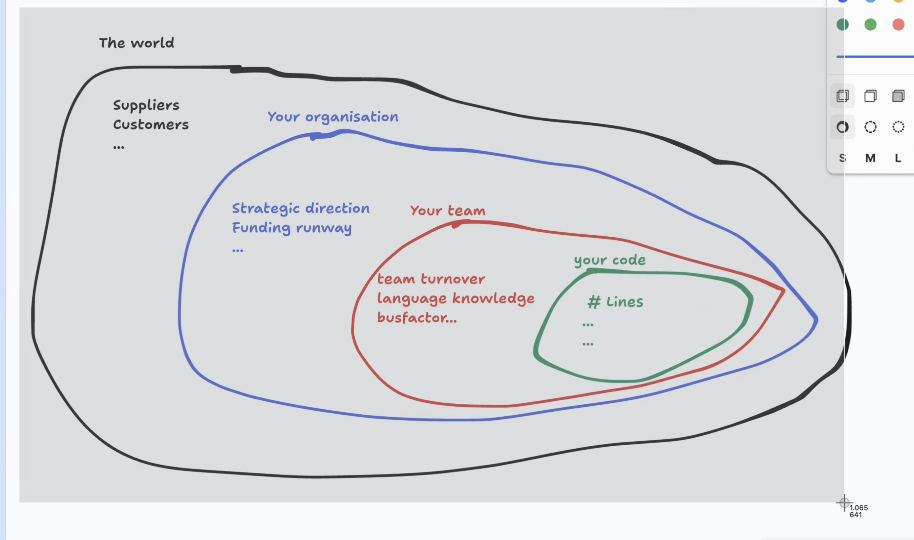


3 steps to build context:
- OAI vs Anthr
- Rens example, there's much more that affects the code
- Peter Naur actually formalized this, highlight much more that you can never capture this fully, as soon as it's written it's outdated
- Simplify Examples a lot, explain Naur's examples just as a handover
- What can you learn from this paper talking w/ your AI?

- we should use naur as an explanation of why this drawing we introduced can NEVER capture the full thing. Theory can never fully captured, and why it can't be (maybe examples)
- previous can be perfect build up to why your AI can't simplify your code without you.

- we simplified the Theory 'the billing system' not the code, we know only credit people (simpler)
- then India example, LLM suggested to go back to subscriptions because it didn't know


- remember peole this is not a solved problem
- and it can't never be fully solved

- Final point: tell AI to discuss w/ you (the prompt example). Let the AI pull the theory out you.

Summarize ...

## What are we trying to simplify?

When we answer those questions, we **are** trying to simplify something. 

What *is it* though?

---

## So far (probably drop this, not needed)

1. Code complexity metrics can't tell you which code is simpler
2. The information to make code simpler is not in the code or docs?

So where is the information?

Speaker note: "The thing that decided wasn't in the code. It wasn't in the docs either. So what was it, and where does it live? Turns out someone named it forty years ago."

## Enter Peter Naur

In *Programming as Theory-building* paper (1985) Naur proposed that programming is an activity that builds a "Theory"

We want to simplify this Theory, not the code only.

![](https://imgproxy.gamma.app/resize/quality:80/resizing_type:fit/height:400/https://cdn.gamma.app/sxs4nuxguimkstb/194f3c117c9b463f82df85c2a3734a1f/original/0-mawhU1WTyXne_mi_.jpeg)

### but before that...
---

## We want to minize the Theory

### Programming as Theory Building - Peter Naur (1985)

What we are trying to simplify is not the code itself.

We want to simplify the **Theory's** complexity. 

![](https://imgproxy.gamma.app/resize/quality:80/resizing_type:fit/height:400/https://cdn.gamma.app/sxs4nuxguimkstb/194f3c117c9b463f82df85c2a3734a1f/original/0-mawhU1WTyXne_mi_.jpeg)

## Side Quest: close reading in Solveit

- [Fork this Solveit dialog to read the paper](https://share.solveit.pub/d/813cc704f8ce5f5f75b8fcd991fba816)
- [Resources: how to close read in Solveit](https://www.fast.ai/posts/2026-01-21-reading-LLMs/)

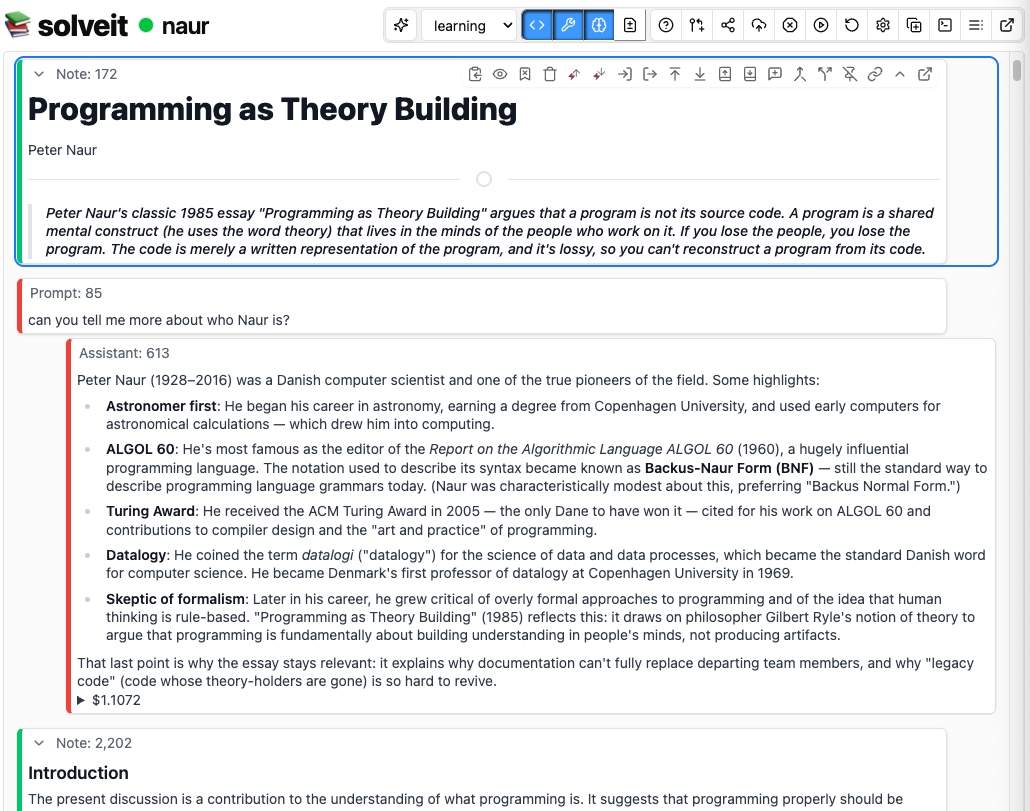
---

## Side Quest: close reading in Solveit

- [Fork this Solveit dialog to read the paper](https://share.solveit.pub/d/813cc704f8ce5f5f75b8fcd991fba816)
- [Resources: how to close read in Solveit](https://www.fast.ai/posts/2026-01-21-reading-LLMs/)

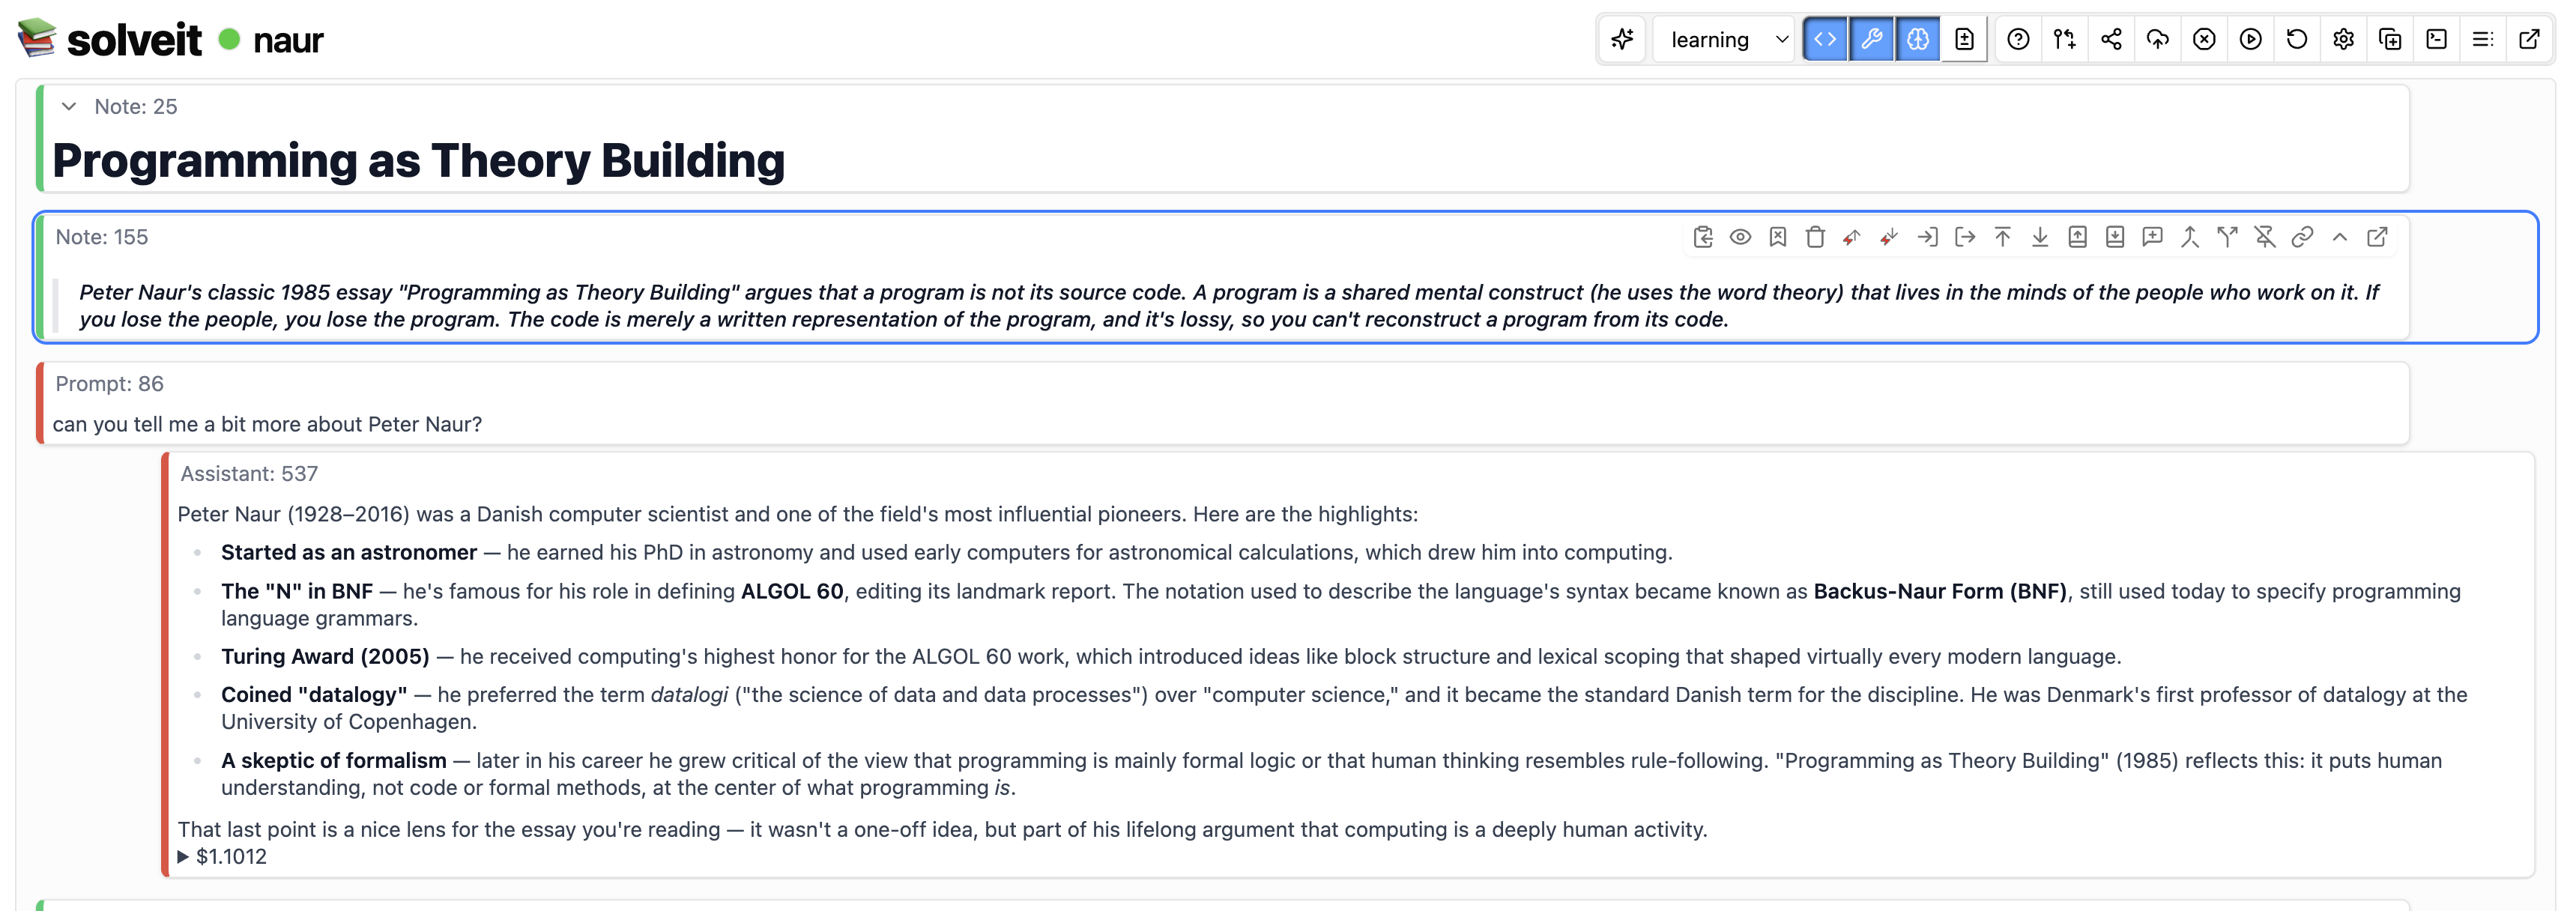

---

Remove the close reading from the talk, but maybe keep it in the youtube version for engaged people

Speaker note: click the share link, import, ask one question ("can you tell me more about Peter Naur?"). Don't read the answer. "That's the workflow. Video link if you want more." 60 seconds.

## Naur's Theory

> A program is the Theory held by the people who build and maintain it.

This Theory includes:

- How the program relates to the real-world problem
- Which constraints and trade-offs produced it
- Why it works
- Which changes fit its design

Code and documentation are incomplete artifacts of that Theory.

---

In [ ]:
%%prompt
the "The theory includes" section is very useless it does not clarify, what I did write about the Theory in my post? I was explaining it out loud and just fell flat in there.

Your post said two things about the Theory, and the slide only kept one of them.

1. **The definition** (first paragraph of your tl;dr): "an understanding of how the program relates to the real-world problem, which constraints and trade-offs shaped it, why it works, and which changes would fit its design." That's the bullet list on the slide, almost verbatim. Alone it's a list of nouns — nothing on it *does* anything, so there's nothing to say out loud.

2. **How it's built and what it does** (second paragraph, which the slide dropped): engineers develop it *through experience* — talking to users, observing failures, learning the domain — and it "guides judgments of relevance, similarity, **simplicity**, and good design." That last word is your whole talk. The Theory is the thing that produces the answer to "which one is simpler?" — and you just made the audience exercise it two slides earlier without naming it.

The post also grounds it three concrete ways that the slide doesn't use:

3. In "Enter the Theory": the boss's "we're dropping Anthropic" *is* a piece of the Theory. You can hand fragments of it to an LLM as context (business priorities, expected changes, past decisions), but those are artifacts; the judgment behind them doesn't transfer.

4. In the Stripe section: a Theory can be small enough to fit in one sentence ("Customers add a card at signup; we charge it manually or automatically"). That makes the abstraction tangible — it's a thing with a size.

5. In the interfaces section: a good API means a library's code doesn't count toward *your* Theory — until the contract breaks and you have to look inside.

So the fix isn't rewording the bullets, it's changing what the slide is *for*: instead of defining the Theory, point back at the exercise — "the thing you just used to change your answer when the boss spoke: that's the Theory" — then one line on where it comes from (experience, not code) and one on what it does (decides what "simpler" means). The four-bullet definition can live in the speaker notes or the paper link.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 74526, "completion_tokens": 662, "total_tokens": 76252, "reasoning_tokens": 1064, "cost": 1.5165674999999998}
```


In [ ]:
%%prompt
can you propose the slide as you say?

Here's a version that points back at the exercise instead of defining:

````markdown
## Naur's Theory

> A program is the Theory held by the people who build and maintain it.

The thing you just used to change your answer when the boss spoke — *that's* the Theory.

- Built from **experience**: talking to users, seeing failures, learning the domain
- Decides what *relevant*, *similar*, and **simpler** mean

Code and docs are downstream artifacts. They never contain all of it.

---
````

And a speaker note to go under it:

````markdown
Speaker note: Don't read the bullets. Say: "Two slides ago you all picked the right answer as soon as I mentioned the boss. Nothing in the code changed. What changed was something in your head — Naur calls that the Theory. You built it from the conversation with the boss, not from reading the file. And it's what told you which version was simpler. That's the whole claim: simplicity is a judgment the Theory makes, and the Theory is never fully in the code." Then move on; the four-part definition is in the paper link.
````

One structural note: the slide before this one ("What are we trying to simplify?") already asks the question this slide answers, so the two form a question/answer pair. If you keep "So far (probably drop this)" between them, it dilutes the reveal — I'd drop it as you suspected.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 75245, "completion_tokens": 435, "total_tokens": 75750, "cached_tokens": 71794, "reasoning_tokens": 70, "cost": 0.208941}
```


## Naur's Theory

> A program is the Theory held by the people who build and maintain it. 

> The code & docs are just downstream artifacts.

The theory is:
- Built from **experience**: talking to users, seeing failures, learning the domain
- Decides what *relevant*, *similar*, and **simpler** mean

<!-- The thing you just used to change your answer when the boss spoke *that's* the Theory. -->
Code and docs are downstream artifacts. They never contain all of it.

---

Speaker note: Don't read the bullets. Say: "Two slides ago you all picked the right answer as soon as I mentioned the boss. Nothing in the code changed. What changed was something in your head — Naur calls that the Theory. You built it from the conversation with the boss, not from reading the file. And it's what told you which version was simpler. That's the whole claim: simplicity is a judgment the Theory makes, and the Theory is never fully in the code." Then move on; the four-part definition is in the paper link.

## Example 1: The Theory is preserved

- Group A builds a compiler. Group B extends it.
- Group B has the code, the docs, and can ask Group A.
- Their extensions work. Group A repeatedly sees a much simpler way, using what was already there.


![](https://imgproxy.gamma.app/resize/quality:80/resizing_type:fit/height:400/https://cdn.gamma.app/sxs4nuxguimkstb/97c412cc9ea54da68257a96b586c4941/original/image.png)

---


```python
Speaker notes: flesh out 2 or 3 more modern examples to give the audience. Like:
- In Django, do we put things in the model or the view? the overall "know-how" that results from training/onboarding
```

## Example 2: only the artifacts remain

- Group A leaves. Group B keeps the code and the docs.
- Years later, the compiler still works and is still extended.
- Every change was a patch. The original design is buried underneath.

![](https://imgproxy.gamma.app/resize/quality:80/resizing_type:fit/height:400/https://cdn.gamma.app/sxs4nuxguimkstb/20b1ca4caadf4b408f32dc1f8062fd6e/original/image.png)
---

## Where does Theory come from?

Engineers develop it by:

1. Talking to users
2. Observing failures
3. Learning the domain
4. Seeing production behavior
5. Understanding business priorities
---

(This is so far unexported, not sure if it's wort adding)
## Sounds familiar?

Humans code slowly -> Theory drifts slowly.

LLMs code very fast -> the Theory can die very fast. 

The codebase might have:
- full coverage
- green test suite
- e2e testing working

but still look like a **hot mess**.

The Theory is lost. But... does it matter?


Speaker note: "Every one of you has reviewed an LLM PR like this: locally correct, doesn't fit. That's Group B, at machine speed. The greenfield project that looked great becomes a mess after a month of vibe-coding. And notice the tests can't catch it. The compiler worked for ten years. So does it matter? If you'll never change it again, no. Disposable app, ship it. For anything you'll keep, the next change is where you pay. Let me show you what that looks like when it's your money."

In [ ]:
%%prompt
I think it's more text than usual but I think it's fine for now

Agreed — it's a turning-point slide, so it can carry more. Two small things to fix when you touch it: "The Theory is lot" → "lost", and the "hot mess" line reads better as the punch on its own:

```markdown
but still be a **hot mess**.

The Theory is lost. But... does it matter?
```

Next is 14, the second "So far", now with the tests line:

```markdown
### 14. So far

1. Metrics can't tell you which code is simpler
2. Something outside the code decided
3. Naur calls it the Theory. It lives in people, not files.
4. Tests check the artifact. They can't see the Theory die.
```

Then 15–16, the billing story. Your earlier objection stands: use the post's sentences, and bridge from "does it matter?" rather than dropping into Stripe cold. The "Spoiler alert" line does that — it answers the question ("it matters to us, a lot") before the story starts:

```markdown
### 15. Our billing system

Spoiler alert: at Answer.AI we are heavily invested in minimizing complexity at all costs.

The initial plan was a monthly subscription (e.g. $5) that becomes credits to consume during the month.

- Subscriptions -> managed by Stripe subscriptions
- Top up -> Stripe checkout

Half of the data lives in Stripe's backend and you have to make sure your local DB is synchronized with it.

![](https://miro.medium.com/v2/resize:fit:1400/1*IukX7qQxLWG9hmZQdixFYw.png)

Speaker note: "Does it matter? To us, yes. If a payment does not show up, is it because Stripe did not send the webhook, their fault, or because we failed to store it, our fault? You debug two systems. Two payment paths, two kinds of credit, state in two places. Nobody could hold it in their head. Me included."
```

```markdown
### 16. The AAI way

First of all, we would do credits only and charge based on usage.

> Customers add their CC when they sign up and then we charge that card either manually (topup) or automatically when the credit goes low

Both manual and automatic top up use the same payment path. Our entire payment stack, split between Solveit & faststripe, is roughly 300 lines of code.

Speaker note: "That sentence is the Theory of our payment system. The old one didn't fit in a sentence. Getting here took days of exploration and discussion; the code was the easy part. Now let's see it run."
```

Then 17 is the demo.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 154540, "completion_tokens": 826, "total_tokens": 155366, "cost": 2.9562075}
```


## Recap & real example

1. Code metrics can't tell you which code is simpler
2. The information is not in the code 
3. The information lives in people's minds. It is the program's Theory
<!-- 4. Tests can not preserve a good Theory -->

---

## Use Case: Solveit Billing

> Spoiler alert: at Answer.AI we are heavily invested in minimizing complexity at all costs.

**The problem**: Build a billing system for Solveit.
&nbsp;
&nbsp;

Solveit is a platform that has **persistent instances** where you can run notebooks and use **LLMs**

We need to charge for:
- Hardware per instance: CPU, BW, RAM, Egress
- LLM cost per call

---

we could do that much simpler: a 2 sentences explanation, we originally had subscriptions and then you could manually top up, but it had a lot of book keeping, then we simplified the Theory until this single sentence

then India happened and I had to bring in this outside context, etc.. Just explain the story instead of the code etc... Learn more into the story telling.

## Initial approach

The initial plan was:
1. A $5 monthly subscription that becomes credits to consume during the month.
2. Allow to top up more credits if subscription runs out.

This mapped into these Stripe services:
- Subscriptions ->  managed Stripe subscriptions
- Manual Top up -> Stripe checkout

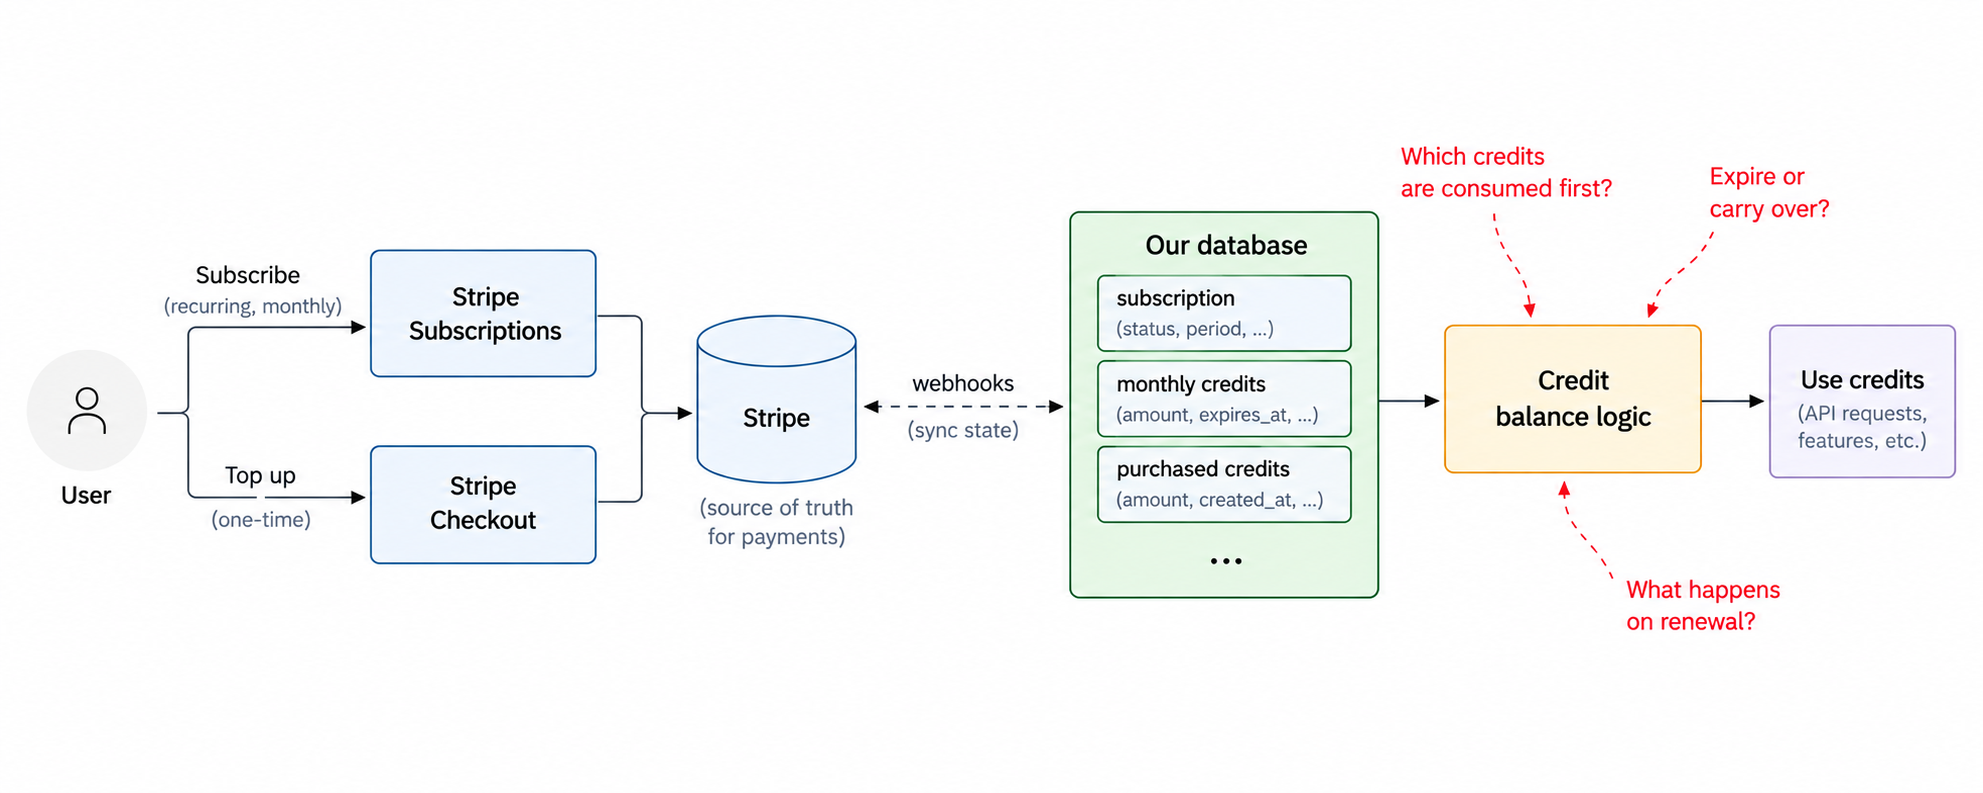
---
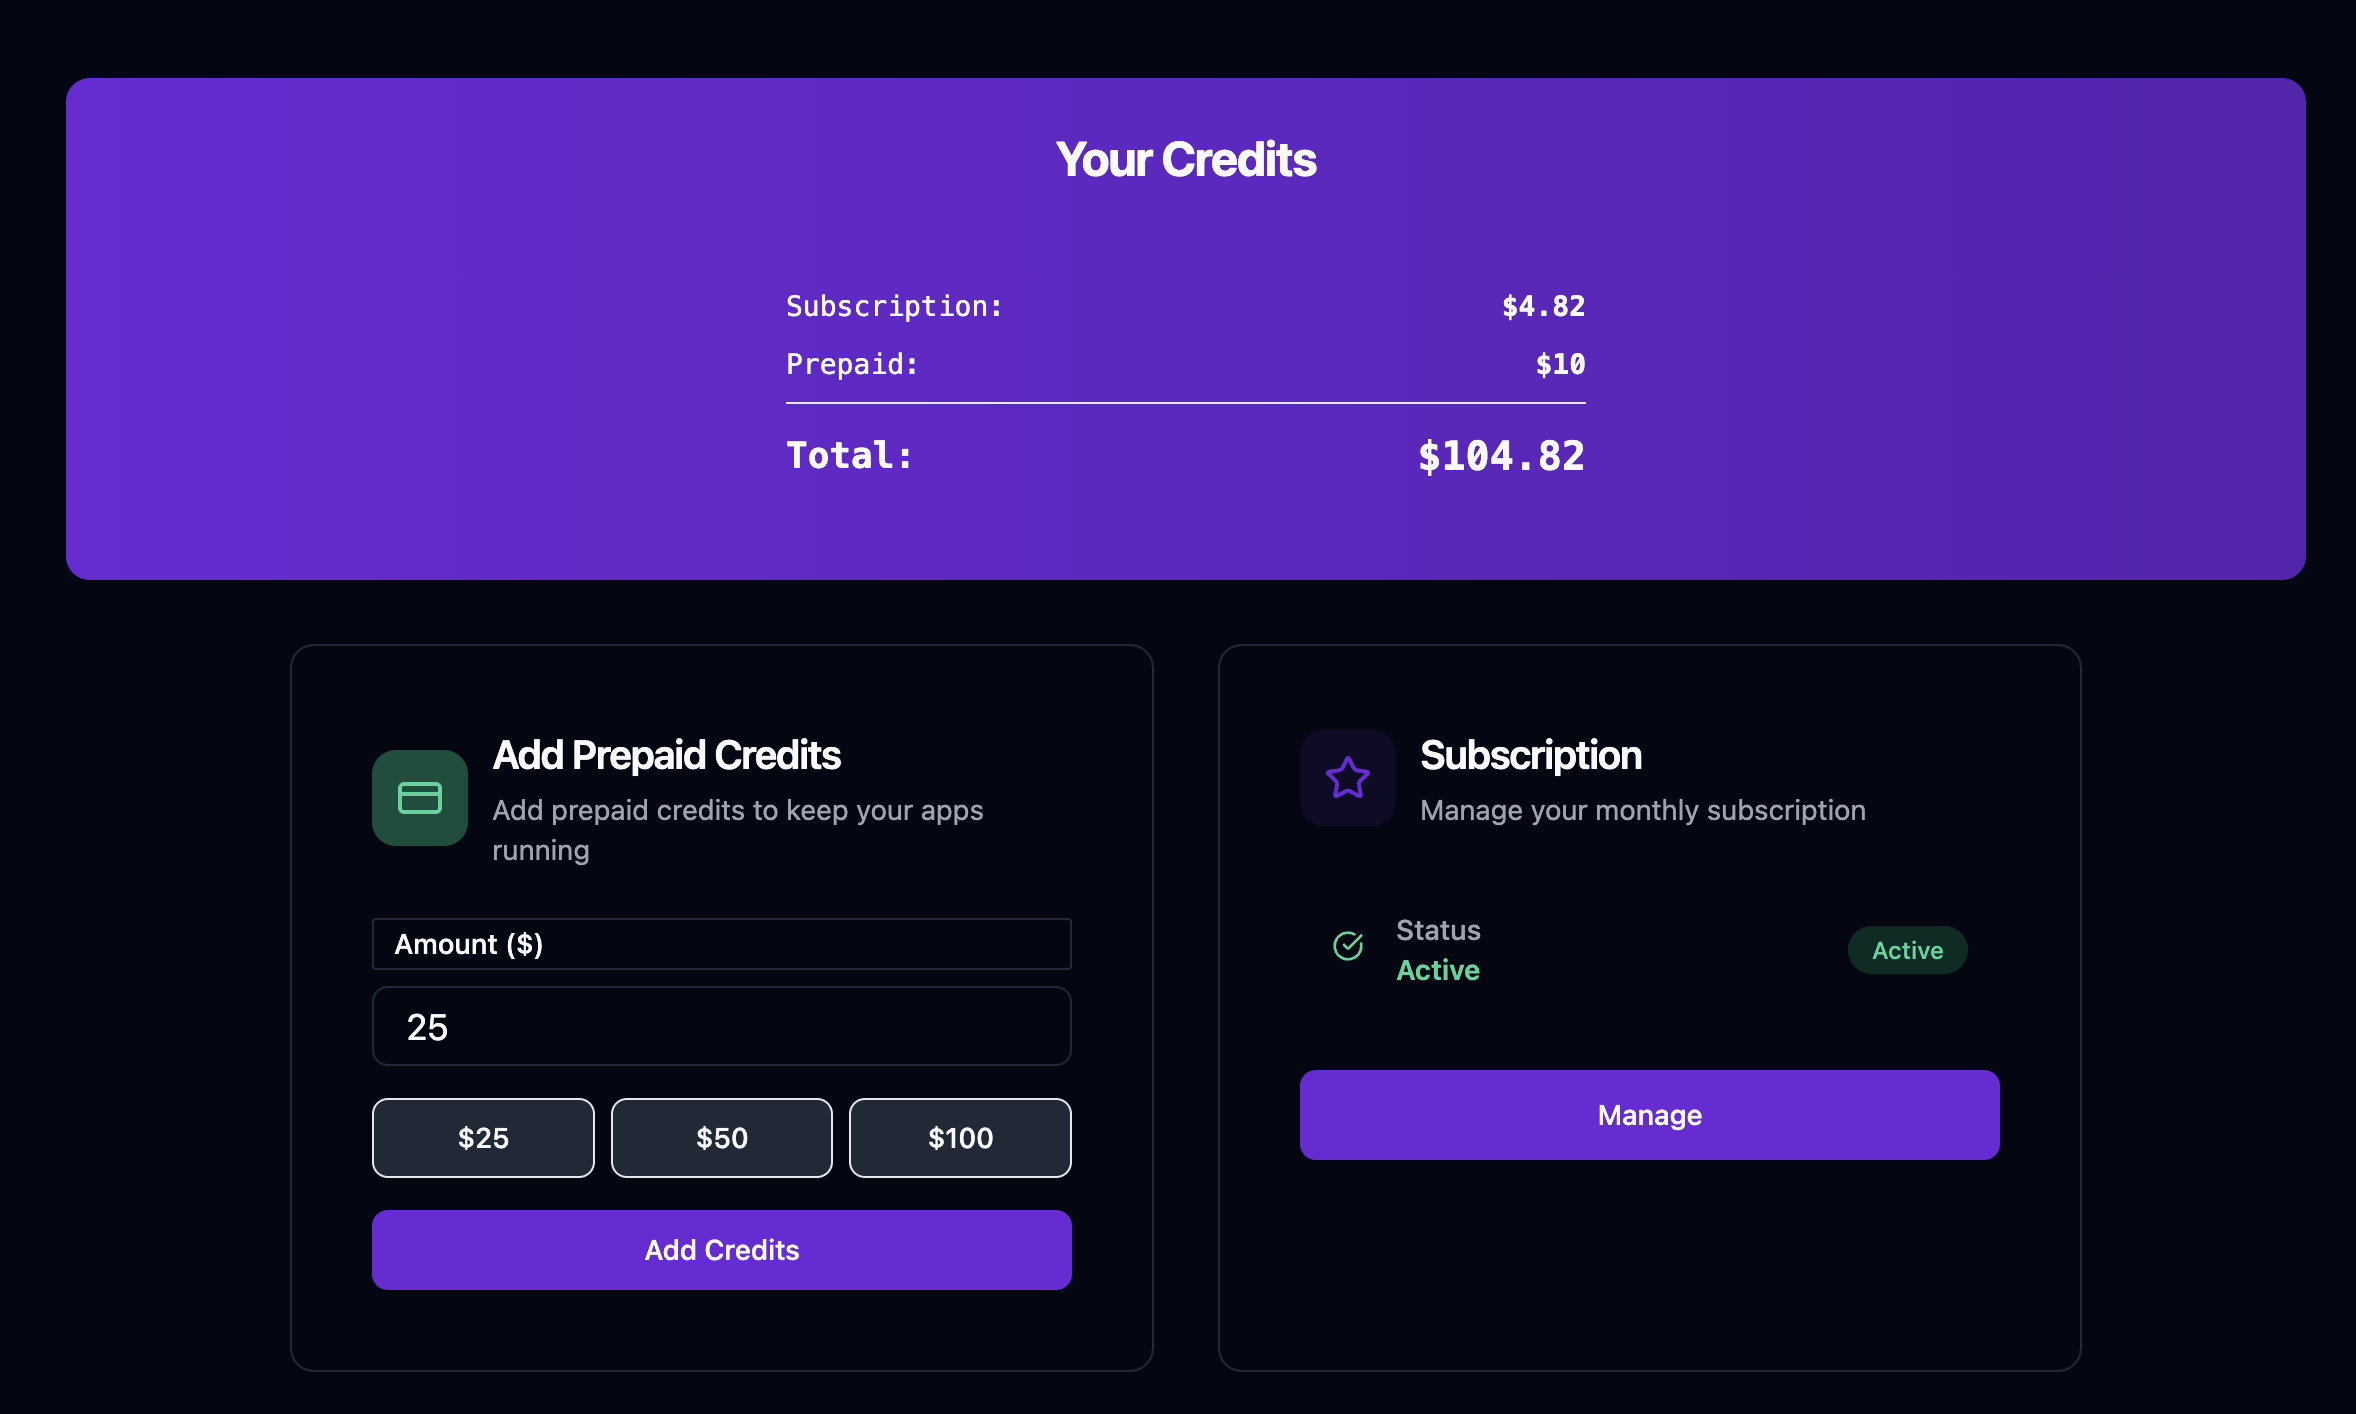

## Initial approach: Problems

- Hard to explain to users
- Multiple types of "credit"
- Duplicated state between Stripe & our DB
- Difficult rules for logic

<!-- ![image.png](attachment:b9b04bc8-7546-4e20-83a8-04f279dcb7a6)
// TODO, move this & other img attachments to a img folder so it can be reused. -->

---

## What was our simplification process?

- Frequent internal discussions
- Multiple versions coded and merged 
- MVP in smaller service as a trial run
- Feedback from users
- Multiple iterations on key libraries like `faststripe`

<!-- ![raptor](./img/raptor.webp) -->

---

## Billing System v2

After many iterations the **billing system Theory** is a single sentence:

> Customers add their CC when they sign up and then we charge that card either manually (topup) or automatically when the credit goes low

---

## Billing System v2

After many iterations the **billing system Theory** is a single sentence:

> Customers add their CC when they sign up and then we charge that card either manually (topup) or automatically when the credit goes low


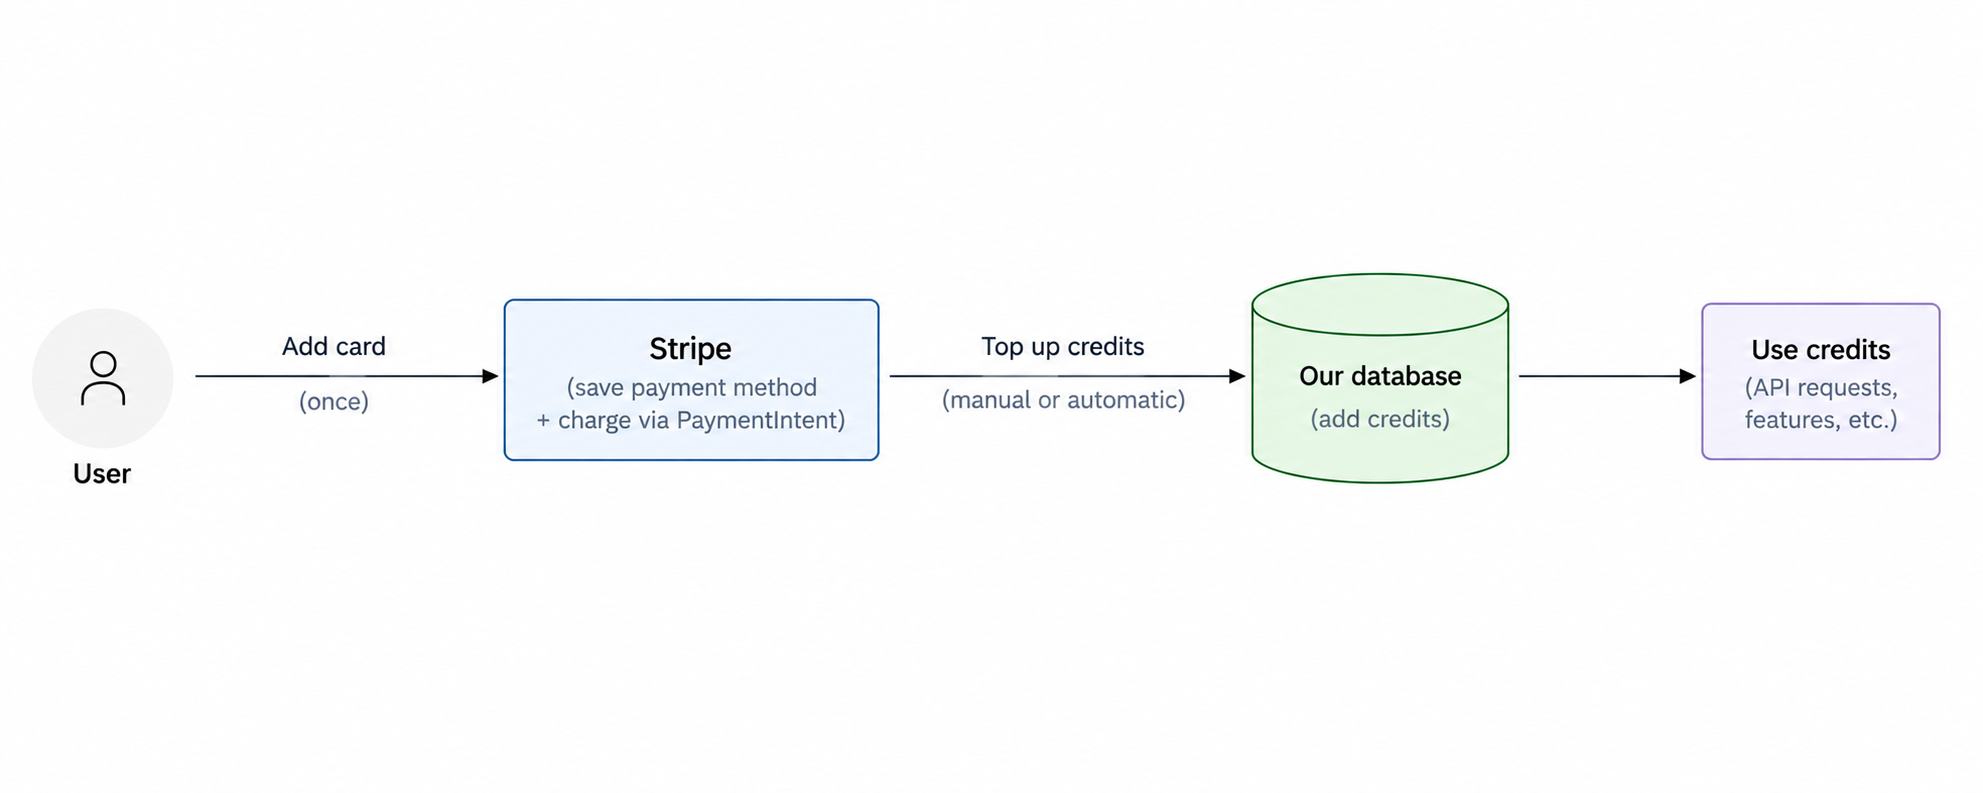

---

## Billing System v2

After many iterations the **billing system Theory** is a single sentence:

> Customers add their CC when they sign up and then we charge that card either manually (topup) or automatically when the credit goes low
![image.png](attachment:fa222c3a-85fe-43ef-a22a-39883d57dd19)

We got rid of:
- Different credit types
- Stripe subscriptions & checkouts
- No need to fish for data in Stripe UI


---

## Billing System v2

After many iterations the **billing system Theory** is a single sentence:

> Customers add their CC when they sign up and then we charge that card either manually (topup) or automatically when the credit goes low
![image.png](attachment:fa222c3a-85fe-43ef-a22a-39883d57dd19)

The **advantages**:
- Both manual & automatic top up use the same payment path
- The entire payment logic is around ~300 LoC
- All operational payment data is in our DB


---

### 16. The AAI way

First of all, we would do credits only and charge based on usage.

> Customers add their CC when they sign up and then we charge that card either manually (topup) or automatically when the credit goes low

Both manual and automatic top up use the same payment path. Our entire payment stack, split between Solveit & faststripe, is roughly 300 lines of code.

Speaker note: "That sentence is the Theory of our payment system. The old one didn't fit in a sentence. Getting here took days of exploration and discussion; the code was the easy part. Now let's see it run."

In [ ]:
%%prompt
I think 16 is no longer needed, what next?

Agreed — your "Final Billing System" pair already does that job, and the "Simplification process" slide is a better bridge than my speaker note was. Remaining slides per the plot: demo → India → LLM's answer → what we did → final "So far" → links.

Next two, sentences from the post:

```markdown
## Demo

Solveit + faststripe + fastllm: sign up -> card on file -> top up -> chat

Speaker note: fixed script, app pre-running, screenshot fallback. "Everything you just saw is in the repo."
```

```markdown
## Enter India

So what happened on launch day? Did everything go smoothly?

**No.**

After launching we realized that Indian cards do not support direct debit mandates, so we could not charge them at will.

- Manual top up: works (3DS-like approval flow in our UI)
- Auto top up: **broken**

Speaker note: "When exploring for solutions, we discovered that Stripe managed subscriptions actually work in India. Stripe creates the payment intent the day before, so banks can pre-approve it or ask the user to confirm. When we migrated away from managed subscriptions, we lost that."
```

Then the LLM's answer slide — the post's "Do you care to guess at the proposed solution?" wants a pause before the reveal, so it's probably two slides: the question, then `> Use Stripe subscriptions`.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 85978, "completion_tokens": 453, "total_tokens": 87122, "reasoning_tokens": 691, "cost": 1.6903087499999998}
```


In [ ]:
%%prompt
I am not sure whether to do the demo at this point or after India. Not sure if the demo is a bit shoehorned tbh

Honest answer: as "watch me sign up and chat," yes, it's shoehorned. The argument doesn't need a running app; nothing about Theory is shown by a checkout succeeding. It's in the talk because the abstract promised it and the crowd is hands-on. Those are real reasons, but they make it a coda, not a beat.

Three ways to resolve it:

1. **Make the demo the evidence for the ~300 LoC claim, and put it right after "Final Billing System".** The thing to show isn't the app running, it's the *code*: open faststripe + the Solveit billing module, scroll through, "this is the entire payment system." That directly supports the slide before it (Theory in one sentence, code in a few screens). The app running is 30 seconds at the end of that: card, top up, balance changes. Then India lands as the twist: "It looked done. Then launch day." Demo before a reversal is a natural rhythm.

2. **Make the demo carry India.** Stripe has Indian test cards (e.g. `4000 0035 6000 0008`). Run a top-up with a normal card, then with the Indian card: manual works via the 3DS prompt, auto top-up fails. Now the demo *is* the India beat and nothing is shoehorned. Cost: doubles the live-failure surface, and it's the one part you can't fully rehearse against Stripe's mood that day.

3. **Cut the live demo to a link + one screenshot on the Final slide,** and put the code walkthrough in the repo README. Frees ~4 minutes, removes all network risk, and the talk closes on the argument. You lose the "hands-on" moment the abstract implied.

I'd do 1. It turns the demo from a feature tour into proof of the specific claim you just made, it stays before India where the "but then" rhythm wants it, and it keeps the ending on the LLM's answer rather than a UI. Option 2 only if you have a spare evening to rehearse it twice against Stripe test mode. After India is the wrong slot in every version: the argument has closed, and the demo would have nothing to say about it.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 86516, "completion_tokens": 680, "total_tokens": 88191, "cached_tokens": 83957, "reasoning_tokens": 995, "cost": 0.29723924999999995}
```


In [ ]:
%%prompt
I think it all sounds good. I will show a bit the demo code (because I don't want to share production code obv) and maybe do a manual top up. Then next slide: we were ready, we released? what happened? Then next slide presents the India issue, but it will have a screenshot that I'll reproduce in the demo (it won't have india support). 

That order works — demo code + a manual top-up proves the ~300 LoC claim, and "we released, what happened?" gives India its pause. Three notes:

```markdown
## Demo

- Code walkthrough: faststripe + a minimal Solveit-like app
- Manual top up with a test card

Speaker note: "This is not production code, but it's the same shape. Card on file at signup, one charge path." App pre-running, screenshot fallback.
```

```markdown
## Launch day

So we were ready. We released.

Did everything go smoothly?

Speaker note: pause. Let someone say "no."
```

```markdown
## Enter India

After launching we realized that Indian cards do not support direct debit mandates, so we could not charge them at will.

- Manual top up: works, users get a 3DS-like approval flow
- Auto top up: **broken**

![india](./img/india-3ds.png)

Speaker note: "You saw the top-up flow a minute ago. This is what an Indian card gets instead: an approval step we can't skip, so charging at will is impossible. When exploring solutions we discovered Stripe managed subscriptions actually work in India: Stripe creates the payment intent the day before, so banks can pre-approve it or ask the user to confirm. We'd migrated away from exactly that."
```

For the screenshot: capture it in Stripe test mode with an Indian test card (`4000 0035 6000 0008`) against your demo app, so it visually matches what the audience just watched — same UI, one extra step.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 87572, "completion_tokens": 500, "total_tokens": 88160, "cached_tokens": 83978, "reasoning_tokens": 88, "cost": 0.235782}
```


## Show me the Code!

- Code walkthrough: faststripe + a minimal Solveit-like app
- Manual top up with a test card
---

Speaker note: "This is not production code, but it's the same shape. Card on file at signup, one charge path." App pre-running, screenshot fallback.

## Launch day

So we were ready. We released.

Did everything go smoothly?
---

Speaker note: pause. Let someone say "no."

## Enter India

On launch day we noticed Indian cards do not support direct debit mandates

 so we could not charge them at will.

- Manual top up: works, users get a 3DS-like approval flow
- Auto top up: **broken**

<!-- ![india](./img/india-3ds.png) -->

---

Speaker note: "You saw the top-up flow a minute ago. This is what an Indian card gets instead: an approval step we can't skip, so charging at will is impossible. When exploring solutions we discovered Stripe managed subscriptions actually work in India: Stripe creates the payment intent the day before, so banks can pre-approve it or ask the user to confirm. We'd migrated away from exactly that."

In [ ]:
%%prompt
I think "do not support direct debit mandates" is not the correct term because they do support manual top up, can you find the proper term?

The term you want is **off-session** (or **merchant-initiated**) payments. Let me confirm Stripe's exact wording, since that's what the audience will recognise.Confirmed. The distinction you're after is **on-session vs off-session** payments, and the regulation is the **RBI e-mandate** framework.

Your slide's current wording is inverted: Indian cards *do* support mandates — they *require* one. What they don't allow is charging a saved card at will. Stripe's docs put it precisely: while the regulation refers to "recurring" payments, networks treat any off-session (that is, merchant-initiated) transaction as in scope, and without a mandate for an off-session payment, the card issuer will likely decline the payment.

The rules themselves: banks need to register cardholders and create an e-mandate through a one-time process, using additional factor authentication (AFA) like 3D Secure (3DS); banks must alert cardholders at least 24 hours before charges take place and give them the ability to opt out of transactions; recurring transactions over 15,000 INR (or equivalent in other currencies) must go through AFA each time.

So manual top-up works because it's **on-session** — the user is present and clears 3DS. Auto top-up is **off-session** and needs an e-mandate with a 24-hour pre-debit notice, which is exactly the machinery Stripe subscriptions already have and yours doesn't. The Stripe FAQ even names your workaround: if an e-mandate cannot be created, you should consider alternatives, such as bringing your customers back on session to complete the payment with 3DS.

Suggested rewrite of the slide's first lines:

```markdown
On launch day we noticed India-issued cards can't be charged **off-session**.

RBI rules require an **e-mandate** for any merchant-initiated charge: registered via 3DS, with a 24h pre-debit notification before each debit.

- Manual top up (on-session): works, the user clears 3DS
- Auto top up (off-session): **broken**
```

And in the speaker note, the "Stripe creates the payment intent the day before" line is the pre-debit notification — worth naming it, since it's the concrete thing subscriptions gave you for free.

```json {.tool}
{
  "id": "srv_1dfd09d00177c8dc96d1060c2805d476",
  "name": "web_search",
  "args": {
    "query": "Stripe India RBI e-mandate off-session payments recurring"
  },
  "result": "https://docs.stripe.com/india-recurring-payments.m...: https://docs.stripe.com/india-recurring-payments.md?integration=paymentIntents-setupIntents\nIndia recurring payments | Documentation de l'API: https://stripe.com/docs/india-recurring-payments?locale=fr-CA\nStripe RBI e-Mandate Impacts - Chargebee Payment Docs: https://www.chargebee.com/docs/payments/2.0/payment-gateways-and-configuration/stripe-rbi-e-mandates\nRBI e-mandate regulations FAQs : Stripe: Help & Support: https://support.stripe.com/questions/rbi-e-mandate-regulations-faqs?locale=en-GB\nBackground on Indian government regulations affecting card payments : Stripe: Help & Support: https://support.stripe.com/questions/background-on-indian-government-regulations-affecting-card-payments\nWhat are the new Stripe India RBI e-mandate changes?: https://www.chargebee.com/docs/payments/2.0/kb/billing/what-are-the-new-stripe-india-rbi-emandate-changes\nIndia recurring paymentsPublic preview: https://stripe.com/docs/india-recurring-payments",
  "server": true,
  "md": true
}
```

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 184427, "completion_tokens": 874, "total_tokens": 185781, "cached_tokens": 87774, "reasoning_tokens": 480, "web_search_requests": 1, "cost": 2.0574885}
```


In [ ]:
%%prompt
great, what are the next slides we need?

Remaining per the plot: the LLM's answer (question, then reveal), what you did, the final "So far", and links. Sentences from the post:

```markdown
## Asking for help

When exploring for solutions, we discovered that Stripe managed subscriptions actually work in India.

So I asked [INSERT FAVORITE LLM HERE] how we could handle this.

Do you care to guess at the proposed solution?

Speaker note: pause. Someone will say it.
```

```markdown
## The proposed solution

> Use Stripe subscriptions

Or: support both systems (ready to code it all for you, at your word!)

It had the code. It didn't have the Theory.

Speaker note: "Locally correct. Solves India. And it's the exact system we'd spent weeks removing. This is Group B, at machine speed."
```

```markdown
## What did we do?

Nothing.

Requiring Indian users to manually top up was ok, in exchange for a simpler and more robust platform.

If you don't agree, reflect on why not. What are your arguments and, more specifically, **where** do they come from?

- Revenue matters most -> extra friction loses India sales, migrate back
- Sales team lives in the Stripe Dashboard -> our DB is the wrong place
- ...

Speaker note: ask the room. Every argument they give is business context, users, or priorities. None of it is in the code. That's the point: there's no right complexity. Ours matches our Theory.
```

```markdown
## So far

1. Metrics can't tell you which code is simpler
2. The information is not in the code
3. The information lives in people's minds. It is the program's Theory
4. What we simplified was the Theory. The code followed.
5. The LLM had all the code. It never had the Theory.

That's why LLMs can't make your code simpler.
```

```markdown
## Thanks

- Paper: Programming as Theory Building, Peter Naur (1985)
- Fork the close-reading dialog: [link]
- Slides, demo app, faststripe: [github.com/kafkasl/code-complexity-talk](https://github.com/kafkasl/code-complexity-talk)
- Blog post: [medium link]

Questions?
```

The "What did we do?" bullets are from the post's list; whether you show them or let the room produce them first is a judgment call for the day. Showing them after the audience has answered works better than before.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 88642, "completion_tokens": 784, "total_tokens": 89535, "cached_tokens": 87774, "reasoning_tokens": 109, "cost": 0.21356849999999997}
```


## Asking for help

So I asked [any LLM] how we could support Indian users?

Do you care to guess at the proposed solution? ...

---

Speaker note: pause. Someone will say it.

## Asking for help

So I asked [any LLM] how we could support Indian users?

Do you care to guess at the proposed solution? ...  **Use Stripe subscriptions**
---

## The proposed solution

> Use Stripe subscriptions

**Me:** But we just migrated OUT of Stripe subscriptions

**LLM:** I can: 
- A. Revert back those changes
- B. Support both systems (ready to code it all for you, at your word!)

### So once again, which solution is correct?
---

Speaker note: "Pause for people to think. Solution is C FOR AAI, do nothing."

## What did we do? Nothing.

- Requiring Indian users to manually top up was ok
- We value more a concise payment Theory

Do you not agree? Reflect on why not.

What are your arguments and, **where** do they come from?

What if?
- Revenue matters most -> friction loses India sales, migrate back
- Sales uses Stripe UI -> our DB-first approach is wrong
- ...

Doing nothing was **our** solution, but it's not necessarily the best for all.
---


Speaker note: ask the room. Every argument they give is business context, users, or priorities. None of it is in the code. That's the point: there's no right complexity. Ours matches our Theory.

## What ruthless simplification looks like

![raptor v3](./img/raptor.webp)

The years of Theory that produced it are not in the picture.

LLMs can help you get here, but not without a lot of effort.
---

nice visual example not clear where to fit it. Where does this support the explanation, this is a illustration.

SEXI in talks

Speaker note: "Everyone loves this picture. Notice what you're admiring: the artifact. The thousands of decisions, failed tests and trade-offs that made v3 possible are invisible here, exactly like the Theory is invisible in the code. LLMs help you write v1 fast. Getting to v3 is still on you."

## What to do with this?

LLMs know about Naur's Theory. Use it when prompting.

> Let's discuss the Theory (capital T, Naur) of this before we touch the code.

- The LLM "gets" there is something above the code that the code only approximates
- It can distinguish implementation details from a break in the Theory
- Good moment for it: new codebase, PR review, "why is this so complicated?"

**Bonus material**: [our Naur skill in AnswerDotAI/aai-coding repo](https://github.com/AnswerDotAI/aai-coding/blob/main/aai_coding/theory.py)
---

THIS IS THE PART TO SCREENshot people, the LLM prompt thing (joke)

Speaker note: "I do this with Claude Code and ChatGPT constantly. It turns 'refactor this' into a conversation about what the program is for, and the model stops treating every line as sacred. It's not magic: the Theory still isn't in the code. But naming it means the model asks you for the parts it can't see, instead of guessing."

## "Just write it all down"

Add every bit of context and intent to the PR and docs. Problem solved?...

No:

- Artifacts are always incomplete
- Most knowledge is tacit, not materialized
- LLM (& human) context limits
- History is not always a good future predictor

---

## Will LLMs ever get the Theory?

Today: they see the artifacts, once, from the outside.

What Theory-building needs:

- Aligning to the Theory based on exp & user feedback
- Theory gets degraded on each schizophrenic respawn
- Interacting with the real world users, failures, production

This requires some form or embodiment & continual learning / memory 
- 
---

this is more like either a call to action to solve this problem, or part of the context as in "how can you improve the context giving?"

## The end

> A program is the Theory held by the people who build and maintain it... at least for now.

- Slides, code & links: [github.com/kafkasl/code-complexity-talk](https://github.com/kafkasl/code-complexity-talk)
- Full post: [Why LLMs can't make your code simpler](https://medium.com/@pol.avec/why-llms-cant-make-your-code-simpler-fc2cd36bc0c8)
- Paper: Programming as Theory Building, Peter Naur (1985)

Questions?
---

rephrase ending like


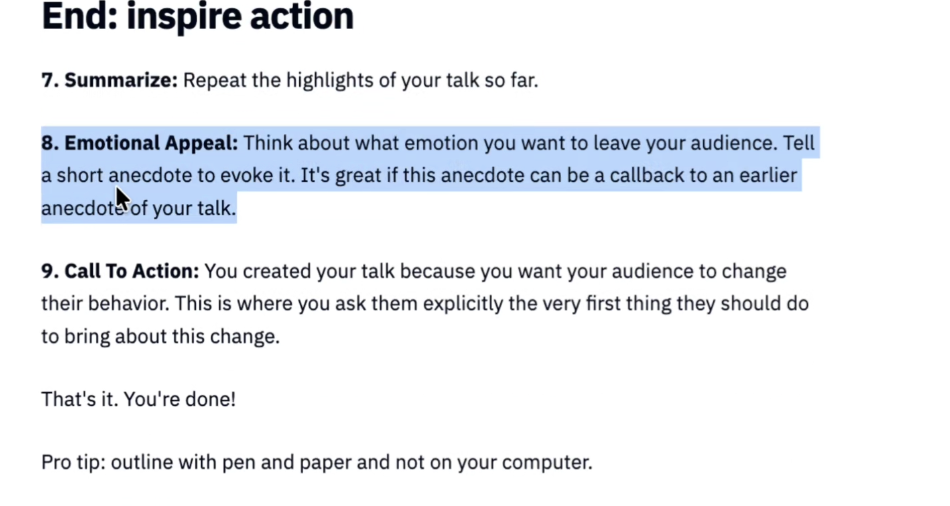


In [ ]:
%%prompt
do you think I should add a slide with the "indian cards business opportunity"? after the "What did we do"? I am also not sure to include the 2 slides for just write it all down and will LLMs ever get a Theory. Opinions pros, and cons of closing this?

Three separate calls, numbered:

1. **Business opportunity slide: no slide, one line.** The post's point is real — the friction of owning the Theory produced a market insight an LLM would never have surfaced — and it's the only *positive* answer to "does it matter?" you have. But as a slide it's a tangent after the argument has closed, and "maybe start a company" reads speculative to a hands-on room. Fold it into the end of "What did we do?", spoken or as a last line: *"And the friction bought us something: we now know India's debit mandates are a real gap. You only learn that by holding the Theory yourself."* Then move on.

2. **"Just write it all down": keep, but move it before "What to do with this?".** It's the objection you'll get in Q&A regardless (CLAUDE.md, CRAFTs, "just put it in the PR"), and it's Naur's actual thesis — the Theory *can't* be fully written down — so it earns its slot. Current order is off, though: you offer a fix (name the Theory when prompting), then knock down a different fix, then say LLMs can't have one. Better: objection fails → practical fix → horizon. Pro: pre-empts the obvious pushback. Con: another slide in a long back half; it's the cheapest to cut to speaker notes if you're overrunning.

3. **"Will LLMs ever get a Theory?": keep, it's what the end slide's "at least for now" is paying off.** Without it that qualifier hangs. Pros: gives the talk a horizon, the crowd will enjoy the continual-learning angle, and it's the one place you admit the title might expire. Cons: most speculative slide in the deck, and it invites a debate that can eat Q&A — so keep it to 60 seconds and don't take questions on it mid-talk. One wording fix: drop "schizophrenic respawn" — it'll land badly with someone, and "the Theory degrades on every fresh session" says the same thing.

Net: one line added, zero slides added, one reorder, one word change. If you must cut for time, cut 2 to notes before cutting 3.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 92101, "completion_tokens": 683, "total_tokens": 93993, "cached_tokens": 90326, "reasoning_tokens": 1209, "cost": 0.304014}
```


In [ ]:
%%prompt
I am considering using again Spacex's raptor engine picture. Everyone loves that simplification picture, so I can add it there and say , this is what it really takes to do this kind of engineering. LLMs can help you achieve that, but not without a lot of effort and ruthless simplification. WDYT?

Mostly yes, with one framing risk worth naming.

1. **The callback works structurally.** You've used Raptor once on "What ruthless simplification looks like" as the *process*. Using it again at the close as the *cost* is a legitimate second meaning, and a hands-on room will enjoy recognising it. Bookends read as intentional.

2. **The risk: the picture celebrates the artifact.** The easy read of Raptor v1→v3 is "look how much simpler the *engine* got" — which is exactly the metric-on-the-code framing the talk spends 20 minutes dismantling. If you show it and say "this is what it takes," people hear "make your code look like v3." You need one sentence that turns the picture into a Naur point: *what's in the picture is the artifact; what made v3 possible is years of Theory that isn't in the picture at all.* Said that way, Raptor becomes the best illustration of the thesis you have — everyone's staring at artifacts and admiring them, and the Theory is invisible. That's the whole talk in one image.

3. **"LLMs can help you achieve that" is the right nuance, but keep it tight.** It's the honest reading of the title — they can't do it *for* you, they can help you do it — and it's consistent with the "name the Theory when prompting" slide. But one line, or it softens the take-home into "LLMs are fine actually."

4. **Make the second use visually different.** If slide 1 shows the v1→v2→v3 lineup, the closer could show just v3, or just v1 next to v3. Same image family, new frame; a literal repeat looks like a slide you forgot to change.

Placement: on "The end" itself or the slide before it, not after "What did we do?" — that section belongs to the LLM story. Suggested wording for the closing line:

> This is the artifact. The years of Theory that produced it aren't in the picture. LLMs can help you get here, but not without a lot of effort and ruthless simplification.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 92922, "completion_tokens": 639, "total_tokens": 94222, "cached_tokens": 90326, "reasoning_tokens": 661, "cost": 0.280029}
```


In [ ]:
%%prompt
that sounds good, could you write those slides so I get an idea and modify them?

Two slides, plus the one added line on "What did we do?". Order at the close: What did we do → Just write it all down → What to do with this → Will LLMs ever get a Theory → Raptor → The end.

The added line, at the bottom of "What did we do?":

```markdown
Doing nothing was **our** solution, but it's not necessarily the best for all.

And the friction bought us something: we now know India's debit mandates are a real gap. You only learn that by holding the Theory yourself.
---
```

The Raptor closer. First use showed the v1→v3 lineup as *process*; this one shows only v3 as *artifact*:

```markdown
## What it really takes

![raptor v3](./img/raptor-v3.webp)

This is the artifact.

The years of Theory that produced it are not in the picture.

LLMs can help you get here, but not without a lot of effort and **ruthless simplification**.
---
```

```markdown
Speaker note: "Everyone loves this picture. Notice what you're admiring: the artifact. The thousands of decisions, failed tests and trade-offs that made v3 possible are invisible here, exactly like the Theory is invisible in the code. LLMs help you write v1 fast. Getting to v3 is still on you."
```

And "The end", trimmed so the Raptor line is the last thing said before the thesis:

```markdown
## The end

> A program is the Theory held by the people who build and maintain it.

...at least for now.

- Slides, code & links: [github.com/kafkasl/code-complexity-talk](https://github.com/kafkasl/code-complexity-talk)
- Full post: [Why LLMs can't make your code simpler](https://medium.com/@pol.avec/why-llms-cant-make-your-code-simpler-fc2cd36bc0c8)
- Paper: Programming as Theory Building, Peter Naur (1985)

Questions?
```

You'll need a v3-only crop of the Raptor image for `./img/raptor-v3.webp`; if you'd rather not make one, reuse `./img/raptor.webp` and change the first sentence to "This is the artifact, three times over."

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 93631, "completion_tokens": 708, "total_tokens": 94546, "cached_tokens": 92486, "reasoning_tokens": 207, "cost": 0.22744275}
```


In [ ]:
%%prompt
that's it right? or am I missing something?

Content-wise the arc is complete. What's left is one gap and a set of cleanups, all visible in the deck as it stands:

**Gap**

1. **No "LLMs write complex code" slide.** The plot's first beat has no screen — you go from "What *is* a program" straight to "Couldn't frontier labs fix this?". Either add one slide (the post's list: duplicated methods, overdefensive code, premature optimisation), or fold it into the opener's spoken intro, which your speaker-note cell already does. Decide, don't leave it implicit.

**Agreed changes not yet applied**

2. "Enter India" still says "do not support direct debit mandates" — needs the off-session / e-mandate wording, and there's a stray blank line splitting the sentence.
3. "What did we do?" lacks the business-opportunity closing line.
4. Order at the close: currently *What did we do → Raptor → What to do → Just write it down → Will LLMs → End*. Agreed order was *What did we do → Just write it down → What to do → Will LLMs → Raptor → End*.
5. "Will LLMs ever get a Theory" still has "schizophrenic respawn".
6. "Sounds familiar?" is still unexported.

**Leftovers to delete or merge**

7. "What is a program" (replaced by the spoken promise), "What are we trying to simplify?", and the old "So far (probably drop)" — three slides from the earlier outline still in the deck between the boss reveal and Naur. One "So far" should survive there; the other two go.
8. Duplicates: two "Billing System v2", two "The end", plus "16. The AAI way" which you said is no longer needed.

**Assets and placeholders**

9. `TEMPLATE-LINK` and `VIDEO-LINK` on the close-reading slide.
10. Images to produce: `india-3ds.png` (Indian test card `4000 0035 6000 0008` against your demo app), `raptor-v3.webp` crop, and the `attachment:` images moved to `./img/` per your TODO.
11. Typos: "opiton" (Which code is simpler), "Anthropic supports is likely deprecated" (Which one is simpler now), "montly" (Initial approach).

And the demo app itself, which is the only item here that isn't a slide.

```json {.usage}
{"model": "anthropic/claude-fable-5-1", "prompt_tokens": 94811, "completion_tokens": 761, "total_tokens": 97176, "cached_tokens": 90326, "reasoning_tokens": 1604, "cost": 0.39562275}
```
